# Pandas - Complete Guide

## Data Analysis & Manipulation with Python


## What is Pandas?

**Pandas** is a fast, powerful, flexible and easy-to-use open source data analysis and manipulation tool, built on top of the Python programming language.

> Source: [pandas.pydata.org](https://pandas.pydata.org/about/index.html)

### Why Learn Pandas?

| Feature | Description |
|---------|-------------|
| **Fast** | Optimized C-based operations under the hood |
| **Flexible** | Handles CSV, Excel, SQL, JSON, and more |
| **Powerful** | Groupby, merge, reshape, pivot tables |
| **Easy to use** | Simple syntax for complex operations |
| **Industry standard** | Used by Netflix, Spotify, Airbnb, etc. |

### Pandas vs NumPy

| Aspect | NumPy | Pandas |
|--------|-------|--------|
| Data structure | ndarray | Series / DataFrame |
| Dimensions | 1D, 2D, 3D+ | 1D (Series) and 2D (DataFrame) |
| Labels | Position-based only | Labels (index + columns) |
| Missing data | Limited support | Built-in handling |
| Best for | Numerical computation | Data analysis & manipulation |



## Pandas Series

A **Pandas Series** is like a column in a table. It is a **1-D labeled array** holding data of any type.

```
Series = Index + Values + dtype

maths      67
english    57
science    89
hindi     100
Name: marks, dtype: int64
```

> Think of it as a NumPy array with **labels** (index) attached to each element.



## Importing Pandas

In [1]:
import numpy as np
import pandas as pd

In [2]:
pd.__version__

'3.0.5'

In [3]:
np.__version__

'2.4.6'


## 1. Series from Lists

You can create a Series from any Python list.

### Basic Series from string list

In [4]:
country = ['India', 'Pakistan', 'USA', 'Nepal', 'Srilanka']
pd.Series(country)

0       India
1    Pakistan
2         USA
3       Nepal
4    Srilanka
dtype: str

**What happened:**
- Pandas created a Series with 5 elements
- Default index is auto-generated: 0, 1, 2, 3, 4
- dtype is `object` (Pandas stores strings as object type)

### Series of integers

In [5]:
runs = [13, 24, 56, 78, 100]
runs_ser = pd.Series(runs)

In [6]:
runs_ser

0     13
1     24
2     56
3     78
4    100
dtype: int64

### Custom index

In [7]:
marks = [67, 57, 89, 100]
subjects = ['maths', 'english', 'science', 'hindi']

In [8]:
pd.Series(marks, index=subjects)

maths       67
english     57
science     89
hindi      100
dtype: int64

**Key point:** When you provide `index`, the labels replace the default 0,1,2,3...

### Setting a name

In [9]:
marks = pd.Series(marks, index=subjects, name='Nitish ke marks')
marks

maths       67
english     57
science     89
hindi      100
Name: Nitish ke marks, dtype: int64

**Why name matters:**
- The name appears in the Series output
- It's used when saving to CSV
- Helps identify the Series when working with DataFrames


## 2. Series from Dictionary

When creating from a dict, **keys become the index** and **values become the data**.

In [10]:
marks = {
    'maths': 67,
    'english': 57,
    'science': 89,
    'hindi': 100
}

marks_series = pd.Series(marks, name='nitish ke marks')

In [11]:
marks_series

maths       67
english     57
science     89
hindi      100
Name: nitish ke marks, dtype: int64

**Why this is useful:**
- Dictionaries naturally have labeled data
- Perfect for creating Series with meaningful labels
- No need to pass index separately
- Data is already associated with its label


## 3. Series Attributes

Attributes give you metadata about the Series. They don't use parentheses for simple attributes.

### `size` - Number of elements

In [12]:
marks_series.size

4

### `dtype` - Data type of elements

In [13]:
marks_series.dtype

dtype('int64')

### `name` - Name of the Series

In [14]:
marks_series.name

'nitish ke marks'

### `is_unique` - Check for duplicate values

In [15]:
marks_series.is_unique

True

In [16]:
pd.Series([1, 1, 2, 3, 4, 5]).is_unique

False

### `index` - Access the index labels

In [17]:
marks_series.index

Index(['maths', 'english', 'science', 'hindi'], dtype='str')

In [18]:
runs_ser.index

RangeIndex(start=0, stop=5, step=1)

### `values` - Get underlying NumPy array

In [19]:
marks_series.values

array([ 67,  57,  89, 100])

In [20]:
type(marks_series.values)

numpy.ndarray

**Key Insight:** A Pandas Series is essentially a NumPy array with an index attached. The `.values` attribute gives you the raw NumPy array.


## 4. Series from CSV Files

In real projects, data comes from files. Use `pd.read_csv()` to load data.

> **Note:** `squeeze=True` converts a single-column DataFrame to a Series.
> In newer Pandas versions, use `.squeeze()` method instead.

In [21]:
subs = pd.read_csv('Datasets/subs.csv')
subs

,Subscribers gained
0,48
1,57
2,40
3,43
4,44
...,...
360,231
361,226
362,155
363,144


In [22]:
subs = pd.read_csv('Datasets/subs.csv').squeeze()
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [23]:
vk = pd.read_csv('Datasets/kohli_ipl.csv',index_col='match_no').squeeze()
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [24]:
movies = pd.read_csv('Datasets/bollywood.csv',index_col='movie').squeeze()
movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: str

**`index_col`** parameter sets which column to use as the index.


## 5. Series Methods - head(), tail(), sample()

### `head(n)` - First n elements (default 5)

In [25]:
subs.head(5)

0    48
1    57
2    40
3    43
4    44
Name: Subscribers gained, dtype: int64

In [26]:
vk.head(5)

match_no
1     1
2    23
3    13
4    12
5     1
Name: runs, dtype: int64

### `tail(n)` - Last n elements (default 5)

In [27]:
vk.tail(5)

match_no
211     0
212    20
213    73
214    25
215     7
Name: runs, dtype: int64

### `sample(n)` - Random n elements

In [28]:
movies.sample(10)

movie
I Am (2010 Indian film)                  Juhi Chawla
Basti (film)                     Sadashiv Amrapurkar
Son of Sardaar                            Ajay Devgn
Bheja Fry (film)                        Vinay Pathak
Padmaavat                           Deepika Padukone
Pehchaan: The Face of Truth             Vinod Khanna
The Blue Umbrella (2005 film)           Pankaj Kapur
Ishq Vishk                             Shahid Kapoor
Kuku Mathur Ki Jhand Ho Gayi         Siddharth Gupta
Risk (2007 film)                        Vinod Khanna
Name: lead, dtype: str


## 6. `value_counts()` - Frequency Distribution

In [29]:
movies.value_counts()

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
                    ..
Tanishaa Mukerji     1
Tanuja               1
Ankit                1
Rakhee Gulzar        1
Edwin Fernandes      1
Name: count, Length: 566, dtype: int64

**Explanation:** Counts how many times each unique value appears. Extremely useful for categorical data analysis.


## 7. `sort_values()` and `sort_index()`

### `sort_values()` - Sort by values

In [30]:
vk.sort_values(ascending=False).head(10)

match_no
128    113
126    109
123    108
120    100
164    100
82      99
81      93
145     92
178     90
160     84
Name: runs, dtype: int64

In [31]:
vk.sort_values(ascending=False).head(1).values[0]

np.int64(113)

In [32]:
vk.sort_values(ascending=False)

match_no
128    113
126    109
123    108
120    100
164    100
      ... 
93       0
130      0
206      0
207      0
211      0
Name: runs, Length: 215, dtype: int64

### `sort_index()` - Sort by index

In [33]:
movies.sort_index(ascending=True, inplace=True)

In [34]:
movies.head()

movie
1920 (film)               Rajniesh Duggall
1920: London                 Sharman Joshi
1920: The Evil Returns         Vicky Ahuja
1971 (2007 film)            Manoj Bajpayee
2 States (2014 film)          Arjun Kapoor
Name: lead, dtype: str

In [35]:
movies.sort_index(ascending=False, inplace=True)
movies.head()

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
Name: lead, dtype: str

**`inplace=True`** modifies the original Series instead of returning a new one.

In [36]:
vk.sort_values(inplace=True)

In [37]:
vk.head()

match_no
8      0
87     0
93     0
91     0
206    0
Name: runs, dtype: int64

---

## 8. Series Maths Methods

In [38]:
vk.count()

np.int64(215)

In [39]:
subs.sum()

np.int64(49510)

In [40]:
subs.mean()

np.float64(135.64383561643837)

In [41]:
vk.median()

np.float64(24.0)

In [42]:
round(subs.std(), 2)

np.float64(62.68)

In [43]:
round(vk.var(), 2)

np.float64(688.0)

In [44]:
subs.max()

np.int64(396)

### `describe()` - Summary statistics

In [45]:
subs.describe()

count    365.000000
mean     135.643836
std       62.675023
min       33.000000
25%       88.000000
50%      123.000000
75%      177.000000
max      396.000000
Name: Subscribers gained, dtype: float64

**`describe()` gives:** count, mean, std, min, 25%, 50% (median), 75%, max


## 9. Series Indexing

Pandas indexing is powerful but has some nuances you need to understand.

### Integer indexing

In [46]:
x = pd.Series([12, 13, 14, 35, 46, 57, 58, 79, 9])
x

0    12
1    13
2    14
3    35
4    46
5    57
6    58
7    79
8     9
dtype: int64

In [47]:
x[0]

np.int64(12)

In [48]:
x[3]

np.int64(35)

### Negative indexing

In [49]:
x[-1]

KeyError: -1

In [51]:
movies[-1]

KeyError: -1

In [52]:
marks_series

maths       67
english     57
science     89
hindi      100
Name: nitish ke marks, dtype: int64

In [53]:
marks_series[-1]

KeyError: -1

**Warning:** Negative indexing works but can be ambiguous when the index contains integers. Labels vs positions can conflict.

### Slicing

In [54]:
vk[5:16]

match_no
207    0
135    0
130    0
211    0
106    1
204    1
113    1
77     1
1      1
5      1
75     1
Name: runs, dtype: int64

In [55]:
vk[-5:]

match_no
164    100
120    100
123    108
126    109
128    113
Name: runs, dtype: int64

In [56]:
movies[::2]

movie
Zor Lagaa Ke...Haiya!         Meghan Jadhav
Zindagi Tere Naam        Mithun Chakraborty
Zindagi 50-50                   Veena Malik
Zinda (film)                    Sanjay Dutt
Zid (2014 film)              Mannara Chopra
                                ...        
3 Storeys                       Aisha Ahmed
3 Deewarein                Naseeruddin Shah
22 Yards                        Barun Sobti
1971 (2007 film)             Manoj Bajpayee
1920: London                  Sharman Joshi
Name: lead, Length: 750, dtype: str

In [57]:
movies[::2].head(10)

movie
Zor Lagaa Ke...Haiya!           Meghan Jadhav
Zindagi Tere Naam          Mithun Chakraborty
Zindagi 50-50                     Veena Malik
Zinda (film)                      Sanjay Dutt
Zid (2014 film)                Mannara Chopra
Zeher                           Emraan Hashmi
Zameer: The Fire Within            Ajay Devgn
Zamaanat                            Jeetendra
Yuva                               Ajay Devgn
Youngistaan                   Jackky Bhagnani
Name: lead, dtype: str

### Fancy indexing - Pass list of indices

In [58]:
vk[[1, 3, 4, 5]]

match_no
1     1
3    13
4    12
5     1
Name: runs, dtype: int64

### Label-based indexing

In [59]:
movies['2 States (2014 film)']

'Arjun Kapoor'


## 10. Editing Series

### Edit by index

In [60]:
marks_series

maths       67
english     57
science     89
hindi      100
Name: nitish ke marks, dtype: int64

In [61]:
marks_series[1] = 100
marks_series

maths       67
english     57
science     89
hindi      100
1          100
Name: nitish ke marks, dtype: int64

### Add new index (if index doesn't exist, it's created)

In [62]:
marks_series['evs'] = 100
marks_series

maths       67
english     57
science     89
hindi      100
1          100
evs        100
Name: nitish ke marks, dtype: int64

### Edit by slicing

In [63]:
runs_ser[2:4] = [100, 100]
runs_ser

0     13
1     24
2    100
3    100
4    100
dtype: int64

### Edit by fancy indexing

In [64]:
runs_ser[[0, 3, 4]] = [0, 0, 0]
runs_ser

0      0
1     24
2    100
3      0
4      0
dtype: int64

### Edit by label

In [65]:
movies['2 States (2014 film)'] = 'Alia Bhatt'
movies

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)                Alia Bhatt
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: London                     Sharman Joshi
1920 (film)                   Rajniesh Duggall
Name: lead, Length: 1500, dtype: str


## 11. Copy vs View

**Important concept:** Modifying a slice may or may not affect the original Series.

In [66]:
vk = pd.read_csv('Datasets/kohli_ipl.csv',index_col='match_no').squeeze()
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [67]:
new_copy = vk.head().copy()
new_copy[1] = 100  # This does NOT affect vk
vk.head()

match_no
1     1
2    23
3    13
4    12
5     1
Name: runs, dtype: int64

**Rule of thumb:** Always use `.copy()` when you want an independent copy. Pandas often returns views, not copies.


## 12. Series with Python Functionalities

In [68]:
len(subs)

365

In [69]:
type(subs)

pandas.Series

In [70]:
dir(subs)

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__arrow_c_stream__',
 '__bool__',
 '__class__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__firstlineno__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__or__',
 '__pandas_priority__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__',
 '__rdivmod__',
 '__reduce__',


In [71]:
sorted(subs)

[33,
 33,
 35,
 37,
 39,
 40,
 40,
 40,
 40,
 42,
 42,
 43,
 44,
 44,
 44,
 45,
 46,
 46,
 48,
 49,
 49,
 49,
 49,
 50,
 50,
 50,
 51,
 54,
 56,
 56,
 56,
 56,
 57,
 61,
 62,
 64,
 65,
 65,
 66,
 66,
 66,
 66,
 67,
 68,
 70,
 70,
 70,
 71,
 71,
 72,
 72,
 72,
 72,
 72,
 73,
 74,
 74,
 75,
 76,
 76,
 76,
 76,
 77,
 77,
 78,
 78,
 78,
 79,
 79,
 80,
 80,
 80,
 81,
 81,
 82,
 82,
 83,
 83,
 83,
 84,
 84,
 84,
 85,
 86,
 86,
 86,
 87,
 87,
 87,
 87,
 88,
 88,
 88,
 88,
 88,
 89,
 89,
 89,
 90,
 90,
 90,
 90,
 91,
 92,
 92,
 92,
 93,
 93,
 93,
 93,
 95,
 95,
 96,
 96,
 96,
 96,
 97,
 97,
 98,
 98,
 99,
 99,
 100,
 100,
 100,
 101,
 101,
 101,
 102,
 102,
 103,
 103,
 104,
 104,
 104,
 105,
 105,
 105,
 105,
 105,
 105,
 105,
 105,
 105,
 108,
 108,
 108,
 108,
 108,
 108,
 109,
 109,
 110,
 110,
 110,
 111,
 111,
 112,
 113,
 113,
 113,
 114,
 114,
 114,
 114,
 115,
 115,
 115,
 115,
 117,
 117,
 117,
 118,
 118,
 119,
 119,
 119,
 119,
 120,
 122,
 123,
 123,
 123,
 123,
 123,
 124,
 125,


In [72]:
min(subs)

33

In [73]:
max(subs)

396

### Type conversion

In [74]:
marks_series

maths       67
english     57
science     89
hindi      100
1          100
evs        100
Name: nitish ke marks, dtype: int64

In [75]:
list(marks_series)

[67, 57, 89, 100, 100, 100]

In [76]:
dict(marks_series)

{'maths': np.int64(67),
 'english': np.int64(57),
 'science': np.int64(89),
 'hindi': np.int64(100),
 1: np.int64(100),
 'evs': np.int64(100)}

### Membership operator

In [77]:
'2 States (2014 film)' in movies

True

In [78]:
'Alia Bhatt' in movies.values

True

**Key:** `in movies` checks the **index**, `in movies.values` checks the **values**

### Looping

In [79]:
for i in movies.index:
    print(i)

Zor Lagaa Ke...Haiya!
Zokkomon
Zindagi Tere Naam
Zindagi Na Milegi Dobara
Zindagi 50-50
Zindaggi Rocks
Zinda (film)
Zila Ghaziabad
Zid (2014 film)
Zero (2018 film)
Zeher
Zed Plus
Zameer: The Fire Within
Zameen (2003 film)
Zamaanat
Yuvvraaj
Yuva
Yun Hota Toh Kya Hota
Youngistaan
Yeh Saali Aashiqui
Yeh Mera India
Yeh Lamhe Judaai Ke
Yeh Khula Aasmaan
Yeh Jawaani Hai Deewani
Yeh Hai India
Yeh Hai Bakrapur
Yeh Dooriyan
Yeh Dil
Yatra (2007 film)
Yamla Pagla Deewana: Phir Se
Yamla Pagla Deewana
Yakeen (2005 film)
Yadvi – The Dignified Princess
Yaaram (2019 film)
Ya Rab
Xcuse Me
Woodstock Villa
Woh Lamhe...
Why Cheat India
What's Your Raashee?
What the Fish
Well Done Abba
Welcome to Sajjanpur
Welcome Back (film)
Welcome 2 Karachi
Welcome (2007 film)
Wedding Pullav
Wedding Anniversary
Waris Shah: Ishq Daa Waaris
War Chhod Na Yaar
Waqt: The Race Against Time
Wanted (2009 film)
Wake Up Sid
Wake Up India
Wajah Tum Ho
Waiting (2015 film)
Waisa Bhi Hota Hai Part II
Wah Taj
Wafa: A Deadly Love Story

### Arithmetic Operators (Broadcasting)

In [80]:
100 + marks_series

maths      167
english    157
science    189
hindi      200
1          200
evs        200
Name: nitish ke marks, dtype: int64

### Relational Operators

In [81]:
vk >= 50

match_no
1      False
2      False
3      False
4      False
5      False
       ...  
211    False
212    False
213     True
214    False
215    False
Name: runs, Length: 215, dtype: bool

In [82]:
(vk >= 50).sum()

np.int64(50)


## 13. Boolean Indexing on Series

This is one of the most powerful features of Pandas for data filtering.

In [83]:
vk[vk >= 50].size

50

In [84]:
vk[vk == 0].size

9

In [85]:
subs[subs > 200].size

59

In [86]:
num_movies = movies.value_counts()
num_movies[num_movies > 20]

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
Shah Rukh Khan      22
Emraan Hashmi       21
Name: count, dtype: int64


## 14. Plotting on Series

Pandas has built-in matplotlib integration.

<Axes: title={'center': 'Subscriptions over time'}>

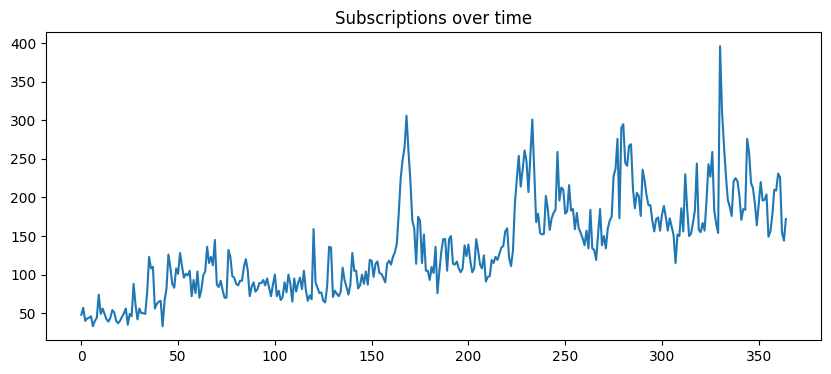

In [87]:
subs.plot(title='Subscriptions over time', figsize=(10, 4))

<Axes: title={'center': 'Top 20 Movies'}, xlabel='lead'>

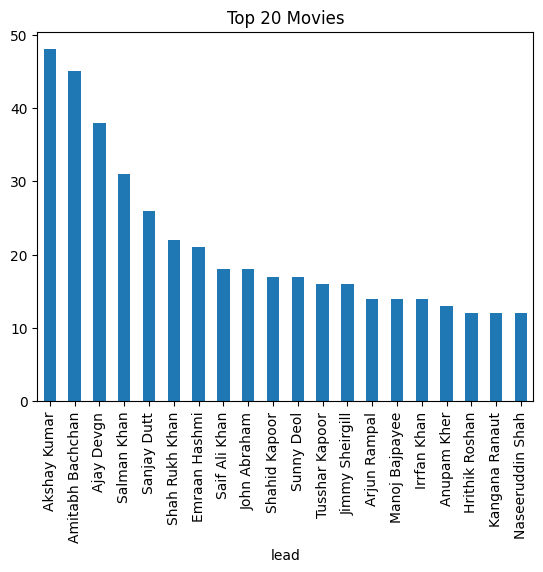

In [88]:
movies.value_counts().head(20).plot(kind='bar', title='Top 20 Movies')

<Axes: title={'center': 'Top 20 Movies'}>

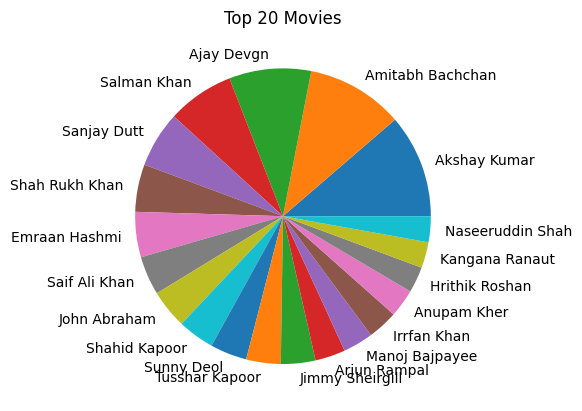

In [89]:
movies.value_counts().head(20).plot(kind='pie', title='Top 20 Movies')


## 15. Important Series Methods

### `astype()` - Change data type

In [90]:
import sys
import pandas as pd
import numpy as np

In [91]:
subs = pd.read_csv('Datasets/subs.csv').squeeze()
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [92]:
vk = pd.read_csv('Datasets/kohli_ipl.csv',index_col='match_no').squeeze()
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [93]:
movies = pd.read_csv('Datasets/bollywood.csv',index_col='movie').squeeze()
movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: str

In [94]:
sys.getsizeof(vk)

1884

In [95]:
sys.getsizeof(vk.astype('int16'))

594

**Tip:** Use smaller dtypes to save memory when range allows it.

### `between()` - Range filter

In [96]:
vk[vk.between(51, 100)].size

45

### `clip()` - Limit values to a range

In [97]:
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [98]:
subs.clip(100, 200)

0      100
1      100
2      100
3      100
4      100
      ... 
360    200
361    200
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [99]:
subs.clip(100, 200).head(10)

0    100
1    100
2    100
3    100
4    100
5    100
6    100
7    100
8    100
9    100
Name: Subscribers gained, dtype: int64

In [100]:
subs.clip??

Signature:
subs.clip(
    lower=None,
    upper=None,
    *,
    axis: 'Axis | None' = None,
    inplace: 'bool' = False,
    **kwargs,
) -> 'Self'
Source:   
    @final
    def clip(
        self,
        lower=None,
        upper=None,
        *,
        axis: Axis | None = None,
        inplace: bool = False,
        **kwargs,
    ) -> Self:
        """
        Trim values at input threshold(s).

        Assigns values outside boundary to boundary values. Thresholds
        can be singular values or array like, and in the latter case
        the clipping is performed element-wise in the specified axis.

        Parameters
        ----------
        lower : float or array-like, default None
            Minimum threshold value. All values below this
            threshold will be set to it. A missing
            threshold (e.g `NA`) will not clip the value.
        upper : float or array-like, default None
            Maximum threshold value. All values above this
            threshold

### `drop_duplicates()` - Remove duplicates

In [101]:
temp = pd.Series([1, 1, 2, 2, 3, 3, 4, 4])
temp

0    1
1    1
2    2
3    2
4    3
5    3
6    4
7    4
dtype: int64

In [102]:
temp.values

array([1, 1, 2, 2, 3, 3, 4, 4])

In [103]:
temp.drop_duplicates().values

array([1, 2, 3, 4])

In [104]:
temp.drop_duplicates(keep='last')

1    1
3    2
5    3
7    4
dtype: int64

In [105]:
temp.duplicated().sum()

np.int64(4)

In [106]:
vk.duplicated().sum()

np.int64(137)

In [107]:
vk.drop_duplicates()

match_no
1       1
2      23
3      13
4      12
6       9
       ..
173    29
175    72
176    43
178    90
198    53
Name: runs, Length: 78, dtype: int64

In [108]:
movies.drop_duplicates()

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Sssshhh...                              Tanishaa Mukerji
Rules: Pyaar Ka Superhit Formula                  Tanuja
Right Here Right Now (film)                        Ankit
Talaash: The Hunt Begins...                Rakhee Gulzar
The Pink Mirror                          Edwin Fernandes
Name: lead, Length: 566, dtype: str

### `isnull()` and `dropna()` - Handle missing values

In [109]:
temp = pd.Series([1, 2, 3, np.nan, 5, 6, np.nan, 8, np.nan, 10])
temp

0     1.0
1     2.0
2     3.0
3     NaN
4     5.0
5     6.0
6     NaN
7     8.0
8     NaN
9    10.0
dtype: float64

In [110]:
temp.size

10

In [111]:
temp.count()

np.int64(7)

In [112]:
temp.isnull().sum()

np.int64(3)

In [113]:
temp.dropna()

0     1.0
1     2.0
2     3.0
4     5.0
5     6.0
7     8.0
9    10.0
dtype: float64

### `fillna()` - Fill missing values

In [114]:
temp.fillna(temp.mean())

0     1.0
1     2.0
2     3.0
3     5.0
4     5.0
5     6.0
6     5.0
7     8.0
8     5.0
9    10.0
dtype: float64

### `isin()` - Filter by list of values

In [115]:
vk[(vk == 49) | (vk == 99)]

match_no
82    99
86    49
Name: runs, dtype: int64

In [116]:
vk[vk.isin([49, 99])]

match_no
82    99
86    49
Name: runs, dtype: int64

### `apply()` - Apply custom function

In [117]:
movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: str

In [118]:
movies.apply(lambda x: x.split()[0].upper()).head(10)

movie
Uri: The Surgical Strike                     VICKY
Battalion 609                                VICKY
The Accidental Prime Minister (film)        ANUPAM
Why Cheat India                             EMRAAN
Evening Shadows                               MONA
Soni (film)                                GEETIKA
Fraud Saiyaan                               ARSHAD
Bombairiya                                 RADHIKA
Manikarnika: The Queen of Jhansi           KANGANA
Thackeray (film)                        NAWAZUDDIN
Name: lead, dtype: str

In [119]:
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [120]:
subs.apply(lambda x: 'good day' if x > subs.mean() else 'bad day')

0       bad day
1       bad day
2       bad day
3       bad day
4       bad day
         ...   
360    good day
361    good day
362    good day
363    good day
364    good day
Name: Subscribers gained, Length: 365, dtype: str

In [121]:
subs.mean()

np.float64(135.64383561643837)

### `copy()` - Create independent copy

In [122]:
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [123]:
new = vk.head().copy()
new

match_no
1     1
2    23
3    13
4    12
5     1
Name: runs, dtype: int64

In [124]:
new[1] = 100
new

match_no
1    100
2     23
3     13
4     12
5      1
Name: runs, dtype: int64

In [125]:
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64


## Summary - Pandas Series Cheat Sheet

| Operation | Method/Attribute |
|-----------|------------------|
| Create from list | `pd.Series(list)` |
| Create from dict | `pd.Series(dict)` |
| First n rows | `head(n)` |
| Last n rows | `tail(n)` |
| Random sample | `sample(n)` |
| Sort by values | `sort_values()` |
| Sort by index | `sort_index()` |
| Frequency count | `value_counts()` |
| Basic stats | `describe()` |
| Sum/mean/median | `sum()`, `mean()`, `median()` |
| Min/max | `min()`, `max()` |
| Std/variance | `std()`, `var()` |
| Count non-null | `count()` |
| Size | `size` attribute |
| Data type | `dtype` attribute |
| Index | `index` attribute |
| Values (numpy) | `values` attribute |
| Check null | `isnull()` |
| Drop null | `dropna()` |
| Fill null | `fillna()` |
| Apply function | `apply(func)` |
| Type conversion | `astype()` |
| Range filter | `between()` |
| Clip values | `clip()` |
| Remove duplicates | `drop_duplicates()` |
| Check membership | `isin()` |
| Create copy | `copy()` |


## Key Takeaways

1. **Series = Index + Values + dtype** - it's a labeled 1D array
2. **Indexing** supports labels, integers, slicing, and boolean masks
3. **`inplace=True`** modifies the original; without it returns a new Series
4. **Boolean indexing** is the core of data filtering
5. **`apply()`** lets you run any custom function on each element
6. **Always use `.copy()`** when you need an independent Series




# Practice Problems on Pandas Series

> **Note:** In Data Science, Googling is a very important skill. If you find difficulties, search for clues and try to solve it yourself first.



### Q-1: Create an empty Series

In [126]:
pd.Series()

Series([], dtype: object)

### Q-2: Add, subtract, multiply and divide two Pandas Series

In [127]:
a = pd.Series([2, 4, 6, 8, 10])
b = pd.Series([1, 3, 5, 7, 10])

In [128]:
a

0     2
1     4
2     6
3     8
4    10
dtype: int64

In [129]:
b

0     1
1     3
2     5
3     7
4    10
dtype: int64

In [130]:
a + b

0     3
1     7
2    11
3    15
4    20
dtype: int64

In [131]:
a - b

0    1
1    1
2    1
3    1
4    0
dtype: int64

In [132]:
a * b

0      2
1     12
2     30
3     56
4    100
dtype: int64

In [133]:
a / b

0    2.000000
1    1.333333
2    1.200000
3    1.142857
4    1.000000
dtype: float64

**Explanation:** Pandas performs element-wise operations automatically using **broadcasting**. Both Series must have compatible indexes.

### Q-3: Compare elements of two Pandas Series

In [134]:
a = pd.Series([2, 4, 6, 8, 10])
b = pd.Series([1, 3, 5, 7, 10])
a

0     2
1     4
2     6
3     8
4    10
dtype: int64

In [135]:
b

0     1
1     3
2     5
3     7
4    10
dtype: int64

In [136]:
a == b

0    False
1    False
2    False
3    False
4     True
dtype: bool

In [137]:
a < b

0    False
1    False
2    False
3    False
4    False
dtype: bool

In [138]:
a > b

0     True
1     True
2     True
3     True
4    False
dtype: bool

**Explanation:** Comparison operators return a **boolean Series** of the same length, useful for filtering data.

### Q-5: Change data type of a Series

In [139]:
def change_dtype(series):
    return pd.to_numeric(series, errors='coerce')

In [140]:
series = pd.Series([1, 2, 'Python', 2.0, True, 100])
series

0         1
1         2
2    Python
3       2.0
4      True
5       100
dtype: object

In [141]:
change_dtype(series)

0      1.0
1      2.0
2      NaN
3      2.0
4      1.0
5    100.0
dtype: float64

**Explanation:**
- `pd.to_numeric()` converts values to numeric type
- `errors='coerce'` turns invalid values into `NaN` instead of raising an error
- `'Python'` becomes `NaN` because it can't be converted to a number


## IPL Batsman Data

> Download data: `batsman_runs_series.csv` https://drive.google.com/file/d/1LRhXwbEodeWXtzPhJCX0X9Lf_BECzvqb/view?usp=share_link All Batsman runs series in IPL 2008 to 2022.

In [142]:
data = pd.read_csv("Datasets/batsman_runs_series.csv")
data

,batter,batsman_run
0,A Ashish Reddy,280
1,A Badoni,161
2,A Chandila,4
3,A Chopra,53
4,A Choudhary,25
...,...,...
600,Yash Dayal,0
601,Yashpal Singh,47
602,Younis Khan,3
603,Yuvraj Singh,2754


In [143]:
data.head(5)

,batter,batsman_run
0,A Ashish Reddy,280
1,A Badoni,161
2,A Chandila,4
3,A Chopra,53
4,A Choudhary,25


### Q-6: Find top 10 most run getters

In [144]:
data.sort_values("batsman_run",ascending=False).head(10)

,batter,batsman_run
569,V Kohli,6634
462,S Dhawan,6244
130,DA Warner,5883
430,RG Sharma,5881
493,SK Raina,5536
27,AB de Villiers,5181
108,CH Gayle,4997
339,MS Dhoni,4978
452,RV Uthappa,4954
256,KD Karthik,4377


**Explanation:**
- `sort_values(ascending=False)` sorts in descending order
- `.head(10)` returns the top 10 rows

### Q-7: Number of players having runs above 3000

In [145]:
data[data["batsman_run"]>3000].shape[0]

20

**Explanation:**
- `batsmen > 3000` creates a boolean Series
- `batsmen[boolean]` filters to keep only True values
- `.shape[0]` counts the number of rows

### Q-8: Number of players having runs above mean value

In [146]:
data[data["batsman_run"] > data["batsman_run"].mean()].shape[0]

128


##  Items Data (Chipotle)

> Download data: `items.csv` https://drive.google.com/file/d/1QZuZ5bypUInfVvarHACLAi8tXXHvb8xd/view?usp=share_link

file name - items.csv


### Q-9: Process items data

In [147]:
# i. Read with item_name as index
items = pd.read_csv("Datasets/items.csv", index_col = ['item_name']).squeeze("columns")
items

item_name
Chips and Fresh Tomato Salsa              $2.39 
Izze                                      $3.39 
Nantucket Nectar                          $3.39 
Chips and Tomatillo-Green Chili Salsa     $2.39 
Chicken Bowl                             $16.98 
                                          ...   
Steak Burrito                            $11.75 
Steak Burrito                            $11.75 
Chicken Salad Bowl                       $11.25 
Chicken Salad Bowl                        $8.75 
Chicken Salad Bowl                        $8.75 
Name: item_price, Length: 4622, dtype: str

In [148]:
items.isna().sum()

np.int64(50)

In [149]:
# iii. Convert price from $ to rupees
def rupees(x):
    try:
        y = x[1:] 
    except:
        y = x
    return float(y) * 82.49

items.apply(rupees)

item_name
Chips and Fresh Tomato Salsa              197.1511
Izze                                      279.6411
Nantucket Nectar                          279.6411
Chips and Tomatillo-Green Chili Salsa     197.1511
Chicken Bowl                             1400.6802
                                           ...    
Steak Burrito                             969.2575
Steak Burrito                             969.2575
Chicken Salad Bowl                        928.0125
Chicken Salad Bowl                        721.7875
Chicken Salad Bowl                        721.7875
Name: item_price, Length: 4622, dtype: float64

In [150]:
# iv. Fill NaN with mean
items = items.apply(rupees)
items.fillna(items.mean())

item_name
Chips and Fresh Tomato Salsa              197.1511
Izze                                      279.6411
Nantucket Nectar                          279.6411
Chips and Tomatillo-Green Chili Salsa     197.1511
Chicken Bowl                             1400.6802
                                           ...    
Steak Burrito                             969.2575
Steak Burrito                             969.2575
Chicken Salad Bowl                        928.0125
Chicken Salad Bowl                        721.7875
Chicken Salad Bowl                        721.7875
Name: item_price, Length: 4622, dtype: float64

**Key functions used:**
- `pd.read_csv(..., index_col='item_name')` - Set index column
- `.squeeze('columns')` - Convert single-column DataFrame to Series
- `.apply(func)` - Apply function to each element
- `.fillna(value)` - Replace NaN with value

### Q-10: Statistical analysis on items

In [151]:
# i. Mean price
items = items.fillna(items.mean())
items.mean()

np.float64(615.6254681102363)

In [152]:
# ii. 30th and 6th percentile
items.quantile(q=0.3)
items.quantile(q=0.06)

np.float64(103.1125)

<Axes: title={'center': 'Price Distribution'}, ylabel='Frequency'>

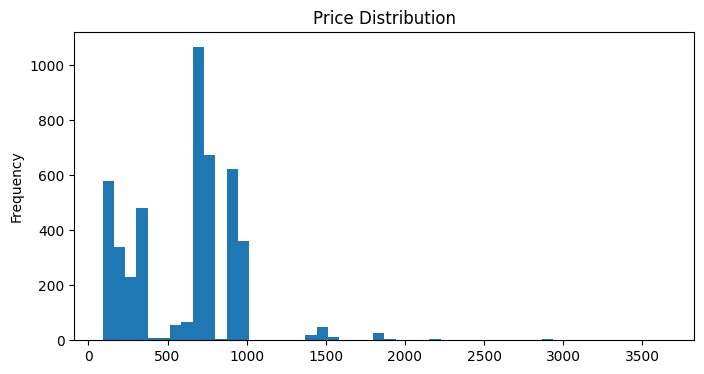

In [153]:
# iii. Histogram
items.plot.hist(bins=50, title='Price Distribution', figsize=(8, 4))

In [154]:
# iv. Items priced between 1000 and 2000
items[(items > 1000) & (items < 2000)]

item_name
Chicken Bowl           1400.6802
Chicken Salad Bowl     1856.0250
Steak Burrito          1483.1702
Chicken Burrito        1443.5750
Chicken Bowl           1443.5750
                         ...    
Chicken Bowl           1856.0250
Steak Bowl             1938.5150
Chicken Bowl           1443.5750
Chips and Guacamole    1468.3220
Chicken Salad Bowl     1443.5750
Name: item_price, Length: 116, dtype: float64


## Practice Problems Summary

| Problem | Concept Used |
|---------|-------------|
| Q-1 | Empty Series creation |
| Q-2 | Arithmetic operators on Series |
| Q-3 | Comparison operators |
| Q-5 | `pd.to_numeric()` with errors='coerce' |
| Q-6 | `sort_values()` |
| Q-7 | Boolean indexing + `.shape` |
| Q-8 | Mean calculation + filtering |
| Q-9 | `read_csv()`, `apply()`, `fillna()` |
| Q-10 | `quantile()`, `plot.hist()` |



## Additional Practice Challenges

Try these on your own:

1. Create a Series of 100 random numbers and find how many are above the median
2. Create a Series from a dictionary of 5 fruits and their prices, then apply 10% discount using `apply()`
3. Find the most common value in a Series using `value_counts().head(1)`
4. Create two Series with different indexes and add them - observe what happens with missing values
5. Load any CSV file and find the top 5 most frequent values in a column


# Pandas DataFrame

## The Most Important Data Structure in Data Science

A **DataFrame** is a 2-D labeled data structure with columns of potentially different types. Think of it as a spreadsheet, SQL table, or a dictionary of Series objects.

```
DataFrame = Index + Columns + Data (2D array)

            iq  marks  package
name        
nitish    100     80       10
ankit      90     70        7
rupesh    120    100       14
rishabh    80     50        2
```


## Creating DataFrames

### 1. From Lists

In [155]:
import pandas as pd

In [156]:
import numpy as np

In [157]:
student_data = [
    [100, 80, 10],
    [90, 70, 7],
    [120, 100, 14],
    [80, 50, 2]
]

pd.DataFrame(student_data, columns=['iq', 'marks', 'package'])

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,50,2


**Explanation:**
- Each inner list becomes a row
- `columns` parameter names each column
- Default index is 0, 1, 2, 3

### 2. From Dictionary

In [158]:
student_dict = {
    'name': ['nitish', 'ankit', 'rupesh', 'rishabh', 'amit', 'ankita'],
    'iq': [100, 90, 120, 80, 0, 0],
    'marks': [80, 70, 100, 50, 0, 0],
    'package': [10, 7, 14, 2, 0, 0]
}

students = pd.DataFrame(student_dict)
students

,name,iq,marks,package
0,nitish,100,80,10
1,ankit,90,70,7
2,rupesh,120,100,14
3,rishabh,80,50,2
4,amit,0,0,0
5,ankita,0,0,0


In [159]:
students.set_index('name', inplace=True)
students

,iq,marks,package
name,,,
nitish,100,80,10
ankit,90,70,7
rupesh,120,100,14
rishabh,80,50,2
amit,0,0,0
ankita,0,0,0


**Key Points:**
- Dictionary keys become column names
- Values (lists) become column data
- `set_index('name')` makes 'name' the index instead of default 0,1,2...

### 3. From CSV Files

In [160]:
movies = pd.read_csv('Datasets/movies.csv')
movies

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)


In [161]:
ipl = pd.read_csv('Datasets/IPL_Matches_2008_2022.csv')
ipl

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri



## DataFrame Attributes and Methods

### `shape` - Dimensions (rows, cols)

In [162]:
movies.shape

(1629, 18)

In [163]:
ipl.shape

(950, 20)

### `dtypes` - Data types of each column

In [164]:
movies.dtypes

title_x                 str
imdb_id                 str
poster_path             str
wiki_link               str
title_y                 str
original_title          str
is_adult              int64
year_of_release       int64
runtime                 str
genres                  str
imdb_rating         float64
imdb_votes            int64
story                   str
summary                 str
tagline                 str
actors                  str
wins_nominations        str
release_date            str
dtype: object

In [165]:
ipl.dtypes

ID                   int64
City                   str
Date                   str
Season                 str
MatchNumber            str
Team1                  str
Team2                  str
Venue                  str
TossWinner             str
TossDecision           str
SuperOver              str
WinningTeam            str
WonBy                  str
Margin             float64
method                 str
Player_of_Match        str
Team1Players           str
Team2Players           str
Umpire1                str
Umpire2                str
dtype: object

### `index` - Row labels

In [166]:
movies.index

RangeIndex(start=0, stop=1629, step=1)

In [167]:
ipl.index

RangeIndex(start=0, stop=950, step=1)

### `columns` - Column labels

In [168]:
movies.columns

Index(['title_x', 'imdb_id', 'poster_path', 'wiki_link', 'title_y',
       'original_title', 'is_adult', 'year_of_release', 'runtime', 'genres',
       'imdb_rating', 'imdb_votes', 'story', 'summary', 'tagline', 'actors',
       'wins_nominations', 'release_date'],
      dtype='str')

In [169]:
ipl.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='str')

### `values` - Get underlying NumPy array

In [170]:
students

,iq,marks,package
name,,,
nitish,100,80,10
ankit,90,70,7
rupesh,120,100,14
rishabh,80,50,2
amit,0,0,0
ankita,0,0,0


In [171]:
students.values

array([[100,  80,  10],
       [ 90,  70,   7],
       [120, 100,  14],
       [ 80,  50,   2],
       [  0,   0,   0],
       [  0,   0,   0]])

In [172]:
ipl.values

array([[1312200, 'Ahmedabad', '2022-05-29', ...,
        "['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pandya', 'DA Miller', 'R Tewatia', 'Rashid Khan', 'R Sai Kishore', 'LH Ferguson', 'Yash Dayal', 'Mohammed Shami']",
        'CB Gaffaney', 'Nitin Menon'],
       [1312199, 'Ahmedabad', '2022-05-27', ...,
        "['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D Padikkal', 'SO Hetmyer', 'R Parag', 'R Ashwin', 'TA Boult', 'YS Chahal', 'M Prasidh Krishna', 'OC McCoy']",
        'CB Gaffaney', 'Nitin Menon'],
       [1312198, 'Kolkata', '2022-05-25', ...,
        "['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda', 'MP Stoinis', 'E Lewis', 'KH Pandya', 'PVD Chameera', 'Mohsin Khan', 'Avesh Khan', 'Ravi Bishnoi']",
        'J Madanagopal', 'MA Gough'],
       ...,
       [335984, 'Delhi', '2008-04-19', ...,
        "['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif', 'DS Lehmann', 'RA Jadeja', 'M Rawat', 'D Salunkhe', 'SK Warne', 'SK Trivedi', 'MM Patel']",
        'Aleem Dar', 'GA Pratapkumar'],
    

### `head()` and `tail()`

In [173]:
movies.head(2)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)


In [174]:
ipl.tail(2)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri
949,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,N,Kolkata Knight Riders,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen


### `sample()` - Random rows

In [175]:
ipl.sample(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
621,598004,Hyderabad,2013-04-07,2013,7,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bangalore,bat,Y,Sunrisers Hyderabad,SuperOver,NaN,NaN,GH Vihari,"['PA Reddy', 'PA Patel', 'CL White', 'GH Vihar...","['CH Gayle', 'TM Dilshan', 'V Kohli', 'KK Nair...",AK Chaudhary,S Ravi
34,1304086,Mumbai,2022-04-27,2022,40,Sunrisers Hyderabad,Gujarat Titans,"Wankhede Stadium, Mumbai",Gujarat Titans,field,N,Gujarat Titans,Wickets,5.0,NaN,Umran Malik,"['Abhishek Sharma', 'KS Williamson', 'RA Tripa...","['WP Saha', 'Shubman Gill', 'HH Pandya', 'DA M...",CB Gaffaney,Navdeep Singh
370,1082593,Rajkot,2017-04-07,2017,3,Gujarat Lions,Kolkata Knight Riders,Saurashtra Cricket Association Stadium,Kolkata Knight Riders,field,N,Kolkata Knight Riders,Wickets,10.0,NaN,CA Lynn,"['JJ Roy', 'BB McCullum', 'SK Raina', 'AJ Finc...","['G Gambhir', 'CA Lynn', 'RV Uthappa', 'MK Pan...",Nitin Menon,CK Nandan


### `info()` - Column-wise summary

In [176]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title_x           1629 non-null   str    
 1   imdb_id           1629 non-null   str    
 2   poster_path       1526 non-null   str    
 3   wiki_link         1629 non-null   str    
 4   title_y           1629 non-null   str    
 5   original_title    1629 non-null   str    
 6   is_adult          1629 non-null   int64  
 7   year_of_release   1629 non-null   int64  
 8   runtime           1629 non-null   str    
 9   genres            1629 non-null   str    
 10  imdb_rating       1629 non-null   float64
 11  imdb_votes        1629 non-null   int64  
 12  story             1609 non-null   str    
 13  summary           1629 non-null   str    
 14  tagline           557 non-null    str    
 15  actors            1624 non-null   str    
 16  wins_nominations  707 non-null    str    
 17  releas

In [177]:
ipl.info()

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    str    
 2   Date             950 non-null    str    
 3   Season           950 non-null    str    
 4   MatchNumber      950 non-null    str    
 5   Team1            950 non-null    str    
 6   Team2            950 non-null    str    
 7   Venue            950 non-null    str    
 8   TossWinner       950 non-null    str    
 9   TossDecision     950 non-null    str    
 10  SuperOver        946 non-null    str    
 11  WinningTeam      946 non-null    str    
 12  WonBy            950 non-null    str    
 13  Margin           932 non-null    float64
 14  method           19 non-null     str    
 15  Player_of_Match  946 non-null    str    
 16  Team1Players     950 non-null    str    
 17  Team2Players     950 non-nu

**`info()` tells you:** column names, non-null counts, dtypes, memory usage

### `describe()` - Statistical summary

In [178]:
movies.describe()

,is_adult,year_of_release,imdb_rating,imdb_votes
count,1629.0,1629.000000,1629.000000,1629.000000
mean,0.0,2010.263966,5.557459,5384.263352
std,0.0,5.381542,1.567609,14552.103231
min,0.0,2001.000000,0.000000,0.000000
25%,0.0,2005.000000,4.400000,233.000000
50%,0.0,2011.000000,5.600000,1000.000000
75%,0.0,2015.000000,6.800000,4287.000000
max,0.0,2019.000000,9.400000,310481.000000


In [179]:
ipl.describe()

,ID,Margin
count,9.500000e+02,932.000000
mean,8.304852e+05,17.056867
std,3.375678e+05,21.633109
min,3.359820e+05,1.000000
25%,5.012612e+05,6.000000
50%,8.297380e+05,8.000000
75%,1.175372e+06,19.000000
max,1.312200e+06,146.000000


### `isnull().sum()` - Count missing values

In [180]:
movies.isnull().sum()

title_x                0
imdb_id                0
poster_path          103
wiki_link              0
title_y                0
original_title         0
is_adult               0
year_of_release        0
runtime                0
genres                 0
imdb_rating            0
imdb_votes             0
story                 20
summary                0
tagline             1072
actors                 5
wins_nominations     922
release_date         107
dtype: int64

### `duplicated().sum()` - Count duplicate rows

In [181]:
movies.duplicated().sum()

np.int64(0)

### `rename()` - Rename columns

In [182]:
students

,iq,marks,package
name,,,
nitish,100,80,10
ankit,90,70,7
rupesh,120,100,14
rishabh,80,50,2
amit,0,0,0
ankita,0,0,0


In [183]:
students.rename(columns={'marks': 'percent', 'package': 'lpa'}, inplace=True)

In [184]:
students

,iq,percent,lpa
name,,,
nitish,100,80,10
ankit,90,70,7
rupesh,120,100,14
rishabh,80,50,2
amit,0,0,0
ankita,0,0,0



## Math Methods

In [185]:
students.sum(axis=0)

iq         390
percent    300
lpa         33
dtype: int64

In [186]:
students.sum(axis=1)

name
nitish     190
ankit      167
rupesh     234
rishabh    132
amit         0
ankita       0
dtype: int64

In [187]:
students.mean(axis=1)

name
nitish     63.333333
ankit      55.666667
rupesh     78.000000
rishabh    44.000000
amit        0.000000
ankita      0.000000
dtype: float64

In [188]:
students.var()

iq         2710.0
percent    1760.0
lpa          33.5
dtype: float64

**`axis` parameter:**
- `axis=0` or `axis='index'` = operate along rows (result is per column)
- `axis=1` or `axis='columns'` = operate along columns (result is per row)


## Selecting Columns from a DataFrame

### Single column

In [189]:
movies['title_x']

0                   Uri: The Surgical Strike
1                              Battalion 609
2       The Accidental Prime Minister (film)
3                            Why Cheat India
4                            Evening Shadows
                        ...                 
1624                   Tera Mera Saath Rahen
1625                    Yeh Zindagi Ka Safar
1626                         Sabse Bada Sukh
1627                                   Daaka
1628                                Humsafar
Name: title_x, Length: 1629, dtype: str

In [190]:
ipl['Venue']

0                Narendra Modi Stadium, Ahmedabad
1                Narendra Modi Stadium, Ahmedabad
2                           Eden Gardens, Kolkata
3                           Eden Gardens, Kolkata
4                        Wankhede Stadium, Mumbai
                          ...                    
945                                  Eden Gardens
946                              Wankhede Stadium
947                              Feroz Shah Kotla
948    Punjab Cricket Association Stadium, Mohali
949                         M Chinnaswamy Stadium
Name: Venue, Length: 950, dtype: str

In [191]:
ipl['Venue'].head() if 'Venue' in ipl.columns else 'Column not in sample data'

0    Narendra Modi Stadium, Ahmedabad
1    Narendra Modi Stadium, Ahmedabad
2               Eden Gardens, Kolkata
3               Eden Gardens, Kolkata
4            Wankhede Stadium, Mumbai
Name: Venue, dtype: str

### Multiple columns (pass a list)

In [192]:
movies[['year_of_release', 'actors', 'title_x']]

,year_of_release,actors,title_x
0,2019,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,Uri: The Surgical Strike
1,2019,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,Battalion 609
2,2019,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,The Accidental Prime Minister (film)
3,2019,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,Why Cheat India
4,2018,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,Evening Shadows
...,...,...,...
1624,2001,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,Tera Mera Saath Rahen
1625,2001,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,Yeh Zindagi Ka Safar
1626,2018,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,Sabse Bada Sukh
1627,2019,Gippy Grewal|Zareen Khan|,Daaka


In [193]:
ipl[['Team1', 'Team2', 'WinningTeam']]

,Team1,Team2,WinningTeam
0,Rajasthan Royals,Gujarat Titans,Gujarat Titans
1,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals
2,Royal Challengers Bangalore,Lucknow Super Giants,Royal Challengers Bangalore
3,Rajasthan Royals,Gujarat Titans,Gujarat Titans
4,Sunrisers Hyderabad,Punjab Kings,Punjab Kings
...,...,...,...
945,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders
946,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore
947,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils
948,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings


**Key:** Use double brackets `[[ ]]` for multiple columns — the outer brackets are for indexing, the inner list specifies which columns.


## Selecting Rows from a DataFrame

Two methods:
- **`iloc`** - searches using **index positions** (integer-based)
- **`loc`** - searches using **index labels** (label-based)

### Using `iloc` - Position-based

In [194]:
# Single row
movies.iloc[0]

title_x                                      Uri: The Surgical Strike
imdb_id                                                     tt8291224
poster_path         https://upload.wikimedia.org/wikipedia/en/thum...
wiki_link           https://en.wikipedia.org/wiki/Uri:_The_Surgica...
title_y                                      Uri: The Surgical Strike
original_title                               Uri: The Surgical Strike
is_adult                                                            0
year_of_release                                                  2019
runtime                                                           138
genres                                               Action|Drama|War
imdb_rating                                                       8.4
imdb_votes                                                      35112
story               Divided over five chapters  the film chronicle...
summary             Indian army special forces execute a covert op...
tagline             

In [195]:
# Multiple rows (slicing)
movies.iloc[:3]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)


In [196]:
# Fancy indexing
movies.iloc[[0, 2, 4]]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)


### Using `loc` - Label-based

In [197]:
students

,iq,percent,lpa
name,,,
nitish,100,80,10
ankit,90,70,7
rupesh,120,100,14
rishabh,80,50,2
amit,0,0,0
ankita,0,0,0


In [198]:
# Single row by label
students.loc['nitish']

iq         100
percent     80
lpa         10
Name: nitish, dtype: int64

In [199]:
# Slicing with labels (inclusive on both ends!)
students.loc['nitish':'rishabh']

,iq,percent,lpa
name,,,
nitish,100,80,10
ankit,90,70,7
rupesh,120,100,14
rishabh,80,50,2


In [200]:
# Fancy indexing with labels
students.loc[['nitish', 'ankita']]

,iq,percent,lpa
name,,,
nitish,100,80,10
ankita,0,0,0


**Difference between iloc and loc:**
- `iloc[0:3]` → rows 0, 1, 2 (end exclusive)
- `loc['a':'c']` → rows 'a', 'b', 'c' (end INCLUSIVE!)


## Selecting both Rows and Cols

In [201]:
# iloc: [row_start:row_end, col_start:col_end]
movies.iloc[0:3, 0:3]

,title_x,imdb_id,poster_path
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...
1,Battalion 609,tt9472208,NaN
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...


In [202]:
# loc: [row_label:row_label, col_label:col_label]
movies.loc[0:2, 'title_x':'genres']

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama



## Filtering a DataFrame

This is one of the most important skills in Pandas.

### Find all IPL Final winners

In [203]:
ipl.head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


In [204]:
ipl.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='str')

In [205]:
mask = ipl['MatchNumber'] == 'Final'
new_df = ipl[mask]
new_df[['Season', 'WinningTeam']]

,Season,WinningTeam
0,2022,Gujarat Titans
74,2021,Chennai Super Kings
134,2020/21,Mumbai Indians
194,2019,Mumbai Indians
254,2018,Chennai Super Kings
314,2017,Mumbai Indians
373,2016,Sunrisers Hyderabad
433,2015,Mumbai Indians
492,2014,Kolkata Knight Riders
552,2013,Mumbai Indians


In [206]:
# Chained version
ipl[ipl['MatchNumber'] == 'Final'][['Season', 'WinningTeam']]

,Season,WinningTeam
0,2022,Gujarat Titans
74,2021,Chennai Super Kings
134,2020/21,Mumbai Indians
194,2019,Mumbai Indians
254,2018,Chennai Super Kings
314,2017,Mumbai Indians
373,2016,Sunrisers Hyderabad
433,2015,Mumbai Indians
492,2014,Kolkata Knight Riders
552,2013,Mumbai Indians


### Count super over finishes

In [207]:
ipl[ipl['SuperOver'] == 'Y'].shape[0]

14

### CSK wins in Kolkata

In [208]:
ipl[(ipl['City'] == 'Kolkata') & (ipl['WinningTeam'] == 'Chennai Super Kings')].shape[0]

5

### Toss winner is match winner percentage

In [209]:
toss_match = ipl[ipl['TossWinner'] == ipl['WinningTeam']].shape[0]
total = ipl.shape[0]

In [210]:
(toss_match/total)*100

51.473684210526315

### Movies with high rating and votes

In [211]:
movies[(movies['imdb_rating'] > 8.0) & (movies['imdb_votes'] > 10000)].shape[0]

43

In [212]:
movies[(movies['imdb_rating'] > 8.0) & (movies['imdb_votes'] > 10000)].head(5)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
11,Gully Boy,tt2395469,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Gully_Boy,Gully Boy,Gully Boy,0,2019,153,Drama|Music,8.2,22440,"Gully Boy is a film about a 22-year-old boy ""M...",A coming-of-age story based on the lives of st...,Apna Time Aayega!,Ranveer Singh|Alia Bhatt|Siddhant Chaturvedi|V...,6 wins & 3 nominations,14 February 2019 (USA)
37,Article 15 (film),tt10324144,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Article_15_(film),Article 15,Article 15,0,2019,130,Crime|Drama,8.3,13417,In the rural heartlands of India an upright p...,In the rural heartlands of India an upright p...,Farq Bahut Kar Liya| Ab Farq Laayenge.,Ayushmann Khurrana|Nassar|Manoj Pahwa|Kumud Mi...,1 win,28 June 2019 (USA)
40,Super 30 (film),tt7485048,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Super_30_(film),Super 30,Super 30,0,2019,154,Biography|Drama,8.2,13972,Anand Kumar a Mathematics genius from a modes...,Based on life of Patna-based mathematician Ana...,Inspired by the Life of Anand Kumar & His Stud...,Hrithik Roshan|Mrunal Thakur|Nandish Singh|Vir...,NaN,12 July 2019 (USA)
143,Tumbbad,tt8239946,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Tumbbad,Tumbbad,Tumbbad,0,2018,104,Drama|Fantasy|Horror,8.2,16535,Set in Tumbbad in the 1920s the story revolve...,A mythological story about a goddess who creat...,NaN,Sohum Shah|Jyoti Malshe|Anita Date|Ronjini Cha...,9 wins & 12 nominations,12 October 2018 (India)


### Action movies with rating > 7.5

In [213]:
mask1 = movies['genres'].str.contains('Action')
mask2 = movies['imdb_rating'] > 7.5
movies[mask1 & mask2]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
41,Family of Thakurganj,tt8897986,https://upload.wikimedia.org/wikipedia/en/9/99...,https://en.wikipedia.org/wiki/Family_of_Thakur...,Family of Thakurganj,Family of Thakurganj,0,2019,127,Action|Drama,9.4,895,The film is based on small town of North India...,The film is based on small town of North India...,NaN,Jimmy Sheirgill|Mahie Gill|Nandish Singh|Prana...,NaN,19 July 2019 (India)
84,Mukkabaaz,tt7180544,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Mukkabaaz,The Brawler,Mukkabaaz,0,2017,154,Action|Drama|Sport,8.1,5434,A boxer (Shravan) belonging to upper cast tra...,A boxer struggles to make his mark in the boxi...,NaN,Viineet Kumar|Jimmy Sheirgill|Zoya Hussain|Rav...,3 wins & 6 nominations,12 January 2018 (USA)
106,Raazi,tt7098658,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Raazi,Raazi,Raazi,0,2018,138,Action|Drama|Thriller,7.8,20289,Hidayat Khan is the son of an Indian freedom f...,A Kashmiri woman agrees to marry a Pakistani a...,An incredible true story,Alia Bhatt|Vicky Kaushal|Rajit Kapoor|Shishir ...,21 wins & 26 nominations,11 May 2018 (USA)
110,Parmanu: The Story of Pokhran,tt6826438,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Parmanu:_The_Sto...,Parmanu: The Story of Pokhran,Parmanu: The Story of Pokhran,0,2018,129,Action|Drama|History,7.7,18292,Captain Ashwat Raina's efforts to turn India i...,Ashwat Raina and his teammates arrive in Pokhr...,1998| India: one secret operation| six Indians...,John Abraham|Boman Irani|Diana Penty|Anuja Sat...,NaN,25 May 2018 (USA)
112,Bhavesh Joshi Superhero,tt6129302,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Bhavesh_Joshi_Su...,Bhavesh Joshi Superhero,Bhavesh Joshi Superhero,0,2018,154,Action|Drama,7.6,4928,Bhavesh Joshi Superhero is an action film abou...,The origin story of Bhavesh Joshi an Indian s...,This year| justice will have a new name.,Harshvardhan Kapoor|Priyanshu Painyuli|Ashish ...,2 nominations,1 June 2018 (USA)
169,The Ghazi Attack,tt6299040,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Ghazi_Attack...,The Ghazi Attack,The Ghazi Attack,0,2017,116,Action|Thriller|War,7.6,10332,In 1971 amid rising tensions between India an...,A Pakistani submarine Ghazi plans to secretly...,The war you did not know about,Rana Daggubati|Kay Kay Menon|Atul Kulkarni|Om ...,1 win & 7 nominations,17 February 2017 (USA)
219,Raag Desh (film),tt6080746,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Raagdesh,Raag Desh,Raag Desh,0,2017,135,Action|Drama|History,8.3,341,A period film based on the historic 1945 India...,A period film based on the historic 1945 India...,NaN,Kunal Kapoor|Amit Sadh|Mohit Marwah|Kenneth De...,NaN,28 July 2017 (India)
258,Irudhi Suttru,tt5310090,https://upload.wikimedia.org/wikipedia/en/f/fe...,https://en.wikipedia.org/wiki/Saala_Khadoos,Saala Khadoos,Saala Khadoos,0,2016,109,Action|Drama|Sport,7.6,10507,An under-fire boxing coach Prabhu is transfer...,The story of a former boxer who quits boxing f...,NaN,Madhavan|Ritika Singh|Mumtaz Sorcar|Nassar|Rad...,9 wins & 2 nominations,29 January 2016 (USA)
280,Laal Rang,tt5600714,NaN,https://en.wikipedia.org/wiki/Laal_Rang,Laal Rang,Laal Rang,0,2016,147,Action|Crime|Drama,8.0,3741,The friendship of two men is tested when thing...,The frie

**Filtering syntax:**
```python
df[condition]  # Single condition
df[(cond1) & (cond2)]  # Multiple conditions (use & and |)
df[condition][['col1', 'col2']]  # Filter + select columns
```

> **Always use parentheses** around each condition when combining with `&` or `|`

In [214]:
ipl['Team1'].unique()

<ArrowStringArray>
[           'Rajasthan Royals', 'Royal Challengers Bangalore',
         'Sunrisers Hyderabad',              'Delhi Capitals',
         'Chennai Super Kings',              'Gujarat Titans',
        'Lucknow Super Giants',       'Kolkata Knight Riders',
                'Punjab Kings',              'Mumbai Indians',
             'Kings XI Punjab',            'Delhi Daredevils',
      'Rising Pune Supergiant',               'Gujarat Lions',
     'Rising Pune Supergiants',               'Pune Warriors',
             'Deccan Chargers',        'Kochi Tuskers Kerala']
Length: 18, dtype: str

In [215]:
def head_to_head(df, teamA, teamB):
    """
    Return the track record of two teams against each other.
    df must have columns: 'Team1', 'Team2', 'WinningTeam'
    """
    # Filter matches where teamA and teamB played each other
    mask = ((df['Team1'] == teamA) & (df['Team2'] == teamB)) | ((df['Team1'] == teamB) & (df['Team2'] == teamA))
    matches = df[mask]
    
    # Count wins
    wins_A = (matches['WinningTeam'] == teamA).sum()
    wins_B = (matches['WinningTeam'] == teamB).sum()
    
    # Count draws/ties if present
    draws = (matches['WinningTeam'] == "Draw").sum() if "Draw" in matches['WinningTeam'].values else 0
    
    return {
        teamA: wins_A,teamB: wins_B,"draws": draws,"total_matches": len(matches)
    }

In [216]:
head_to_head(ipl,"Royal Challengers Bangalore","Punjab Kings")

{'Royal Challengers Bangalore': np.int64(1),
 'Punjab Kings': np.int64(3),
 'draws': 0,
 'total_matches': 4}


## Adding New Columns

### Completely new column

In [217]:
movies['Country'] = 'India'
movies.head()

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date,Country
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA),India
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India),India
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA),India
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA),India
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India),India


### From existing columns

In [218]:
movies.dropna(inplace=True)

In [219]:
movies['lead_actor'] = movies['actors'].str.split('|').apply(lambda x: x[0])
movies.head()

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date,Country,lead_actor
11,Gully Boy,tt2395469,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Gully_Boy,Gully Boy,Gully Boy,0,2019,153,Drama|Music,8.2,22440,"Gully Boy is a film about a 22-year-old boy ""M...",A coming-of-age story based on the lives of st...,Apna Time Aayega!,Ranveer Singh|Alia Bhatt|Siddhant Chaturvedi|V...,6 wins & 3 nominations,14 February 2019 (USA),India,Ranveer Singh
34,Yeh Hai India,tt5525846,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Hai_India,Yeh Hai India,Yeh Hai India,0,2017,128,Action|Adventure|Drama,5.7,169,Yeh Hai India follows the story of a 25 years...,Yeh Hai India follows the story of a 25 years...,A Film for Every Indian,Gavie Chahal|Mohan Agashe|Mohan Joshi|Lom Harsh|,2 wins & 1 nomination,24 May 2019 (India),India,Gavie Chahal
37,Article 15 (film),tt10324144,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Article_15_(film),Article 15,Article 15,0,2019,130,Crime|Drama,8.3,13417,In the rural heartlands of India an upright p...,In the rural heartlands of India an upright p...,Farq Bahut Kar Liya| Ab Farq Laayenge.,Ayushmann Khurrana|Nassar|Manoj Pahwa|Kumud Mi...,1 win,28 June 2019 (USA),India,Ayushmann Khurrana
87,Aiyaary,tt6774212,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Aiyaary,Aiyaary,Aiyaary,0,2018,157,Action|Thriller,5.2,3538,General Gurinder Singh comes with a proposal t...,After finding out about an illegal arms deal ...,The Ultimate Trickery,Sidharth Malhotra|Manoj Bajpayee|Rakul Preet S...,1 nomination,16 February 2018 (USA),India,Sidharth Malhotra
96,Raid (2018 film),tt7363076,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Raid_(2018_film),Raid,Raid,0,2018,122,Action|Crime|Drama,7.4,13159,Set in the 80s in Uttar Pradesh India Raid i...,A fearless income tax officer raids the mansio...,Heroes don't always come in uniform,Ajay Devgn|Saurabh Shukla|Ileana D'Cruz|Amit S...,2 wins & 3 nominations,16 March 2018 (India),India,Ajay Devgn


**Key methods used:**
- `.str.split('|')` - Split string column by delimiter
- `.apply(lambda x: x[0])` - Apply function to get first element


# Important DataFrame Functions

A comprehensive reference of the most-used Pandas functions.

## `value_counts()`

Counts unique values in a Series or DataFrame.

In [220]:
import pandas as pd
import numpy as np

In [221]:
a = pd.Series([1, 1, 1, 2, 2, 3])
a.value_counts()

1    3
2    2
3    1
Name: count, dtype: int64

In [222]:
marks = pd.DataFrame([
    [100, 80, 10],
    [90, 70, 7],
    [120, 100, 14],
    [80, 70, 14],
    [80, 70, 14]
], columns=['iq', 'marks', 'package'])

marks.value_counts()

iq   marks  package
80   70     14         2
100  80     10         1
90   70     7          1
120  100    14         1
Name: count, dtype: int64

**DataFrame `value_counts()`:** Counts how many times each unique **row combination** appears.

In [223]:
# astype
ipl.info()

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    str    
 2   Date             950 non-null    str    
 3   Season           950 non-null    str    
 4   MatchNumber      950 non-null    str    
 5   Team1            950 non-null    str    
 6   Team2            950 non-null    str    
 7   Venue            950 non-null    str    
 8   TossWinner       950 non-null    str    
 9   TossDecision     950 non-null    str    
 10  SuperOver        946 non-null    str    
 11  WinningTeam      946 non-null    str    
 12  WonBy            950 non-null    str    
 13  Margin           932 non-null    float64
 14  method           19 non-null     str    
 15  Player_of_Match  946 non-null    str    
 16  Team1Players     950 non-null    str    
 17  Team2Players     950 non-nu

In [224]:
ipl['ID'] =ipl['ID'].astype('int32')

In [225]:
ipl.info()

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int32  
 1   City             899 non-null    str    
 2   Date             950 non-null    str    
 3   Season           950 non-null    str    
 4   MatchNumber      950 non-null    str    
 5   Team1            950 non-null    str    
 6   Team2            950 non-null    str    
 7   Venue            950 non-null    str    
 8   TossWinner       950 non-null    str    
 9   TossDecision     950 non-null    str    
 10  SuperOver        946 non-null    str    
 11  WinningTeam      946 non-null    str    
 12  WonBy            950 non-null    str    
 13  Margin           932 non-null    float64
 14  method           19 non-null     str    
 15  Player_of_Match  946 non-null    str    
 16  Team1Players     950 non-null    str    
 17  Team2Players     950 non-nu

In [226]:
ipl['Season'] =ipl['Season'].astype('category')
ipl['Team1'] =ipl['Team1'].astype('category')
ipl['Team2'] =ipl['Team2'].astype('category')
ipl.info()

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   ID               950 non-null    int32   
 1   City             899 non-null    str     
 2   Date             950 non-null    str     
 3   Season           950 non-null    category
 4   MatchNumber      950 non-null    str     
 5   Team1            950 non-null    category
 6   Team2            950 non-null    category
 7   Venue            950 non-null    str     
 8   TossWinner       950 non-null    str     
 9   TossDecision     950 non-null    str     
 10  SuperOver        946 non-null    str     
 11  WinningTeam      946 non-null    str     
 12  WonBy            950 non-null    str     
 13  Margin           932 non-null    float64 
 14  method           19 non-null     str     
 15  Player_of_Match  946 non-null    str     
 16  Team1Players     950 non-null    str     
 17  Team2Pla

In [227]:
# Find which player won most POTM in finals/qualifiers
ipl = pd.read_csv('Datasets/IPL_Matches_2008_2022.csv')
ipl[~ipl['MatchNumber'].str.isdigit()]['Player_of_Match'].value_counts()

Player_of_Match
F du Plessis         3
KA Pollard           3
SK Raina             3
JJ Bumrah            2
SR Watson            2
AB de Villiers       2
MK Pandey            2
M Vijay              2
YK Pathan            2
A Kumble             2
HH Pandya            1
JC Buttler           1
RM Patidar           1
DA Miller            1
VR Iyer              1
SP Narine            1
RD Gaikwad           1
TA Boult             1
MP Stoinis           1
KS Williamson        1
RR Pant              1
SA Yadav             1
Rashid Khan          1
AD Russell           1
KH Pandya            1
KV Sharma            1
NM Coulter-Nile      1
Washington Sundar    1
BCJ Cutting          1
DA Warner            1
MC Henriques         1
RG Sharma            1
A Nehra              1
V Sehwag             1
UT Yadav             1
Harbhajan Singh      1
BJ Hodge             1
MEK Hussey           1
MS Bisla             1
MS Dhoni             1
CH Gayle             1
MM Patel             1
DE Bollinger      

In [228]:
# find which player has won most potm-> in finals and qualifiers

In [229]:
ipl[ipl['MatchNumber'].str.isdigit()]['Player_of_Match'].value_counts()

Player_of_Match
AB de Villiers    23
CH Gayle          21
DA Warner         17
RG Sharma         17
MS Dhoni          16
                  ..
SA Asnodkar        1
GD McGrath         1
SM Katich          1
JDP Oram           1
MF Maharoof        1
Name: count, Length: 256, dtype: int64

<Axes: title={'center': 'Toss Decision'}>

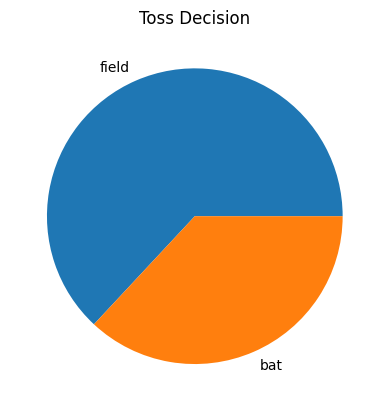

In [230]:
# Toss decision plot
ipl['TossDecision'].value_counts().plot(kind='pie', title='Toss Decision')

In [231]:
# How many matches each team has played
ipl['Team1'].value_counts() + ipl['Team2'].value_counts().sort_values(ascending=False)

Team1
Chennai Super Kings            208
Deccan Chargers                 75
Delhi Capitals                  63
Delhi Daredevils               161
Gujarat Lions                   30
Gujarat Titans                  16
Kings XI Punjab                190
Kochi Tuskers Kerala            14
Kolkata Knight Riders          223
Lucknow Super Giants            15
Mumbai Indians                 231
Pune Warriors                   46
Punjab Kings                    28
Rajasthan Royals               192
Rising Pune Supergiant          16
Rising Pune Supergiants         14
Royal Challengers Bangalore    226
Sunrisers Hyderabad            152
Name: count, dtype: int64


## `sort_values()`

Sort by any column. Works on both Series and DataFrame.

In [232]:
x = pd.Series([12, 14, 1, 56, 89])
x.sort_values(ascending=False)

4    89
3    56
1    14
0    12
2     1
dtype: int64

In [233]:
# DataFrame - sort by a column
movies = pd.read_csv('Datasets/movies.csv')
movies.sort_values('title_x', ascending=False).head()

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
939,Zor Lagaa Ke...Haiya!,tt1479857,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zor_Lagaa_Ke...H...,Zor Lagaa Ke... Haiya!,Zor Lagaa Ke... Haiya!,0,2009,\N,Comedy|Drama|Family,6.4,46,A tree narrates the story of four Mumbai-based...,Children build a tree-house to spy on a beggar...,NaN,Meghan Jadhav|Mithun Chakraborty|Riya Sen|Seem...,NaN,NaN
756,Zokkomon,tt1605790,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zokkomon,Zokkomon,Zokkomon,0,2011,109,Action|Adventure,4.0,274,After the passing of his parents in an acciden...,An orphan is abused and abandoned believed to...,Betrayal. Friendship. Bravery.,Darsheel Safary|Anupam Kher|Manjari Fadnnis|Ti...,NaN,22 April 2011 (India)
670,Zindagi Tere Naam,tt2164702,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zindagi_Tere_Naam,Zindagi Tere Naam,Zindagi Tere Naam,0,2012,120,Romance,4.7,27,Mr. Singh an elderly gentleman relates to hi...,Mr. Singh an elderly gentleman relates to hi...,NaN,Mithun Chakraborty|Ranjeeta Kaur|Priyanka Meht...,1 win,16 March 2012 (India)
778,Zindagi Na Milegi Dobara,tt1562872,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zindagi_Na_Mileg...,Zindagi Na Milegi Dobara,Zindagi Na Milegi Dobara,0,2011,155,Comedy|Drama,8.1,60826,Three friends decide to turn their fantasy vac...,Three friends decide to turn their fantasy vac...,NaN,Hrithik Roshan|Farhan Akhtar|Abhay Deol|Katrin...,30 wins & 22 nominations,15 July 2011 (India)


In [234]:
# Sort with NaN position
students.sort_values('name', na_position='first', ascending=False, inplace=True)
students

,iq,percent,lpa
name,,,
rupesh,120,100,14
rishabh,80,50,2
nitish,100,80,10
ankita,0,0,0
ankit,90,70,7
amit,0,0,0


In [235]:
# Sort by multiple columns
movies.sort_values(['year_of_release', 'title_x'], ascending=[True, False]).head()

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1622,Yeh Teraa Ghar Yeh Meraa Ghar,tt0298606,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Teraa_Ghar_Y...,Yeh Teraa Ghar Yeh Meraa Ghar,Yeh Teraa Ghar Yeh Meraa Ghar,0,2001,175,Comedy|Drama,5.7,704,In debt; Dayashankar Pandey is forced to go to...,In debt; Dayashankar Pandey is forced to go to...,NaN,Sunil Shetty|Mahima Chaudhry|Paresh Rawal|Saur...,1 nomination,12 October 2001 (India)
1620,Yeh Raaste Hain Pyaar Ke,tt0292740,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Raaste_Hain_...,Yeh Raaste Hain Pyaar Ke,Yeh Raaste Hain Pyaar Ke,0,2001,149,Drama|Romance,4.0,607,Two con artistes and car thieves Vicky (Ajay ...,Two con artistes and car thieves Vicky (Ajay ...,Love is a journey... not a destination,Ajay Devgn|Madhuri Dixit|Preity Zinta|Vikram G...,NaN,10 August 2001 (India)
1573,Yaadein (2001 film),tt0248617,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yaadein_(2001_film),Yaadein...,Yaadein...,0,2001,171,Drama|Musical|Romance,4.4,3034,Raj Singh Puri is best friends with L.K. Malho...,Raj Singh Puri is best friends with L.K. Malho...,memories to cherish...,Jackie Shroff|Hrithik Roshan|Kareena Kapoor|Am...,1 nomination,27 June 2001 (India)


**Parameters:**
- `ascending` - True/False or list for multiple columns
- `na_position` - 'first' or 'last' where to put NaN
- `inplace` - modify original DataFrame
- `by` - column name(s) to sort by


## `rank()`

Assigns ranks to values. Useful for creating rankings.

In [236]:
batsman = pd.read_csv('Datasets/batsman_runs_ipl.csv')
batsman

,batter,batsman_run
0,A Ashish Reddy,280
1,A Badoni,161
2,A Chandila,4
3,A Chopra,53
4,A Choudhary,25
...,...,...
600,Yash Dayal,0
601,Yashpal Singh,47
602,Younis Khan,3
603,Yuvraj Singh,2754


In [237]:
batsman['batting_rank'] = batsman['batsman_run'].rank(ascending=False)
batsman.sort_values('batting_rank')

,batter,batsman_run,batting_rank
569,V Kohli,6634,1.0
462,S Dhawan,6244,2.0
130,DA Warner,5883,3.0
430,RG Sharma,5881,4.0
493,SK Raina,5536,5.0
...,...,...,...
570,V Pratap Singh,0,594.0
63,Abdur Razzak,0,594.0
562,U Kaul,0,594.0
65,Akash Deep,0,594.0



## `sort_index()`

Sort by the index labels.

In [238]:
marks_dict = {'maths': 67, 'english': 57, 'science': 89, 'hindi': 100}
marks_series = pd.Series(marks_dict)
marks_series

maths       67
english     57
science     89
hindi      100
dtype: int64

In [239]:
marks_series.sort_index(ascending=False)

science     89
maths       67
hindi      100
english     57
dtype: int64

In [240]:
movies.sort_index(ascending=False).head()

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1628,Humsafar,tt2403201,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Humsafar,Humsafar,Humsafar,0,2011,35,Drama|Romance,9.0,2968,Sara and Ashar are childhood friends who share...,Ashar and Khirad are forced to get married due...,NaN,Fawad Khan|,NaN,TV Series (2011–2012)
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)



## `set_index()` and `reset_index()`

In [241]:
# set_index - make a column the index
batsman.set_index('batter', inplace=True)
batsman

,batsman_run,batting_rank
batter,,
A Ashish Reddy,280,166.5
A Badoni,161,226.0
A Chandila,4,535.0
A Chopra,53,329.0
A Choudhary,25,402.5
...,...,...
Yash Dayal,0,594.0
Yashpal Singh,47,343.0
Younis Khan,3,547.5


In [242]:
# reset_index - make index a column again
batsman.reset_index(inplace=True)
batsman

,batter,batsman_run,batting_rank
0,A Ashish Reddy,280,166.5
1,A Badoni,161,226.0
2,A Chandila,4,535.0
3,A Chopra,53,329.0
4,A Choudhary,25,402.5
...,...,...,...
600,Yash Dayal,0,594.0
601,Yashpal Singh,47,343.0
602,Younis Khan,3,547.5
603,Yuvraj Singh,2754,27.0


In [243]:
# Replace index without losing data
batsman.reset_index().set_index('batting_rank').head()

,index,batter,batsman_run
batting_rank,,,
166.5,0,A Ashish Reddy,280
226.0,1,A Badoni,161
535.0,2,A Chandila,4
329.0,3,A Chopra,53
402.5,4,A Choudhary,25


In [244]:
# Series to DataFrame using reset_index
marks_series.reset_index()

,index,0
0,maths,67
1,english,57
2,science,89
3,hindi,100



## `rename()`

Rename columns or index labels.

In [245]:
movies.set_index('title_x',inplace=True)

In [246]:
movies.rename(columns={'imdb_id': 'imdb', 'poster_path': 'link'}, inplace=True)

In [247]:
movies.rename(index={'Uri: The Surgical Strike':'Uri','Battalion 609':'Battalion'})

,imdb,link,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
title_x,,,,,,,,,,,,,,,,,
Uri,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
Battalion,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN


In [248]:
# Rename index
movies.rename(index={'Uri': 'URI'})

,imdb,link,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
title_x,,,,,,,,,,,,,,,,,
Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN



## `unique()` and `nunique()`

Get unique values and their count.

In [249]:
temp = pd.Series([1, 1, 2, 2, 3, 3, 4, 4, 5, 5, np.nan, np.nan])
temp

0     1.0
1     1.0
2     2.0
3     2.0
4     3.0
5     3.0
6     4.0
7     4.0
8     5.0
9     5.0
10    NaN
11    NaN
dtype: float64

In [250]:
temp.unique()

array([ 1.,  2.,  3.,  4.,  5., nan])

In [251]:
temp.nunique()

5

In [252]:
len(temp.unique())

6

In [253]:
ipl['Season'].nunique()

15

**`unique()` vs `nunique()`:**
- `unique()` returns the actual unique values (array)
- `nunique()` returns the count (integer)
- `nunique()` does NOT count NaN by default (use `dropna=False` to include)


## `isnull()`, `notnull()`, `hasnans`

Detect missing values.

In [254]:
import pandas as pd
student_dict = {
    'name': ['nitish', 'ankit', 'rupesh', 'rishabh', 'amit', 'ankita'],
    'iq': [100, 90, 120, 80, 0, 0],
    'marks': [80, 70, 100, 50, 0, 0],
    'package': [10, 7, 14, 2, 0, 0]
}

students = pd.DataFrame(student_dict)
students

,name,iq,marks,package
0,nitish,100,80,10
1,ankit,90,70,7
2,rupesh,120,100,14
3,rishabh,80,50,2
4,amit,0,0,0
5,ankita,0,0,0


In [255]:
students['name'][students['name'].isnull()]

Series([], Name: name, dtype: str)

In [256]:
students['name'][students['name'].notnull()]

0     nitish
1      ankit
2     rupesh
3    rishabh
4       amit
5     ankita
Name: name, dtype: str

In [257]:
# print('hasnans:', students['name'].hasnans)

In [258]:
students.isnull()

,name,iq,marks,package
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False



## `dropna()`

Remove missing values.

In [259]:
students.dropna(how='any')

,name,iq,marks,package
0,nitish,100,80,10
1,ankit,90,70,7
2,rupesh,120,100,14
3,rishabh,80,50,2
4,amit,0,0,0
5,ankita,0,0,0


In [260]:
students.dropna(how='all')

,name,iq,marks,package
0,nitish,100,80,10
1,ankit,90,70,7
2,rupesh,120,100,14
3,rishabh,80,50,2
4,amit,0,0,0
5,ankita,0,0,0


In [261]:
# Drop rows where specific columns have NaN
students.dropna(subset=['name'])

,name,iq,marks,package
0,nitish,100,80,10
1,ankit,90,70,7
2,rupesh,120,100,14
3,rishabh,80,50,2
4,amit,0,0,0
5,ankita,0,0,0


**`how` parameter:**
- `'any'` - drop if ANY value is NaN (default)
- `'all'` - drop only if ALL values are NaN


## `fillna()`

Fill missing values with a specified value.

In [262]:
students['name'].fillna('unknown')

0     nitish
1      ankit
2     rupesh
3    rishabh
4       amit
5     ankita
Name: name, dtype: str

In [263]:
students['package'].fillna(students['package'].mean())

0    10
1     7
2    14
3     2
4     0
5     0
Name: package, dtype: int64

In [264]:
# Backward fill - use next valid value
students['name'].bfill()

0     nitish
1      ankit
2     rupesh
3    rishabh
4       amit
5     ankita
Name: name, dtype: str


## `drop_duplicates()`

Remove duplicate rows.

In [265]:
temp = pd.Series([1, 1, 1, 2, 3, 3, 4, 4])
temp

0    1
1    1
2    1
3    2
4    3
5    3
6    4
7    4
dtype: int64

In [266]:
temp.drop_duplicates()

0    1
3    2
4    3
6    4
dtype: int64

In [267]:
students['name'].dropna()

0     nitish
1      ankit
2     rupesh
3    rishabh
4       amit
5     ankita
Name: name, dtype: str

**`keep` parameter:**
- `'first'` - keep first occurrence (default)
- `'last'` - keep last occurrence
- `False` - drop all duplicates


## `drop()`

Remove rows or columns.

In [268]:
temp = pd.Series([10, 2, 3, 16, 45, 78, 10])
temp.drop(index=[0, 6]).values

array([ 2,  3, 16, 45, 78])

In [269]:
students

,name,iq,marks,package
0,nitish,100,80,10
1,ankit,90,70,7
2,rupesh,120,100,14
3,rishabh,80,50,2
4,amit,0,0,0
5,ankita,0,0,0


In [270]:
students.drop(columns=['iq', 'marks'], inplace=True)
students

,name,package
0,nitish,10
1,ankit,7
2,rupesh,14
3,rishabh,2
4,amit,0
5,ankita,0



## `apply()`

Apply a function to each element. Very powerful for custom operations.

In [271]:
temp = pd.Series([10, 20, 30, 40, 50])
temp

0    10
1    20
2    30
3    40
4    50
dtype: int64

In [272]:
import numpy as np

In [273]:
def sigmoid(value):
    return 1 / (1 + np.exp(-value))

temp.apply(sigmoid)

0    0.999955
1    1.000000
2    1.000000
3    1.000000
4    1.000000
dtype: float64

In [274]:
def euclidean(row):
    pt_A = row['1st point']
    pt_B = row['2nd point']
    return ((pt_A[0] - pt_B[0])**2 + (pt_A[1] - pt_B[1])**2)**0.5


In [275]:
points = pd.DataFrame({
    '1st point': [(3,4), (-6,5), (0,0), (-10,1), (4,5)],
    '2nd point': [(-3,4), (0,0), (2,2), (10,10), (1,1)]
})

points['distance'] = points.apply(euclidean, axis=1)
points

,1st point,2nd point,distance
0,"(3, 4)","(-3, 4)",6.000000
1,"(-6, 5)","(0, 0)",7.810250
2,"(0, 0)","(2, 2)",2.828427
3,"(-10, 1)","(10, 10)",21.931712
4,"(4, 5)","(1, 1)",5.000000


**`axis` in apply:**
- `axis=0` - apply function to each column
- `axis=1` - apply function to each row


## `isin()`

Check if values exist in a list.

In [276]:
vk[vk.isin([49, 99])].head()

match_no
82    99
86    49
Name: runs, dtype: int64


## `nlargest()` and `nsmallest()`

Get top N or bottom N values efficiently.

In [277]:
batsman.nlargest(5, 'batsman_run')

,batter,batsman_run,batting_rank
569,V Kohli,6634,1.0
462,S Dhawan,6244,2.0
130,DA Warner,5883,3.0
430,RG Sharma,5881,4.0
493,SK Raina,5536,5.0


In [278]:
batsman.nsmallest(2, 'batsman_run')

,batter,batsman_run,batting_rank
57,AS Roy,0,594.0
63,Abdur Razzak,0,594.0



## `copy()`

Create an independent copy of a DataFrame.

In [279]:
original = students.head(3)
copy_df = original.copy()
copy_df.loc['nitish', 'marks'] = 9999
original

,name,package
0,nitish,10
1,ankit,7
2,rupesh,14


In [280]:
copy_df

,name,package,marks
0,nitish,10.0,NaN
1,ankit,7.0,NaN
2,rupesh,14.0,NaN
nitish,NaN,NaN,9999.0


**Always use `.copy()`** when you want to modify data without affecting the original.


## `corr()`

Compute correlation between numeric columns.

In [281]:
students[['iq', 'marks', 'package']].corr()

KeyError: "['iq', 'marks'] not in index"

**Correlation values:**
- `1.0` = perfect positive correlation
- `-1.0` = perfect negative correlation
- `0.0` = no correlation


## `insert()`

Insert a column at a specific position.

In [282]:
batsman.insert(2, 'new_col', [100]*len(batsman))
batsman

,batter,batsman_run,new_col,batting_rank
0,A Ashish Reddy,280,100,166.5
1,A Badoni,161,100,226.0
2,A Chandila,4,100,535.0
3,A Chopra,53,100,329.0
4,A Choudhary,25,100,402.5
...,...,...,...,...
600,Yash Dayal,0,100,594.0
601,Yashpal Singh,47,100,343.0
602,Younis Khan,3,100,547.5
603,Yuvraj Singh,2754,100,27.0



## Summary - DataFrame Functions Cheat Sheet

| Function | Purpose |
|----------|--------|
| `shape` | Get dimensions |
| `dtypes` | Get column data types |
| `info()` | Column-wise summary |
| `describe()` | Statistical summary |
| `head/tail/sample` | View data |
| `value_counts()` | Frequency distribution |
| `sort_values()` | Sort by column values |
| `sort_index()` | Sort by index |
| `rename()` | Rename columns/index |
| `set_index/reset_index` | Change index |
| `unique/nunique` | Unique values/count |
| `isnull/notnull` | Detect missing values |
| `dropna/fillna` | Handle missing values |
| `drop_duplicates` | Remove duplicates |
| `drop()` | Remove rows/columns |
| `apply()` | Apply custom function |
| `isin()` | Check membership |
| `nlargest/nsmallest` | Top/bottom N values |
| `corr()` | Correlation matrix |
| `copy()` | Independent copy |



## Key Takeaways

1. **DataFrame = Index + Columns + 2D Data** - the core of data analysis
2. **`iloc` for positions, `loc` for labels** - remember the difference!
3. **Filtering** with boolean conditions is the most common operation
4. **`apply()`** lets you run any custom function row-wise or column-wise
5. **Always use `.copy()`** when modifying a subset of data
6. **`axis=0` means along rows, `axis=1` means along columns**
7. **`inplace=True`** modifies the original; without it returns a new object

# Practice Problems - Pandas DataFrames


Work through these problems to master DataFrame operations. Each problem covers different concepts from the sections above.




## Dataset Setup

Let's load the datasets we'll use throughout the problems.

In [283]:
import pandas as pd
import numpy as np

pd.options.display.max_columns = None



**Dataset: Birds**

These problems focus on fundamental DataFrame operations - creating, selecting, filtering, and handling missing data.

### Q-1: Basic DataFrame Creation

**i.** Create a DataFrame `birds` from the dictionary data which has the index labels.

**ii.** Display basic information about the DataFrame.

**iii.** Show alternate rows of the DataFrame.

In [284]:
# code here
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'], 
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2], 
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']

df1 = pd.DataFrame(data = data, index = labels)

In [285]:
df1

,birds,age,visits,priority
a,Cranes,3.5,2,yes
b,Cranes,4.0,4,yes
c,plovers,1.5,3,no
d,spoonbills,NaN,4,NaN
e,spoonbills,6.0,3,no
f,Cranes,3.0,4,no
g,plovers,5.5,2,no
h,Cranes,NaN,2,yes
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no


In [286]:
# ii. Display basic information
df1.info()

<class 'pandas.DataFrame'>
Index: 11 entries, a to k
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   birds     11 non-null     str    
 1   age       9 non-null      float64
 2   visits    11 non-null     int64  
 3   priority  10 non-null     str    
dtypes: float64(1), int64(1), str(2)
memory usage: 561.0 bytes


In [287]:
df1.describe()

,age,visits
count,9.000000,11.000000
mean,4.333333,2.818182
std,1.903943,0.873863
min,1.500000,2.000000
25%,3.500000,2.000000
50%,4.000000,3.000000
75%,5.500000,3.500000
max,8.000000,4.000000


In [288]:
# iii. Show alternate rows (every 2nd row starting from index 0)
df1.iloc[::2]

,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
i,spoonbills,8.0,3,no
k,Cranes,3.5,2,yes


### Q-2: Selecting Rows and Columns

**i.** Show only rows `[1st, 3rd, 7th]` from columns `['birds', 'age']`.

**ii.** Select rows where the number of visits is less than 4.

In [289]:
# i. Select specific rows and columns
df1[['birds', 'age']].iloc[[0, 2, 6]]

,birds,age
a,Cranes,3.5
c,plovers,1.5
g,plovers,5.5


In [290]:
# ii. Filter rows where visits < 4
df1[df1.visits < 4]

,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
h,Cranes,NaN,2,yes
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no
k,Cranes,3.5,2,yes


**Key Concept:**
- `df[['col1', 'col2']]` to select columns
- `.iloc[[0, 2, 6]]` to select rows by position
- `df[df.visits < 4]` for boolean filtering

### Q-3: Handling Missing Values

**i.** Select all rows with NaN values in the `age` and `visits` columns.

**ii.** Fill NaN with the respective series mode value.

In [291]:
# i. Select rows where age OR visits is NaN
df1[df1.age.isna() | df1.visits.isna()]

,birds,age,visits,priority
d,spoonbills,NaN,4,NaN
h,Cranes,NaN,2,yes


In [292]:
# ii. Fill NaN with mode (most frequent value)
# .mode()[0] because mode() returns a Series

df1.age.fillna(df1.age.mode()[0], inplace=True)
df1.visits.fillna(df1.visits.mode()[0], inplace=True)
df1

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_22308\2705138014.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df1.age.fillna(df1.age.mode()[0], inplace=True)
C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_22308\2705138014.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through cha

,birds,age,visits,priority
a,Cranes,3.5,2,yes
b,Cranes,4.0,4,yes
c,plovers,1.5,3,no
d,spoonbills,NaN,4,NaN
e,spoonbills,6.0,3,no
f,Cranes,3.0,4,no
g,plovers,5.5,2,no
h,Cranes,NaN,2,yes
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no


### Q-4: Aggregation and Duplicates

**i.** Find the total number of visits of the bird 'Cranes'.

**ii.** Find the number of each type of bird in the DataFrame.

**iii.** Print number of duplicate rows.

**iv.** Drop duplicate rows and make this change permanent. Show DataFrame after changes.

In [293]:
# i. Total visits for Cranes
df1[df1.birds == 'Cranes'].visits.sum()

np.int64(14)

In [294]:
# ii. Count of each bird type
df1.birds.value_counts()

birds
Cranes        5
spoonbills    4
plovers       2
Name: count, dtype: int64

In [295]:
# iii. Number of duplicate rows
df1.duplicated().sum()

np.int64(1)

In [296]:
# iv. Drop duplicates permanently
df1.drop_duplicates(inplace=True)
df1.shape

(10, 4)

**Key Takeaways from Set 1:**
- Use `pd.DataFrame(dict, index=list)` to create labeled DataFrames
- `info()` and `describe()` give quick overview of data
- `iloc[::2]` selects alternate rows
- Boolean indexing: `df[df.column < value]`
- `isna()` detects NaN, `mode()[0]` gets the most frequent value
- `value_counts()` counts occurrences
- `duplicated().sum()` counts duplicate rows

## Question on IPL Data

IPL Data Link :  https://drive.google.com/file/d/1yKVUuexl6lIKuFQy7uIPgDgXhJ0L4SIg/view?usp=share_link

https://www.kaggle.com/datasets/vora1011/ipl-2008-to-2021-all-match-dataset?select=IPL_Matches_2008_2022.csv

Download ipl matches 2008-2022 file.

These problems use real IPL (Indian Premier League) cricket data. You'll practice filtering, groupby, and analysis.

### Q-5: Team Name Standardization

In IPL matches dataset, some team names have changed over the years. You need to consider them as the same team:

- `Delhi Capitals` formerly as `Delhi Daredevils`
- `Punjab Kings` formerly as `Kings XI Punjab`
- `Rising Pune Supergiant` formerly as `Rising Pune Supergiants`

You need to make changes accordingly. Consider current name for each team.

> Be careful! `Gujarat Titans` and `Gujarat Lions` are **different** teams.

In [297]:
# code here
data = pd.read_csv('Datasets/IPL_Matches_2008_2022.csv')
data.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [298]:
changed_name = {'Delhi Daredevils':'Delhi Capitals', 
                'Kings XI Punjab':'Punjab Kings',
                'Rising Pune Supergiants':'Rising Pune Supergiant'}

In [299]:
data.replace(changed_name.keys(), changed_name.values(),inplace=True )

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Capitals,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Capitals,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Punjab Kings,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


### Q-6: Top 5 Teams by Matches Played

Write code to display a bar chart of top 5 teams who have played the maximum number of matches in the IPL.

> **Hint:** The data is divided into 2 different columns (`Team1` and `Team2`). A team can appear in either column.

<Axes: xlabel='Team1'>

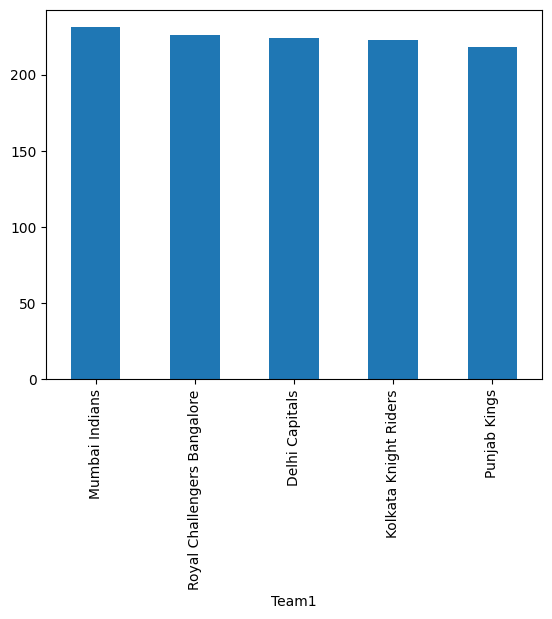

In [300]:
# code here
# Considering both team slots
(data['Team1'].value_counts()+data["Team2"].value_counts()).sort_values(ascending=False).head().plot(kind='bar')

**Explanation:**
- Each match has two teams: one in `Team1`, one in `Team2`
- We add both value_counts to get total appearances
- `.sort_values(ascending=False).head()` gives top 5

### Q-7: Player of the Match Against Mumbai Indians

Find the player who got the **most** Player of the Match award playing against Mumbai Indians.

> For this question, assume the Player of the Match award is given to players from the **winning** team.

In [301]:
# code here
m1 = (data.Team1 == "Mumbai Indians") | (data.Team2 == "Mumbai Indians")
m2 = data.WinningTeam != "Mumbai Indians"
data[m1 & m2].Player_of_Match.value_counts().head(1)

Player_of_Match
KL Rahul    4
Name: count, dtype: int64

### Q-8: Team vs Team Dashboard

Create a function `team1_vs_team2(t1, t2)` which takes two team names as input and shows:
1. Win/Loss record between them
2. Player with most Player of the Match award in matches between them

In [302]:
# code here
def team1_vs_team2(t1, t2):
    m1 = (data.Team1 == t1) | (data.Team2 == t1)  # Filter for matches where only t1 played
    m2 = (data.Team1 == t2) | (data.Team2 == t2)  # Filter for matches where only t1 played
    df1 = data[m1 & m2]
    print(df1.WinningTeam.value_counts())
    print(df1.Player_of_Match.value_counts().head(1))

team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')

WinningTeam
Chennai Super Kings      17
Kolkata Knight Riders     9
Name: count, dtype: int64
Player_of_Match
RA Jadeja    3
Name: count, dtype: int64


**Key Concept:** The double filter pattern `(Team1 == t1) | (Team2 == t1)` finds all matches where team `t1` played, then ANDing with the same for `t2` gives matches between them.

### Q-9: Top 7 Cities for KKR Matches

Find out the top 7 cities where the matches of Kolkata Knight Riders are played frequently and plot the result as a bar chart.

> `.plot(kind='bar')` can help you to plot the bar chart.

<Axes: xlabel='City'>

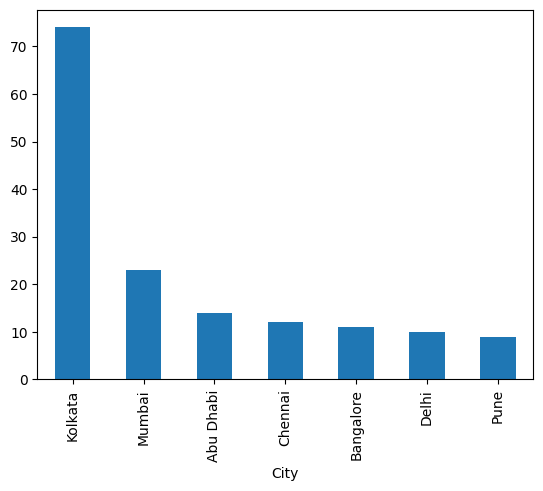

In [303]:
# code here
data[(data.Team1 == "Kolkata Knight Riders") | (data.Team2 == "Kolkata Knight Riders")].City.value_counts().head(7).plot(kind='bar')

### Q-10: Average Margin for Mumbai Indians in 2011

Find out the average margin for the team Mumbai Indians for only the season 2011.

In [304]:
data[((data.Team1 == "Mumbai Indians") | (data.Team2 == "Mumbai Indians")) & (data.Season == "2011")].Margin.mean()

np.float64(19.25)

**Key Takeaways from Set 2:**
- `replace()` can rename team categories across the entire DataFrame
- Combine value_counts from multiple columns: `df['A'].value_counts() + df['B'].value_counts()`
- Double filter pattern: `(Team1 == t) | (Team2 == t)` finds all matches involving team `t`
- Chain filtering: `df[condition1 & condition2]`
- `.plot(kind='bar')` for quick visualizations

In [305]:
import numpy as np
import pandas as pd

# to visualize all the column, run the below code
pd.options.display.max_columns = None
# to show all the records, use the below code
# pd.options.display.max_rows = None

## Fifa Worldcup - 2022 dataset.

You can find the dataset from [here](https://www.kaggle.com/datasets/sayanroy729/fifa-worldcup-2022-results).

Also you can directly use an url to read the dataset by using `pd.read_csv()` method. Check the below code cell.

These problems analyze football/soccer statistics from the 2022 World Cup.

In [306]:
df = pd.read_csv("Datasets/Fifa Worldcup 2022.csv")
df.head()

,Sl. No,Match No.,Team,Against,Group,Goal,Possession (%),Inside Penalty Area,Outside Penalty Area,Assists,Total Attempts,On Target,Off Target,Target in Penalty,Target from Outside,Left Channel,Left Inside Channel,Central Channel,Right Inside Channel,Right Channel,Receptions MD,Receptions D,Attempted Line Breaks,Completed Line Breaks,Attempted Defensive Line Breaks,Completed Defensive Line Breaks,Yellow Cards,Red Cards,Fouls Against,Offsides,Passes,Passes Completed,Crosses,Crosses Completed,Corners,Free Kicks,Penalties Scored,Pts
0,1,1,Qatar,Ecuador,A,0,40,0,0,0,5,0,5,2,3,15,0,3,1,9,45,5,159,100,6,4,4,0,15,3,453,387,10,5,1,19,0,0
1,2,1,Ecuador,Qatar,A,2,46,2,0,1,5,5,2,4,1,8,7,6,4,6,55,10,159,103,6,4,2,0,15,4,484,419,26,10,3,17,1,3
2,3,2,England,Iran,B,6,69,6,0,6,13,7,3,10,3,11,5,2,3,11,72,15,133,94,8,6,0,0,9,2,810,733,29,9,8,16,0,3
3,4,2,Iran,England,B,2,20,2,0,1,8,3,4,6,2,3,0,3,1,1,34,1,56,19,1,1,2,0,14,2,232,156,11,3,0,10,1,0
4,5,3,Senegal,Netherlands,A,0,39,0,0,0,15,4,7,8,7,12,4,2,4,13,101,12,143,86,6,6,2,0,13,2,391,326,22,8,6,14,0,0


### Q-1: On Target Percentage by Team

Find out the total percentages that each team made on target. Display the result as a Python dictionary where:
- Keys = team names
- Values = percentage values (rounded to 2 decimal places)

**Steps:**
1. Find all unique teams
2. For each team, calculate: `(total_on_target / total_attempts) * 100`
3. Sort the dictionary by values (descending)

**Sample Output:**
```python
{'Costa Rica': 54.55, 'Cameroon': 51.85, ..., 'Canada': 17.65}
```

In [307]:
# code here
all_teams = df['Team'].unique()
on_target_percentage = {}
for team in all_teams:
    total_attempts = df[df['Team'] == team]["Total Attempts"].sum()
    total_on_target = df[df['Team'] == team]["On Target"].sum()
    on_target_percentage[team] = round(total_on_target / total_attempts * 100, 2)

dict(sorted(on_target_percentage.items(), key = lambda x: x[1], reverse=True))

{'Costa Rica': np.float64(54.55),
 'Cameroon': np.float64(51.85),
 'Ecuador': np.float64(48.15),
 'Argentina': np.float64(46.15),
 'Brazil': np.float64(45.56),
 'England': np.float64(45.0),
 'Portugal': np.float64(40.32),
 'Ghana': np.float64(40.0),
 'Netherlands': np.float64(39.02),
 'Korea Republic': np.float64(36.73),
 'Australia': np.float64(36.0),
 'Mexico': np.float64(34.88),
 'France': np.float64(34.65),
 'Germany': np.float64(34.33),
 'Croatia': np.float64(33.73),
 'Spain': np.float64(32.69),
 'Belgium': np.float64(32.35),
 'Serbia': np.float64(32.26),
 'Iran': np.float64(31.43),
 'Uruguay': np.float64(31.25),
 'United States': np.float64(31.11),
 'Saudi Arabia': np.float64(31.03),
 'Senegal': np.float64(30.77),
 'Denmark': np.float64(30.56),
 'Switzerland': np.float64(30.56),
 'Japan': np.float64(30.23),
 'Wales': np.float64(29.17),
 'Qatar': np.float64(28.57),
 'Morocco': np.float64(28.33),
 'Tunisia': np.float64(26.67),
 'Poland': np.float64(25.0),
 'Canada': np.float64(17.6

**Key Concepts:**
- `unique()` gets all distinct team names
- Loop + filter + sum to aggregate per team
- `round(value, 2)` for 2 decimal places
- `dict(sorted(..., key=lambda x: x[1]))` to sort by values

### Q-2: Teams Played Count and Rank

Find out how many times each team played in this World Cup. Also find out the ranks of the teams.

> `DataFrame.rank()` takes a `method` parameter. Default is `average` (gives 2.5 values). Use `method='first'` for integer ranks.

In [308]:
df['Team'].value_counts().rank(method="first")

Team
Argentina         29.0
France            30.0
Morocco           31.0
Croatia           32.0
England           25.0
Netherlands       26.0
Portugal          27.0
Brazil            28.0
Senegal           17.0
United States     18.0
Poland            19.0
Australia         20.0
Japan             21.0
Spain             22.0
Switzerland       23.0
Korea Republic    24.0
Qatar              1.0
Ecuador            2.0
Iran               3.0
Wales              4.0
Saudi Arabia       5.0
Denmark            6.0
Tunisia            7.0
Mexico             8.0
Germany            9.0
Costa Rica        10.0
Belgium           11.0
Canada            12.0
Cameroon          13.0
Uruguay           14.0
Ghana             15.0
Serbia            16.0
Name: count, dtype: float64

### Q-3: Data Cleaning

Do the following:
- Show `info()` about the dataset
- Show `describe()` about the dataset
- Check for missing values and fill them with column average
- Drop all duplicate rows permanently
- Drop columns: `Sl. No`, `Match No.`, `Red Cards`, `Pts` permanently

In [309]:
# code here
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Sl. No                           128 non-null    int64
 1   Match No.                        128 non-null    int64
 2   Team                             128 non-null    str  
 3   Against                          128 non-null    str  
 4   Group                            128 non-null    str  
 5   Goal                             128 non-null    int64
 6   Possession (%)                   128 non-null    int64
 7   Inside Penalty Area              128 non-null    int64
 8   Outside Penalty Area             128 non-null    int64
 9   Assists                          128 non-null    int64
 10  Total Attempts                   128 non-null    int64
 11  On Target                        128 non-null    int64
 12  Off Target                       128 non-null    int64
 13  T

In [310]:
df.describe()

,Sl. No,Match No.,Goal,Possession (%),Inside Penalty Area,Outside Penalty Area,Assists,Total Attempts,On Target,Off Target,Target in Penalty,Target from Outside,Left Channel,Left Inside Channel,Central Channel,Right Inside Channel,Right Channel,Receptions MD,Receptions D,Attempted Line Breaks,Completed Line Breaks,Attempted Defensive Line Breaks,Completed Defensive Line Breaks,Yellow Cards,Red Cards,Fouls Against,Offsides,Passes,Passes Completed,Crosses,Crosses Completed,Corners,Free Kicks,Penalties Scored,Pts
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,32.500000,1.343750,43.476562,1.203125,0.117188,0.914062,11.257812,4.007812,4.835938,6.914062,4.343750,13.562500,4.671875,4.906250,4.648438,12.234375,92.703125,12.453125,169.281250,109.476562,14.812500,8.265625,1.726562,0.023438,12.320312,1.976562,502.859375,430.929688,19.523438,4.898438,4.468750,14.250000,0.335938,1.429688
std,37.094474,18.545539,1.342448,11.442403,1.324270,0.322907,1.150333,5.406683,2.588576,2.610630,3.998085,2.733397,6.901729,2.886595,3.080131,2.936573,6.176517,29.440547,18.152399,34.120661,30.776298,7.230458,5.101311,1.514834,0.151883,4.691983,1.731891,160.160487,160.893724,8.596799,3.520111,2.774852,4.712189,0.941412,1.389973
min,1.000000,1.000000,0.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,32.000000,0.000000,56.000000,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,225.000000,156.000000,4.000000,0.000000,0.000000,5.000000,0.000000,0.000000
25%,32.750000,16.750000,0.000000,35.000000,0.000000,0.000000,0.000000,7.750000,2.000000,3.000000,4.000000,3.000000,8.000000,2.000000,3.000000,3.000000,8.000000,72.750000,7.000000,149.500000,87.750000,10.000000,5.000000,1.000000,0.000000,9.000000,1.000000,398.250000,323.250000,13.000000,3.000000,2.000000,11.000000,0.000000,0.000000
50%,64.500000,32.500000,1.000000,45.000000,1.000000,0.000000,1.000000,10.000000,4.000000,4.000000,6.000000,4.000000,12.000000,4.500000,4.000000,4.000000,11.000000,93.000000,9.000000,170.500000,106.000000,15.000000,8.000000,2.000000,0.000000,12.000000,2.000000,495.500000,419.000000,19.000000,4.000000,4.000000,14.000000,0.000000,1.000000
75%,96.250000,48.250000,2.000000,51.000000,2.000000,0.000000,1.000000,14.000000,6.000000,6.000000,9.000000,5.000000,18.000000,7.000000,6.250000,6.000000,16.250000,111.250000,14.000000,188.000000,129.000000,20.000000,11.000000,2.000000,0.000000,15.000000,3.000000,589.500000,519.750000,24.000000,6.000000,6.000000,17.000000,0.000000,3.000000
max,128.000000,64.000000,7.000000,78.000000,7.000000,1.000000,6.000000,32.000000,13.000000,17.000000,24.000000,15.000000,36.000000,13.000000,16.000000,19.000000,29.000000,186.000000,192.000000,259.000000,192.000000,40.000000,27.000000,8.000000,1.000000,30.000000,10.000000,1070.000000,994.000000,53.000000,25.000000,14.000000,30.000000,5.000000,3.000000


In [311]:
df.isna().sum()

Sl. No                             0
Match No.                          0
Team                               0
Against                            0
Group                              0
Goal                               0
Possession (%)                     0
Inside Penalty Area                0
Outside Penalty Area               0
Assists                            0
Total Attempts                     0
On Target                          0
Off Target                         0
Target in Penalty                  0
Target from Outside                0
Left Channel                       0
Left Inside Channel                0
Central Channel                    0
Right Inside Channel               0
Right Channel                      0
Receptions MD                      0
Receptions D                       0
Attempted Line Breaks              0
Completed Line Breaks              0
Attempted Defensive Line Breaks    0
Completed Defensive Line Breaks    0
Yellow Cards                       0
R

In [312]:
df.drop_duplicates(inplace=True)
df

,Sl. No,Match No.,Team,Against,Group,Goal,Possession (%),Inside Penalty Area,Outside Penalty Area,Assists,Total Attempts,On Target,Off Target,Target in Penalty,Target from Outside,Left Channel,Left Inside Channel,Central Channel,Right Inside Channel,Right Channel,Receptions MD,Receptions D,Attempted Line Breaks,Completed Line Breaks,Attempted Defensive Line Breaks,Completed Defensive Line Breaks,Yellow Cards,Red Cards,Fouls Against,Offsides,Passes,Passes Completed,Crosses,Crosses Completed,Corners,Free Kicks,Penalties Scored,Pts
0,1,1,Qatar,Ecuador,A,0,40,0,0,0,5,0,5,2,3,15,0,3,1,9,45,5,159,100,6,4,4,0,15,3,453,387,10,5,1,19,0,0
1,2,1,Ecuador,Qatar,A,2,46,2,0,1,5,5,2,4,1,8,7,6,4,6,55,10,159,103,6,4,2,0,15,4,484,419,26,10,3,17,1,3
2,3,2,England,Iran,B,6,69,6,0,6,13,7,3,10,3,11,5,2,3,11,72,15,133,94,8,6,0,0,9,2,810,733,29,9,8,16,0,3
3,4,2,Iran,England,B,2,20,2,0,1,8,3,4,6,2,3,0,3,1,1,34,1,56,19,1,1,2,0,14,2,232,156,11,3,0,10,1,0
4,5,3,Senegal,Netherlands,A,0,39,0,0,0,15,4,7,8,7,12,4,2,4,13,101,12,143,86,6,6,2,0,13,2,391,326,22,8,6,14,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,124,62,Morocco,Fram,F,0,55,0,0,0,13,1,6,8,5,10,4,6,6,19,74,15,141,95,18,11,1,0,11,3,583,518,22,1,3,15,0,0
124,125,63,Croatia,Morocco,F,2,45,2,0,2,14,4,8,7,7,20,8,3,2,7,106,15,164,114,23,12,0,0,13,2,491,430,21,3,6,13,0,3
125,126,63,Morocco,Croatia,F,1,45,1,0,0,7,2,5,5,2,13,1,3,7,16,75,10,150,97,14,8,2,0,11,2,494,428,20,5,3,15,0,0
126,127,64,Argentina,France,C,3,46,3,0,1,21,9,9,13,8,13,6,8,9,9,163,28,249,172,40,24,4,0,26,4,648,544,20,4,6,22,5,3


In [313]:
df.drop(columns=["Sl. No", "Match No.", "Red Cards", "Pts"], inplace=True)
df

,Team,Against,Group,Goal,Possession (%),Inside Penalty Area,Outside Penalty Area,Assists,Total Attempts,On Target,Off Target,Target in Penalty,Target from Outside,Left Channel,Left Inside Channel,Central Channel,Right Inside Channel,Right Channel,Receptions MD,Receptions D,Attempted Line Breaks,Completed Line Breaks,Attempted Defensive Line Breaks,Completed Defensive Line Breaks,Yellow Cards,Fouls Against,Offsides,Passes,Passes Completed,Crosses,Crosses Completed,Corners,Free Kicks,Penalties Scored
0,Qatar,Ecuador,A,0,40,0,0,0,5,0,5,2,3,15,0,3,1,9,45,5,159,100,6,4,4,15,3,453,387,10,5,1,19,0
1,Ecuador,Qatar,A,2,46,2,0,1,5,5,2,4,1,8,7,6,4,6,55,10,159,103,6,4,2,15,4,484,419,26,10,3,17,1
2,England,Iran,B,6,69,6,0,6,13,7,3,10,3,11,5,2,3,11,72,15,133,94,8,6,0,9,2,810,733,29,9,8,16,0
3,Iran,England,B,2,20,2,0,1,8,3,4,6,2,3,0,3,1,1,34,1,56,19,1,1,2,14,2,232,156,11,3,0,10,1
4,Senegal,Netherlands,A,0,39,0,0,0,15,4,7,8,7,12,4,2,4,13,101,12,143,86,6,6,2,13,2,391,326,22,8,6,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,Morocco,Fram,F,0,55,0,0,0,13,1,6,8,5,10,4,6,6,19,74,15,141,95,18,11,1,11,3,583,518,22,1,3,15,0
124,Croatia,Morocco,F,2,45,2,0,2,14,4,8,7,7,20,8,3,2,7,106,15,164,114,23,12,0,13,2,491,430,21,3,6,13,0
125,Morocco,Croatia,F,1,45,1,0,0,7,2,5,5,2,13,1,3,7,16,75,10,150,97,14,8,2,11,2,494,428,20,5,3,15,0
126,Argentina,France,C,3,46,3,0,1,21,9,9,13,8,13,6,8,9,9,163,28,249,172,40,24,4,26,4,648,544,20,4,6,22,5


### Q-4: Rank and Set Index

Do these operations:
1. Find rank based on `Team` column and save as new column `Rank`
2. Change datatype to `np.int16`
3. Set index using `Rank` column permanently
4. Sort the DataFrame by `Rank` index

In [314]:
# code here
df["Rank"] = df["Team"].rank(method='first')
df["Rank"] = df["Rank"].astype(np.int16)
df.set_index("Rank", inplace=True)
df.sort_index()

,Team,Against,Group,Goal,Possession (%),Inside Penalty Area,Outside Penalty Area,Assists,Total Attempts,On Target,Off Target,Target in Penalty,Target from Outside,Left Channel,Left Inside Channel,Central Channel,Right Inside Channel,Right Channel,Receptions MD,Receptions D,Attempted Line Breaks,Completed Line Breaks,Attempted Defensive Line Breaks,Completed Defensive Line Breaks,Yellow Cards,Fouls Against,Offsides,Passes,Passes Completed,Crosses,Crosses Completed,Corners,Free Kicks,Penalties Scored
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Argentina,Saudi Arabia,C,1,51,1,0,0,14,6,6,10,4,12,4,5,8,18,91,27,195,127,10,8,0,7,10,593,525,36,15,9,21,1
2,Argentina,Mexico,C,2,50,1,1,2,5,2,3,2,3,10,6,2,4,12,89,2,150,100,10,5,1,15,2,533,464,14,2,4,23,0
3,Argentina,Poland,C,2,67,1,1,2,25,13,8,10,15,25,8,7,10,26,150,36,141,126,20,16,1,11,0,862,814,22,5,9,5,0
4,Argentina,Australia,C,2,53,2,0,1,14,5,7,11,3,15,6,11,2,17,127,8,181,135,16,8,0,8,4,711,635,6,1,1,15,0
5,Argentina,Netherlands,C,2,44,2,0,1,15,6,8,5,10,7,7,13,6,17,104,7,203,122,24,8,8,18,2,603,511,16,4,8,30,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,Uruguay,Portugal,H,0,35,0,0,0,10,3,6,6,4,13,8,4,5,9,94,6,150,86,17,11,2,16,0,390,306,18,5,2,13,0
125,Uruguay,Ghana,H,2,39,2,0,1,12,7,5,7,5,7,2,13,3,17,186,14,186,124,24,14,3,11,2,446,361,15,4,2,20,0
126,Wales,United States,B,1,39,1,0,0,7,3,3,5,2,7,2,5,2,7,73,9,174,103,17,8,2,10,1,409,321,15,6,3,15,1


**Key Takeaways from Set 3:**
- Loop through unique values and aggregate for each
- `dict(sorted(..., key=lambda x: x[1]))` sorts dictionary by values
- `rank(method='first')` gives integer ranks without ties
- `astype(np.int16)` converts to specific integer type
- `set_index()` + `sort_index()` for index-based operations

## Questions on Titanic dataset.

You can get the dataset from [here](https://www.kaggle.com/competitions/titanic). This is the competition page on Kaggle. To download the dataset from here, I guess you have to register for the compition. So, do so and then download the dataset.

Also, for now you can use this url to read the dataset like before: 
- dataset 1: https://docs.google.com/spreadsheets/d/e/2PACX-1vQjh5HzZ1N0SU7ME9ZQRzeVTaXaGsV97rU8R7eAcg53k27GTstJp9cRUOfr55go1GRRvTz1NwvyOnuh/pub?gid=1562145139&single=true&output=csv
- dataset 2: https://docs.google.com/spreadsheets/d/e/2PACX-1vQcPvQsSC9aNFogvbUG08nu0bGHlOclGYaOlhND_LE5Ff7ZnHQ5VYzAgpyT5XNklgiT54SsNgHePsUa/pub?gid=1656109608&single=true&output=csv

These problems use the famous Titanic dataset for practice with missing values and filtering.

### Q-5: Titanic Missing Values

**1.** With dataset 1, drop records which only have missing values in the `Age` column permanently.

**2.** With dataset 2, fill missing values with 20 in the `Age` column permanently.

In [315]:
titanic_df1 = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQjh5HzZ1N0SU7ME9ZQRzeVTaXaGsV97rU8R7eAcg53k27GTstJp9cRUOfr55go1GRRvTz1NwvyOnuh/pub?gid=1562145139&single=true&output=csv")
titanic_df2 = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQcPvQsSC9aNFogvbUG08nu0bGHlOclGYaOlhND_LE5Ff7ZnHQ5VYzAgpyT5XNklgiT54SsNgHePsUa/pub?gid=1656109608&single=true&output=csv")
titanic_df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [316]:
titanic_df2

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [317]:
titanic_df1.dropna(subset=["Age"], inplace=True)
titanic_df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [318]:
titanic_df2["Age"] = titanic_df2["Age"].fillna(20)
titanic_df2

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,20.0,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,20.0,0,0,359309,8.0500,NaN,S


**Key Concept:**
- `dropna(subset=['col'])` drops rows where specific column is NaN
- `fillna(value)` replaces all NaN with the given value
- `inplace=True` modifies the original DataFrame

**Key Takeaways from Set 4:**
- `dropna(subset=['col'])` removes rows with NaN in specific columns
- `fillna(value)` fills NaN with a constant
- These are the two most common ways to handle missing data

## Questions on IPL wala dataset

matches dataset = https://drive.google.com/file/d/1yKVUuexl6lIKuFQy7uIPgDgXhJ0L4SIg/view?usp=share_link

Code to directly use in colab

ipl_matches = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRy2DUdUbaKx_Co9F0FSnIlyS-8kp4aKv_I0-qzNeghiZHAI_hw94gKG22XTxNJHMFnFVKsO4xWOdIs/pub?gid=1655759976&single=true&output=csv"



These advanced problems build a complete IPL point table with win percentages, rankings, and season positions.

### Q-6: Team Statistics DataFrame

Make a DataFrame of each team in IPL with details like:
- Team Name
- Matches Played
- Win%
- Home Win% (Team1 = Home team)
- Away Win%

Show sorted DataFrame on Win%.

> **Note:** Exclude matches with 'no result'.

In [319]:
# code here
ipl_matches = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRy2DUdUbaKx_Co9F0FSnIlyS-8kp4aKv_I0-qzNeghiZHAI_hw94gKG22XTxNJHMFnFVKsO4xWOdIs/pub?gid=1655759976&single=true&output=csv"
matches = pd.read_csv(ipl_matches)
matches

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [320]:
changed_name = {'Delhi Daredevils':'Delhi Capitals', 
                'Kings XI Punjab':'Punjab Kings',
                'Rising Pune Supergiants':'Rising Pune Supergiant'}

In [321]:
matches.replace(changed_name.keys(), changed_name.values(),inplace=True )

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Capitals,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Capitals,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Punjab Kings,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [322]:
df = matches[~matches.WinningTeam.isna()]

In [323]:
new_df = pd.DataFrame()
teams = df.Team1.unique()

In [324]:
data = []
for team in teams:
    played = df[(df.Team1 == team) | (df.Team2 == team)].shape[0]
    wins = df[df.WinningTeam == team].shape[0]
    home_win = df[(df.WinningTeam == team) | (df.Team1 == team)].shape[0] / df[df.Team1 == team].shape[0] * 100
    away_win = df[(df.WinningTeam == team) | (df.Team2 == team)].shape[0] / df[df.Team2 == team].shape[0] * 100
    data.append([team, played, wins/played*100, home_win, away_win])
new_df[["Team", "Matches Played", "Win Percentage", "Home Win Percentage", "Away Win Percentage"]] = data
new_df.sort_values("Win Percentage", inplace=True, ascending=False)
new_df

,Team,Matches Played,Win Percentage,Home Win Percentage,Away Win Percentage
5,Gujarat Titans,16,75.0,214.285714,144.444444
6,Lucknow Super Giants,15,60.0,125.0,200.0
4,Chennai Super Kings,208,58.173077,150.45045,167.010309
9,Mumbai Indians,231,56.709957,158.928571,154.621849
7,Kolkata Knight Riders,223,51.121076,155.238095,147.457627
0,Rajasthan Royals,190,50.526316,152.808989,148.514851
10,Rising Pune Supergiant,30,50.0,157.142857,143.75
2,Sunrisers Hyderabad,152,49.342105,156.521739,143.373494
1,Royal Challengers Bangalore,223,48.878924,139.02439,161.0
3,Delhi Capitals,222,46.396396,144.247788,148.623853


### Q-7: Venues with Most No Result Matches

Find the venue with the most "no result" matches.

In [325]:
matches[matches.WonBy == "NoResults"].Venue.value_counts().index[0]

'M Chinnaswamy Stadium'

### Q-8: Most Appearances in Final

Find the player with the most appearances in IPL finals.

> `Team1Players` and `Team2Players` contain player names as **strings** (not lists). Handle with split/strip.

In [1]:
def getPlayers(l):
    return pd.Series(list(map(lambda x: x.strip("'"), l.lstrip("'[").rstrip("]'").split(", "))))

df_final = matches[matches["MatchNumber"] == "Final"]
players = []
for player_list in df_final.Team1Players:
    players.extend(getPlayers(player_list).tolist())

for player_list in df_final.Team2Players:
    players.extend(getPlayers(player_list).tolist())

playerSeries = pd.Series(players)
playerSeries.value_counts().head()

NameError: name 'matches' is not defined

**Key Concept:** String manipulation with `lstrip`, `rstrip`, `split`, and `strip` is essential when data is stored as formatted strings in CSV columns.

### Q-9: IPL Point Table Function

Create a function `point_table(season)` which takes a season parameter and shows the point table.

**Rules:**
- Win = 2 Points
- Loss = 0 Points
- No Result = 1 Point each team

**Output columns:** `TeamName`, `MatchesPlayed`, `MatchesWon`, `NoResult`, `Points`

**Season parameter values:**
```python
['2022', '2021', '2020/21', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011', '2009/10', '2009', '2007/08']
```

In [327]:
# code here
def matches_played(df, team):
    return df[(df.Team1 == team) | (df.Team2 == team)].shape[0]
def matches_won(df, team):
    return df[df.WinningTeam == team].shape[0]
def matches_no_result(df, team):
    return df[((df.Team1 == team) | (df.Team2 == team)) & (df.WinningTeam.isnull())].shape[0]

def point_table(season):
    df = matches[matches.Season == season]
    new_df = pd.DataFrame()
    new_df['Team Name'] = df.Team1.unique()
    new_df["Matches Played"] = new_df["Team Name"].apply(lambda x: matches_played(df, x))
    new_df["Matches Won"] = new_df["Team Name"].apply(lambda x: matches_won(df, x))
    new_df["No Result"] = new_df["Team Name"].apply(lambda x: matches_no_result(df, x))
    new_df["Points"] = new_df["Matches Won"]*2 + new_df["No Result"]
    new_df.sort_values("Points", ascending = False, inplace=True)
    new_df.set_index("Team Name", inplace=True)
    return new_df
point_table("2022")

,Matches Played,Matches Won,No Result,Points
Team Name,,,,
Gujarat Titans,16,12,0,24
Rajasthan Royals,17,10,0,20
Royal Challengers Bangalore,16,9,0,18
Lucknow Super Giants,15,9,0,18
Punjab Kings,14,7,0,14
Delhi Capitals,14,7,0,14
Kolkata Knight Riders,14,6,0,12
Sunrisers Hyderabad,14,6,0,12
Chennai Super Kings,14,4,0,8


**Key Concept:** Using `apply(lambda x: function(df, x))` lets you compute a value for each row by calling a helper function.

### Q-10: IPL Point Table with Season Position

Extend the point table with a `SeasonPosition` column:

- Top 4 positions after sorting by Points (then TeamName):
  - `Winner` - Team that won the Final
  - `Runner` - Team that lost the Final
  - `3` - Losing team in Qualifier 2
  - `4` - Losing team in Eliminator
- All other teams get their rank number

Use `df.at[row_index, col_label] = value` to change specific cell values.

> **Note:** Make a copy with `df.copy()` to avoid SettingWithCopyWarning.

In [2]:
def point_table_extension(season):
    df3 = point_table(season)
    df = matches[matches.Season == season].copy()

    df3["SeasonPosition"] = df3.Points.rank(ascending=False, method='first').astype('object')

    df["LoosingTeam"] = pd.concat([
        df.loc[df.WinningTeam == df.Team1, "Team2"],
        df.loc[df.WinningTeam == df.Team2, "Team1"]
    ])

    final = df[df["MatchNumber"] == "Final"]
    wining_team = final.WinningTeam.values[0]
    runner = final.LoosingTeam.values[0]
    df3.at[wining_team, "SeasonPosition"] = "Winner"
    df3.at[runner, "SeasonPosition"] = "Runner"

    q = df[df["MatchNumber"] == "Qualifier 2"]
    e = df[df["MatchNumber"] == "Eliminator"]
    third = q.LoosingTeam.values[0]
    fourth = e.LoosingTeam.values[0]
    df3.at[third, "SeasonPosition"] = "Third"
    df3.at[fourth, "SeasonPosition"] = "Fourth"

    return df3

point_table_extension("2022")

NameError: name 'point_table' is not defined

**Key Concepts from Set 5:**
- `~df.WinningTeam.isna()` to exclude no-result matches
- `shape[0]` to count rows (faster than `len()`)
- `apply(lambda x: func(df, x))` for row-wise computation
- `df.at[index, column]` for precise cell value assignment
- `rank(method='first')` for non-tied ranking
- Always use `.copy()` when modifying a filtered DataFrame

# GroupBy in Pandas


## What is GroupBy?

**GroupBy** is the process of splitting the data into groups based on some criteria, applying a function to each group independently, and combining the results.

```
GroupBy = Split + Apply + Combine

Split:  Group data by a column
Apply:  Apply a function to each group
Combine: Merge results back together
```

> Think of it like SQL's `GROUP BY` clause.

- **Dataset :** https://drive.google.com/drive/folders/1IiMIOGCv-giUV_rtF02sImgkaVuAQxkz?usp=share_link


## Creating a GroupBy Object

The `groupby()` method creates a GroupBy object. You specify the column(s) to group by.

In [90]:
import pandas as pd
import numpy as np

In [91]:
movies = pd.read_csv('Datasets/imdb-top-1000.csv')
movies.head()

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0,90.0
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689845,4360000.0,96.0


In [92]:
movies.shape

(1000, 10)

In [93]:
# Create GroupBy object
genres = movies.groupby('Genre')

In [94]:
type(genres)

pandas.api.typing.DataFrameGroupBy

In [95]:
len(genres)

14

**What happened?**
- The DataFrame was split into groups based on unique values in the `Genre` column
- Each group contains rows belonging to that genre
- The GroupBy object is lazy - no computation happens until you apply a function


## Applying Aggregation Functions

You can apply built-in aggregation functions directly on the GroupBy object.

In [96]:
# Apply aggregation on all numeric columns
genres.std(numeric_only=True)

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,28.500706,0.304258,432946.814748,2.256724e+08,12.421252
Adventure,33.317320,0.229781,301188.347642,1.697543e+08,12.345393
Animation,14.530471,0.253221,262173.231571,2.091840e+08,8.813646
Biography,25.514466,0.267140,271284.191372,1.363251e+08,11.028187
Comedy,22.946213,0.228771,188653.570564,1.946513e+08,11.829160
Crime,27.689231,0.335477,373999.730656,1.571191e+08,13.099102
Drama,27.740490,0.267229,305554.162841,2.201164e+08,12.744687
Family,10.606602,0.000000,137008.302816,3.048412e+08,16.970563
Fantasy,12.727922,0.141421,22179.111299,7.606861e+07,NaN


In [97]:
# Apply aggregation on a specific column
genres['IMDB_Rating'].mean(numeric_only=True)

Genre
Action       7.949419
Adventure    7.937500
Animation    7.930488
Biography    7.938636
Comedy       7.901290
Crime        8.016822
Drama        7.957439
Family       7.800000
Fantasy      8.000000
Film-Noir    7.966667
Horror       7.909091
Mystery      7.975000
Thriller     7.800000
Western      8.350000
Name: IMDB_Rating, dtype: float64


## GroupBy Attributes and Methods

| Method | Description |
|--------|-------------|
| `len()` | Total number of groups |
| `size()` | Items in each group |
| `first()` | First item in each group |
| `last()` | Last item in each group |
| `nth(n)` | nth item in each group |
| `get_group(name)` | Get specific group |
| `groups` | Dictionary of groups |
| `describe()` | Statistical summary |
| `sample(n)` | Random sample from groups |
| `nunique()` | Number of unique values |

In [98]:
# Number of groups
len(genres)

14

In [99]:
movies['Genre'].nunique()

14

In [100]:
# Size of each group
genres.size()

Genre
Action       172
Adventure     72
Animation     82
Biography     88
Comedy       155
Crime        107
Drama        289
Family         2
Fantasy        2
Film-Noir      3
Horror        11
Mystery       12
Thriller       1
Western        4
dtype: int64

In [101]:
# First item in each group
genres.first()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,The Dark Knight,2008,152,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
Adventure,Interstellar,2014,169,8.6,Christopher Nolan,Matthew McConaughey,1512360,188020017.0,74.0
Animation,Sen to Chihiro no kamikakushi,2001,125,8.6,Hayao Miyazaki,Daveigh Chase,651376,10055859.0,96.0
Biography,Schindler's List,1993,195,8.9,Steven Spielberg,Liam Neeson,1213505,96898818.0,94.0
Comedy,Gisaengchung,2019,132,8.6,Bong Joon Ho,Kang-ho Song,552778,53367844.0,96.0
Crime,The Godfather,1972,175,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
Drama,The Shawshank Redemption,1994,142,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
Family,E.T. the Extra-Terrestrial,1982,115,7.8,Steven Spielberg,Henry Thomas,372490,435110554.0,91.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,8.1,Robert Wiene,Werner Krauss,57428,337574718.0,NaN


In [102]:
# Last item in each group
genres.last()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,Escape from Alcatraz,1979,112,7.6,Don Siegel,Clint Eastwood,121731,43000000.0,76.0
Adventure,Kelly's Heroes,1970,144,7.6,Brian G. Hutton,Clint Eastwood,45338,1378435.0,50.0
Animation,The Jungle Book,1967,78,7.6,Wolfgang Reitherman,Phil Harris,166409,141843612.0,65.0
Biography,Midnight Express,1978,121,7.6,Alan Parker,Brad Davis,73662,35000000.0,59.0
Comedy,Breakfast at Tiffany's,1961,115,7.6,Blake Edwards,Audrey Hepburn,166544,679874270.0,76.0
Crime,The 39 Steps,1935,86,7.6,Alfred Hitchcock,Robert Donat,51853,302787539.0,93.0
Drama,Lifeboat,1944,97,7.6,Alfred Hitchcock,Tallulah Bankhead,26471,852142728.0,78.0
Family,Willy Wonka & the Chocolate Factory,1971,100,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0
Fantasy,Nosferatu,1922,94,7.9,F.W. Murnau,Max Schreck,88794,445151978.0,NaN


In [103]:
# nth item (6th movie in each genre group)
genres.nth(6)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
16,Star Wars: Episode V - The Empire Strikes Back,1980,124,Action,8.7,Irvin Kershner,Mark Hamill,1159315,290475067.0,82.0
27,Se7en,1995,127,Crime,8.6,David Fincher,Morgan Freeman,1445096,100125643.0,65.0
32,It's a Wonderful Life,1946,130,Drama,8.6,Frank Capra,James Stewart,405801,82385199.0,89.0
66,WALL·E,2008,98,Animation,8.4,Andrew Stanton,Ben Burtt,999790,223808164.0,95.0
83,The Great Dictator,1940,125,Comedy,8.4,Charles Chaplin,Charles Chaplin,203150,288475.0,NaN
102,Braveheart,1995,178,Biography,8.3,Mel Gibson,Mel Gibson,959181,75600000.0,68.0
118,North by Northwest,1959,136,Adventure,8.3,Alfred Hitchcock,Cary Grant,299198,13275000.0,98.0
420,Sleuth,1972,138,Mystery,8.0,Joseph L. Mankiewicz,Laurence Olivier,44748,4081254.0,NaN
724,Get Out,2017,104,Horror,7.7,Jordan Peele,Daniel Kaluuya,492851,176040665.0,85.0


In [104]:
# Get a specific group
genres.get_group('Fantasy')

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
321,Das Cabinet des Dr. Caligari,1920,76,Fantasy,8.1,Robert Wiene,Werner Krauss,57428,337574718.0,NaN
568,Nosferatu,1922,94,Fantasy,7.9,F.W. Murnau,Max Schreck,88794,445151978.0,NaN


In [105]:
# Equivalent filtering
movies[movies['Genre'] == 'Fantasy']

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
321,Das Cabinet des Dr. Caligari,1920,76,Fantasy,8.1,Robert Wiene,Werner Krauss,57428,337574718.0,NaN
568,Nosferatu,1922,94,Fantasy,7.9,F.W. Murnau,Max Schreck,88794,445151978.0,NaN


In [106]:
# Groups dictionary
genres.groups

{'Action': [2, 5, 8, 10, 13, 14, 16, 29, 30, 31, 39, 42, 44, 55, 57, 59, 60, 63, 68, 72, 106, 109, 129, 130, 134, 140, 142, 144, 152, 155, 160, 161, 166, 168, 171, 172, 177, 181, 194, 201, 202, 216, 217, 223, 224, 236, 241, 262, 275, 294, 308, 320, 325, 326, 331, 337, 339, 340, 343, 345, 348, 351, 353, 356, 357, 362, 368, 369, 375, 376, 390, 410, 431, 436, 473, 477, 479, 482, 488, 493, 496, 502, 507, 511, 532, 535, 540, 543, 564, 569, 570, 573, 577, 582, 583, 602, 605, 608, 615, 623, ...], 'Adventure': [21, 47, 93, 110, 114, 116, 118, 137, 178, 179, 191, 193, 209, 226, 231, 247, 267, 273, 281, 300, 301, 304, 306, 323, 329, 361, 366, 377, 402, 406, 415, 426, 458, 470, 497, 498, 506, 513, 514, 537, 549, 552, 553, 566, 576, 604, 609, 618, 638, 647, 675, 681, 686, 692, 711, 713, 739, 755, 781, 797, 798, 851, 873, 884, 912, 919, 947, 957, 964, 966, 984, 991], 'Animation': [23, 43, 46, 56, 58, 61, 66, 70, 101, 135, 146, 151, 158, 170, 197, 205, 211, 213, 219, 229, 230, 242, 245, 246, 270, 33

In [107]:
# Statistical summary
genres.describe()

Runtime                                                              \
            count        mean        std    min     25%    50%     75%    max   
Genre                                                                           
Action      172.0  129.046512  28.500706   45.0  110.75  127.5  143.25  321.0   
Adventure    72.0  134.111111  33.317320   88.0  109.00  127.0  149.00  228.0   
Animation    82.0   99.585366  14.530471   71.0   90.00   99.5  106.75  137.0   
Biography    88.0  136.022727  25.514466   93.0  120.00  129.0  146.25  209.0   
Comedy      155.0  112.129032  22.946213   68.0   96.00  106.0  124.50  188.0   
Crime       107.0  126.392523  27.689231   80.0  106.50  122.0  141.50  229.0   
Drama       289.0  124.737024  27.740490   64.0  105.00  121.0  137.00  242.0   
Family        2.0  107.500000  10.606602  100.0  103.75  107.5  111.25  115.0   
Fantasy       2.0   85.000000  12.727922   76.0   80.50   85.0   89.50   94.0   
Film-Noir     3.0  104.000000   4.000000  100.0  102.00  104.0  106.00  108.0   
Horror       11.0  102.090909  13.604812   71.0   98.00  103.0  109.00  122.0   
Mystery      12.0  119.083333  14.475423   96.0  110.75  117.5  130.25  138.0   
Thriller      1.0  108.000000        NaN  108.0  108.00  108.0  108.00  108.0   
Western       4.0  148.250000  17.153717  132.0  134.25  148.0  162.00  165.0   

          IMDB_Rating            ...         Gross              Metascore  \
                count      mean  ...           75%          max     count   
Genre                            ...                                        
Action          172.0  7.949419  ...  2.674437e+08  936662225.0     143.0   
Adventure        72.0  7.937500  ...  1.998070e+08  874211619.0      64.0   
Animation        82.0  7.930488  ...  2.520612e+08  873839108.0      75.0   
Biography        88.0  7.938636  ...  9.829924e+07  753585104.0      79.0   
Comedy          155.0  7.901290  ...  8.107809e+07  886752933.0     125.0   
Crime           107.0  8.016822  ...  7.102163e+07  790482117.0      87.0   
Drama           289.0  7.957439  ...  1.164461e+08  924558264.0     241.0   
Family            2.0  7.800000  ...  3.273329e+08  435110554.0       2.0   
Fantasy           2.0  8.000000  ...  4.182577e+08  445151978.0       0.0   
Film-Noir         3.0  7.966667  ...  6.273068e+07  123353292.0       3.0   
Horror           11.0  7.909091  ...  1.362817e+08  298791505.0      11.0   
Mystery          12.0  7.975000  ...  1.310949e+08  474203697.0       8.0   
Thriller          1.0  7.800000  ...  1.755074e+07   17550741.0       1.0   
Western           4.0  8.350000  ...  1.920000e+07   31800000.0       4.0   

                                                                  
                mean        std   min    25%   50%    75%    max  
Genre                                                             
Action     73.419580  12.421252  33.0  65.00  74.0  82.00   98.0  
Adventure  78.437500  12.345393  41.0  69.75  80.5  87.25  100.0  
Animation  81.093333   8.813646  61.0  75.00  82.0  87.50   96.0  
Biography  76.240506  11.028187  48.0  70.50  76.0  84.50   97.0  
Comedy     78.720000  11.829160  45.0  72.00  79.0  88.00   99.0  
Crime      77.080460  13.099102  47.0  69.50  77.0  87.00  100.0  
Drama      79.701245  12.744687  28.0  72.00  82.0  89.00  100.0  
Family     79.000000  16.970563  67.0  73.00  79.0  85.00   91.0  
Fantasy          NaN        NaN   NaN    NaN   NaN    NaN    NaN  
Film-Noir  95.666667   1.527525  94.0  95.00  96.0  96.50   97.0  
Horror     80.000000  15.362291  46.0  77.50  87.0  88.50   97.0  
Mystery    79.125000  18.604435  52.0  65.25  77.0  98.50  100.0  
Thriller   81.000000        NaN  81.0  81.00  81.0  81.00   81.0  
Western    78.250000   9.032349  69.0  72.75  77.0  82.50   90.0  

[14 rows x 40 columns]

In [108]:
# Random sample (2 movies from each genre, with replacement)
genres.sample(2, replace=True)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
648,The Boondock Saints,1999,108,Action,7.8,Troy Duffy,Willem Dafoe,227143,25812.0,44.0
241,Kill Bill: Vol. 1,2003,111,Action,8.1,Quentin Tarantino,Uma Thurman,1000639,70099045.0,69.0
686,The Right Stuff,1983,193,Adventure,7.8,Philip Kaufman,Sam Shepard,56235,21500000.0,91.0
537,La montaña sagrada,1973,114,Adventure,7.9,Alejandro Jodorowsky,Alejandro Jodorowsky,37183,61001.0,76.0
389,The Iron Giant,1999,86,Animation,8.0,Brad Bird,Eli Marienthal,172083,23159305.0,85.0
46,Hotaru no haka,1988,89,Animation,8.5,Isao Takahata,Tsutomu Tatsumi,235231,150734678.0,94.0
766,The Last King of Scotland,2006,123,Biography,7.7,Kevin Macdonald,James McAvoy,175355,17605861.0,74.0
176,The Message,1976,177,Biography,8.2,Moustapha Akkad,Anthony Quinn,43885,216427395.0,NaN
879,Once Upon a Time... in Hollywood,2019,161,Comedy,7.6,Quentin Tarantino,Leonardo DiCaprio,551309,142502728.0,83.0
256,Underground,1995,170,Comedy,8.1,Emir Kusturica,Predrag 'Miki' Manojlovic,55220,171082.0,NaN


In [109]:
# Number of unique values per group
genres.nunique()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,172,61,78,15,123,121,172,172,50
Adventure,72,49,58,10,59,59,72,72,33
Animation,82,35,41,11,51,77,82,82,29
Biography,88,44,56,13,76,72,88,88,40
Comedy,155,72,70,11,113,133,155,155,44
Crime,106,56,65,14,86,85,107,107,39
Drama,289,83,95,14,211,250,288,287,52
Family,2,2,2,1,2,2,2,2,2
Fantasy,2,2,2,2,2,2,2,2,0



## GroupBy with Practice Questions

Now let's apply GroupBy to solve real problems.

### Q-1: Top 3 Genres by Total Earning

In [110]:
# Method 1: Bracket notation
movies.groupby('Genre').sum(numeric_only=True)['Gross'].sort_values(ascending=False).head(3)

Genre
Drama     3.540997e+10
Action    3.263226e+10
Comedy    1.566387e+10
Name: Gross, dtype: float64

In [111]:
# Method 2: Dot notation (column first, then aggregation)
movies.groupby('Genre')['Gross'].sum().sort_values(ascending=False).head(3)

Genre
Drama     3.540997e+10
Action    3.263226e+10
Comedy    1.566387e+10
Name: Gross, dtype: float64

**Note:** Both methods give the same result. Method 2 is cleaner when working with specific columns.

### Q-2: Genre with Highest Average IMDB Rating

In [112]:
movies.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False).head(1)

Genre
Western    8.35
Name: IMDB_Rating, dtype: float64

### Q-3: Director with Most Popularity (by total votes)

In [113]:
movies.groupby('Director')['No_of_Votes'].sum().sort_values(ascending=False).head(1)

Director
Christopher Nolan    11578345
Name: No_of_Votes, dtype: int64

### Q-4: Highest Rated Movie of Each Genre

In [114]:
movies.groupby('Genre')['IMDB_Rating'].max()

Genre
Action       9.0
Adventure    8.6
Animation    8.6
Biography    8.9
Comedy       8.6
Crime        9.2
Drama        9.3
Family       7.8
Fantasy      8.1
Film-Noir    8.1
Horror       8.5
Mystery      8.4
Thriller     7.8
Western      8.8
Name: IMDB_Rating, dtype: float64

This shows the highest IMDB rating per genre. To get the actual movie names, you can use `idxmax()` or filtering.

### Q-5: Number of Movies Done by Each Actor

In [115]:
movies.groupby('Star1')['Series_Title'].count().sort_values(ascending=False)

Star1
Tom Hanks               12
Robert De Niro          11
Clint Eastwood          10
Al Pacino               10
Humphrey Bogart          9
                        ..
Zbigniew Zamachowski     1
Zooey Deschanel          1
Çetin Tekindor           1
Éric Toledano            1
Aaron Taylor-Johnson     1
Name: Series_Title, Length: 660, dtype: int64


## The `agg()` Method

The `agg()` (aggregate) method lets you apply different functions to different columns. You can pass a **dictionary** or a **list** of functions.

### Passing a Dictionary

Apply different functions to different columns.

In [116]:
genres.agg(
    {
        'Runtime': 'mean',
        'IMDB_Rating': 'mean',
        'No_of_Votes': 'sum',
        'Gross': 'sum',
        'Metascore': 'min'
    }
)

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,129.046512,7.949419,72282412,3.263226e+10,33.0
Adventure,134.111111,7.937500,22576163,9.496922e+09,41.0
Animation,99.585366,7.930488,21978630,1.463147e+10,61.0
Biography,136.022727,7.938636,24006844,8.276358e+09,48.0
Comedy,112.129032,7.901290,27620327,1.566387e+10,45.0
Crime,126.392523,8.016822,33533615,8.452632e+09,47.0
Drama,124.737024,7.957439,61367304,3.540997e+10,28.0
Family,107.500000,7.800000,551221,4.391106e+08,67.0
Fantasy,85.000000,8.000000,146222,7.827267e+08,NaN


### Passing a List

Apply multiple functions to all columns.

In [117]:
numeric_cols = movies.select_dtypes(include='number').columns
genres = movies.groupby("Genre")[numeric_cols].agg(['min', 'max', 'mean', 'sum'])
genres

Runtime                         IMDB_Rating                         \
              min  max        mean    sum         min  max      mean     sum   
Genre                                                                          
Action         45  321  129.046512  22196         7.6  9.0  7.949419  1367.3   
Adventure      88  228  134.111111   9656         7.6  8.6  7.937500   571.5   
Animation      71  137   99.585366   8166         7.6  8.6  7.930488   650.3   
Biography      93  209  136.022727  11970         7.6  8.9  7.938636   698.6   
Comedy         68  188  112.129032  17380         7.6  8.6  7.901290  1224.7   
Crime          80  229  126.392523  13524         7.6  9.2  8.016822   857.8   
Drama          64  242  124.737024  36049         7.6  9.3  7.957439  2299.7   
Family        100  115  107.500000    215         7.8  7.8  7.800000    15.6   
Fantasy        76   94   85.000000    170         7.9  8.1  8.000000    16.0   
Film-Noir     100  108  104.000000    312         7.8  8.1  7.966667    23.9   
Horror         71  122  102.090909   1123         7.6  8.5  7.909091    87.0   
Mystery        96  138  119.083333   1429         7.6  8.4  7.975000    95.7   
Thriller      108  108  108.000000    108         7.8  7.8  7.800000     7.8   
Western       132  165  148.250000    593         7.8  8.8  8.350000    33.4   

          No_of_Votes                                          Gross  \
                  min      max           mean       sum          min   
Genre                                                                  
Action          25312  2303232  420246.581395  72282412       3296.0   
Adventure       29999  1512360  313557.819444  22576163      61001.0   
Animation       25229   999790  268032.073171  21978630     128985.0   
Biography       27254  1213505  272805.045455  24006844      21877.0   
Comedy          26337   939631  178195.658065  27620327       1305.0   
Crime           27712  1826188  313398.271028  33533615       6013.0   
Drama           25088  2343110  212343.612457  61367304       3600.0   
Family         178731   372490  275610.500000    551221    4000000.0   
Fantasy         57428    88794   73111.000000    146222  337574718.0   
Film-Noir       59556   158731  122405.000000    367215     449191.0   
Horror          27007   787806  340232.363636   3742556      89029.0   
Mystery         33982  1129894  350250.333333   4203004    1035953.0   
Thriller        27733    27733   27733.000000     27733   17550741.0   
Western         65659   688390  322416.250000   1289665    5321508.0   

                                                   Metascore         \
                   max          mean           sum       min    max   
Genre                                                                 
Action     936662225.0  1.897224e+08  3.263226e+10      33.0   98.0   
Adventure  874211619.0  1.319017e+08  9.496922e+09      41.0  100.0   
Animation  873839108.0  1.784326e+08  1.463147e+10      61.0   96.0   
Biography  753585104.0  9.404952e+07  8.276358e+09      48.0   97.0   
Comedy     886752933.0  1.010572e+08  1.566387e+10      45.0   99.0   
Crime      790482117.0  7.899656e+07  8.452632e+09      47.0  100.0   
Drama      924558264.0  1.225259e+08  3.540997e+10      28.0  100.0   
Family     435110554.0  2.195553e+08  4.391106e+08      67.0   91.0   
Fantasy    445151978.0  3.913633e+08  7.827267e+08       NaN    NaN   
Film-Noir  123353292.0  4.197018e+07  1.259105e+08      94.0   97.0   
Horror     298791505.0  9.405902e+07  1.034649e+09      46.0   97.0   
Mystery    474203697.0  1.047014e+08  1.256417e+09      52.0  100.0   
Thriller    17550741.0  1.755074e+07  1.755074e+07      81.0   81.0   
Western     31800000.0  1.455538e+07  5.822151e+07      69.0   90.0   

                               
                mean      sum  
Genre                          
Action     73.419580  10499.0  
Adventure  78.437500   5020.0  
Animation  81.093333   6082.0  
Biography  76.240506   6

### Mixed Syntax

Different functions for different columns using both dict and list.

In [118]:
genres = movies.groupby("Genre")[numeric_cols]

In [119]:
genres.agg(
{
'Runtime':['min','mean'],
'IMDB_Rating':'mean',
'No_of_Votes':['sum','max'],
'Gross':'sum',
'Metascore':'min'
}
)

Runtime             IMDB_Rating No_of_Votes                  Gross  \
              min        mean        mean         sum      max           sum   
Genre                                                                          
Action         45  129.046512    7.949419    72282412  2303232  3.263226e+10   
Adventure      88  134.111111    7.937500    22576163  1512360  9.496922e+09   
Animation      71   99.585366    7.930488    21978630   999790  1.463147e+10   
Biography      93  136.022727    7.938636    24006844  1213505  8.276358e+09   
Comedy         68  112.129032    7.901290    27620327   939631  1.566387e+10   
Crime          80  126.392523    8.016822    33533615  1826188  8.452632e+09   
Drama          64  124.737024    7.957439    61367304  2343110  3.540997e+10   
Family        100  107.500000    7.800000      551221   372490  4.391106e+08   
Fantasy        76   85.000000    8.000000      146222    88794  7.827267e+08   
Film-Noir     100  104.000000    7.966667      367215   158731  1.259105e+08   
Horror         71  102.090909    7.909091     3742556   787806  1.034649e+09   
Mystery        96  119.083333    7.975000     4203004  1129894  1.256417e+09   
Thriller      108  108.000000    7.800000       27733    27733  1.755074e+07   
Western       132  148.250000    8.350000     1289665   688390  5.822151e+07   

          Metascore  
                min  
Genre                
Action         33.0  
Adventure      41.0  
Animation      61.0  
Biography      48.0  
Comedy         45.0  
Crime          47.0  
Drama          28.0  
Family         67.0  
Fantasy         NaN  
Film-Noir      94.0  
Horror         46.0  
Mystery        52.0  
Thriller       81.0  
Western        69.0

## Looping on Groups

You can iterate over groups using a for loop.

In [120]:
df = pd.DataFrame(columns=movies.columns)
for group, data in genres:
    # Find the highest rated movie in each genre
    df = pd.concat([df, data[data['IMDB_Rating'] == data['IMDB_Rating'].max()]])

df

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
2,NaN,NaN,152,NaN,9.0,NaN,NaN,2303232,534858444.0,84.0
21,NaN,NaN,169,NaN,8.6,NaN,NaN,1512360,188020017.0,74.0
23,NaN,NaN,125,NaN,8.6,NaN,NaN,651376,10055859.0,96.0
7,NaN,NaN,195,NaN,8.9,NaN,NaN,1213505,96898818.0,94.0
19,NaN,NaN,132,NaN,8.6,NaN,NaN,552778,53367844.0,96.0
26,NaN,NaN,116,NaN,8.6,NaN,NaN,623629,57598247.0,59.0
1,NaN,NaN,175,NaN,9.2,NaN,NaN,1620367,134966411.0,100.0
0,NaN,NaN,142,NaN,9.3,NaN,NaN,2343110,28341469.0,80.0
688,NaN,NaN,115,NaN,7.8,NaN,NaN,372490,435110554.0,91.0
698,NaN,NaN,100,NaN,7.8,NaN,NaN,178731,4000000.0,67.0



## The `apply()` Method

`apply()` lets you apply a custom function to each group. This is the most flexible way to work with groups.

### Apply with Built-in Functions

In [121]:
# Apply min function to each group
genres.apply(min)

Genre
Action       Gross
Adventure    Gross
Animation    Gross
Biography    Gross
Comedy       Gross
Crime        Gross
Drama        Gross
Family       Gross
Fantasy      Gross
Film-Noir    Gross
Horror       Gross
Mystery      Gross
Thriller     Gross
Western      Gross
dtype: str

### Apply with Custom Functions

**Q: Find number of movies starting with 'A' for each genre**

In [122]:
genres = movies.groupby('Genre')

In [123]:
def count_a(group):
    return group['Series_Title'].str.startswith('A').sum()

genres.apply(count_a)

Genre
Action       10
Adventure     2
Animation     2
Biography     9
Comedy       14
Crime         4
Drama        21
Family        0
Fantasy       0
Film-Noir     0
Horror        1
Mystery       0
Thriller      0
Western       0
dtype: int64

**Q: Find ranking of each movie in the group according to IMDB score**

In [129]:
def rank_movie(group):
    group['genre_rank'] = group['IMDB_Rating'].rank(ascending=False)
    return group

In [130]:
genres.apply(rank_movie)

Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime  IMDB_Rating           Director              Star1  \
Genre                                                                      
Action   2        152          9.0  Christopher Nolan     Christian Bale   
         5        201          8.9      Peter Jackson        Elijah Wood   
         8        148          8.8  Christopher Nolan  Leonardo DiCaprio   
         10       178          8.8      Peter Jackson        Elijah Wood   
         13       179          8.7      Peter Jackson        Elijah Wood   
...               ...          ...                ...                ...   
Thriller 700      108          7.8      Terence Young     Audrey Hepburn   
Western  12       161          8.8       Sergio Leone     Clint Eastwood   
         48       165          8.5       Sergio Leone        Henry Fonda   
         115      132          8.3       Sergio Leone     Clint Eastwood   
         691      135          7.8     Clint Eastwood     Clint Eastwood   

              No_of_Votes        Gross  Metascore  genre_rank  
Genre                                                          
Action   2        2303232  534858444.0       84.0         1.0  
         5        1642758  377845905.0       94.0         2.0  
         8        2067042  292576195.0       74.0         3.5  
         10       1661481  315544750.0       92.0         3.5  
         13       1485555  342551365.0       87.0         6.0  
...                   ...          ...        ...         ...  
Thriller 700        27733   17550741.0       81.0         1.0  
Western  12        688390    6100000.0       90.0         1.0  
         48        302844    5321508.0       80.0         2.0  
         115       232772   15000000.0       74.0         3.0  
         691        65659   31800000.0       69.0         4.0  

[1000 rows x 10 columns]

**Q: Find normalized IMDB rating group-wise (min-max normalization)**

In [128]:
def normal(group):
    group['norm_rating'] = (group['IMDB_Rating']- group['IMDB_Rating'].min())/(group['IMDB_Rating'].max()- group['IMDB_Rating'].min())
    return group

genres.apply(normal)

Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime  IMDB_Rating           Director              Star1  \
Genre                                                                      
Action   2        152          9.0  Christopher Nolan     Christian Bale   
         5        201          8.9      Peter Jackson        Elijah Wood   
         8        148          8.8  Christopher Nolan  Leonardo DiCaprio   
         10       178          8.8      Peter Jackson        Elijah Wood   
         13       179          8.7      Peter Jackson        Elijah Wood   
...               ...          ...                ...                ...   
Thriller 700      108          7.8      Terence Young     Audrey Hepburn   
Western  12       161          8.8       Sergio Leone     Clint Eastwood   
         48       165          8.5       Sergio Leone        Henry Fonda   
         115      132          8.3       Sergio Leone     Clint Eastwood   
         691      135          7.8     Clint Eastwood     Clint Eastwood   

              No_of_Votes        Gross  Metascore  norm_rating  
Genre                                                           
Action   2        2303232  534858444.0       84.0     1.000000  
         5        1642758  377845905.0       94.0     0.928571  
         8        2067042  292576195.0       74.0     0.857143  
         10       1661481  315544750.0       92.0     0.857143  
         13       1485555  342551365.0       87.0     0.785714  
...                   ...          ...        ...          ...  
Thriller 700        27733   17550741.0       81.0          NaN  
Western  12        688390    6100000.0       90.0     1.000000  
         48        302844    5321508.0       80.0     0.700000  
         115       232772   15000000.0       74.0     0.500000  
         691        65659   31800000.0       69.0     0.000000  

[1000 rows x 10 columns]


## GroupBy on Multiple Columns

You can group by multiple columns to create more granular groups.

In [132]:
# groupby on multiple cols
duo = movies.groupby(['Director','Star1'])
duo

In [133]:
# Size of each group
duo.size()

Director             Star1         
Aamir Khan           Amole Gupte       1
Aaron Sorkin         Eddie Redmayne    1
Abdellatif Kechiche  Léa Seydoux       1
Abhishek Chaubey     Shahid Kapoor     1
Abhishek Kapoor      Amit Sadh         1
                                      ..
Zaza Urushadze       Lembit Ulfsak     1
Zoya Akhtar          Hrithik Roshan    1
                     Vijay Varma       1
Çagan Irmak          Çetin Tekindor    1
Ömer Faruk Sorak     Cem Yilmaz        1
Length: 898, dtype: int64

In [134]:
# Get a specific group
duo.get_group(('Aamir Khan', 'Amole Gupte'))

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
65,Taare Zameen Par,2007,165,Drama,8.4,Aamir Khan,Amole Gupte,168895,1223869.0,NaN


### Practice: Most Earning Actor-Director Combo

In [135]:
duo['Gross'].sum().sort_values(ascending=False).head(1)

Director        Star1         
Akira Kurosawa  Toshirô Mifune    2.999877e+09
Name: Gross, dtype: float64

### Practice: Best Actor-Genre Combo (by Metascore)

In [136]:
movies.groupby(['Star1', 'Genre'])['Metascore'].mean().reset_index().sort_values('Metascore', ascending=False).head(1)

,Star1,Genre,Metascore
606,Peter O'Toole,Adventure,100.0



## IPL GroupBy Exercises

Real-world cricket data analysis using GroupBy.

In [139]:
ipl = pd.read_csv('Datasets/deliveries.csv')
ipl.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [140]:
ipl.shape

(179078, 21)

In [141]:
ipl.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')

### Q-1: Top 10 Batsmen by Runs

In [142]:
ipl.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

### Q-2: Batsman with Max Sixes

In [143]:
six = ipl[ipl['batsman_runs'] == 6]
six.groupby('batsman')['batsman'].count().sort_values(ascending=False).head(1)

batsman
CH Gayle    327
Name: batsman, dtype: int64

### Q-3: Most 4s and 6s in Last 5 Overs (overs > 15)

In [144]:
temp_df = ipl[ipl['over'] > 15]
temp_df = temp_df[(temp_df['batsman_runs'] == 4) | (temp_df['batsman_runs'] == 6)]
temp_df.groupby('batsman')['batsman'].count().sort_values(ascending=False).head(1)

batsman
MS Dhoni    340
Name: batsman, dtype: int64

### Q-4: V Kohli's Record Against All Teams

In [145]:
temp_df = ipl[ipl['batsman'] == 'V Kohli']
temp_df.groupby('bowling_team')['batsman_runs'].sum().reset_index()

,bowling_team,batsman_runs
0,Chennai Super Kings,749
1,Deccan Chargers,306
2,Delhi Capitals,66
3,Delhi Daredevils,763
4,Gujarat Lions,283
5,Kings XI Punjab,636
6,Kochi Tuskers Kerala,50
7,Kolkata Knight Riders,675
8,Mumbai Indians,628
9,Pune Warriors,128


### Q-5: Function to Get Highest Score of Any Batsman

In [146]:
def highest(batsman):
    temp_df = ipl[ipl['batsman'] == batsman]
    return temp_df.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0]

print('V Kohli highest score:', highest('V Kohli'))
print('DA Warner highest score:', highest('DA Warner'))

V Kohli highest score: 113
DA Warner highest score: 126


# Merging and Concatenating in Pandas



## What is Merging?

**Merging** combines two DataFrames based on common columns or indices. It's similar to SQL JOIN operations.

### Types of Merges

```
Inner Merge: Only rows with matching keys in BOTH DataFrames
Left Merge:  All rows from LEFT + matching rows from RIGHT
Right Merge: All rows from RIGHT + matching rows from LEFT
Outer Merge: All rows from BOTH DataFrames
```

### Visual Representation

```
DataFrame A          DataFrame B          Inner Merge
id  name             id  course           id  name  course
1   Alice            1   Math             1   Alice Math
2   Bob              2   Science          2   Bob   Science
3   Charlie          4   English

Left Merge (A left join B):
id  name     course
1   Alice    Math
2   Bob      Science
3   Charlie  NaN

Outer Merge:
id  name     course
1   Alice    Math
2   Bob      Science
3   Charlie  NaN
4   NaN      English
```


## What is Concatenation?

**Concatenation** stacks DataFrames vertically (rows) or horizontally (columns). It's simpler than merging - just appending data together.


## Dataset Setup


Let's load the datasets we'll use.


• Dataset: https://drive.google.com/drive/folders/1tE0LxbzsVX70y8Br_VxiZas288ODDBup?usp=share_link

In [165]:
import pandas as pd
import numpy as np

In [166]:
courses = pd.read_csv('Datasets/courses.csv')
students = pd.read_csv('Datasets/students.csv')
nov = pd.read_csv('Datasets/reg-month1.csv')
dec = pd.read_csv('Datasets/reg-month2.csv')

In [167]:
matches = pd.read_csv('Datasets/matches.csv')
delivery = pd.read_csv('Datasets/deliveries.csv')

In [168]:
nov

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [169]:
dec

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8



## `pd.concat()` - Stacking DataFrames

### Basic Concatenation (Vertical)

In [170]:
# Stack November and December registrations
regs = pd.concat([nov,dec])
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [171]:
regs = pd.concat([nov,dec],ignore_index=True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


**`ignore_index=True`** resets the index so it's continuous (0, 1, 2, ...). Without it, the original indices are preserved.

### Using `.append()` (Deprecated)

> **Note:** `df.append()` is deprecated in newer Pandas versions. Use `pd.concat()` instead.

In [172]:
# Old way (deprecated)
# nov.append(dec, ignore_index=True)

# New way
pd.concat([nov, dec], ignore_index=True)

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


### Concatenation with MultiIndex

Using `keys` parameter to track which DataFrame each row came from.

In [173]:
multi = pd.concat([nov, dec], keys=['Nov', 'Dec'])
multi

student_id  course_id
Nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
Dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [174]:
type(multi.index)

pandas.MultiIndex

In [175]:
# Fetch using MultiIndex
multi.loc[('Dec', 4)]

student_id    14
course_id      9
Name: (Dec, 4), dtype: int64

### Horizontal Concatenation

Concatenate along columns (axis=1).

In [176]:
pd.concat([nov, dec], axis=1)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


**Note:** This joins on index, so rows must match. Useful for side-by-side comparison.


## `merge()` - Combining DataFrames

### Inner Merge

Only rows with matching keys in **both** DataFrames.

In [177]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [178]:
students.merge(regs, how='inner', on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


### Left Merge

All rows from the **left** DataFrame + matching rows from the right.

In [179]:
courses.merge(regs, how='left', on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


**Note:** Courses with no registrations show `NaN` for student_id and name.

### Right Merge

All rows from the **right** DataFrame + matching rows from the left.

In [181]:
# Add some extra students
temp_df = pd.DataFrame({
    'student_id': [26, 27, 28],
    'name': ['Nitish', 'Ankit', 'Rahul'],
    'partner': [28, 26, 17]
})

students = pd.concat([students, temp_df], ignore_index=True)

In [182]:
students.tail()

,student_id,name,partner
26,27,Ankit,26
27,28,Rahul,17
28,26,Nitish,28
29,27,Ankit,26
30,28,Rahul,17


In [183]:
students.merge(regs, how='right', on='student_id')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


### Outer Merge

**All** rows from both DataFrames. Missing values filled with NaN.

In [184]:
students.merge(regs, how='outer', on='student_id').tail(10)

,student_id,name,partner,course_id
56,25,Shashank D’Alia,2.0,10.0
57,26,Nitish,28.0,NaN
58,26,Nitish,28.0,NaN
59,27,Ankit,26.0,NaN
60,27,Ankit,26.0,NaN
61,28,Rahul,17.0,NaN
62,28,Rahul,17.0,NaN
63,38,NaN,NaN,1.0
64,42,NaN,NaN,9.0
65,50,NaN,NaN,8.0



## Merge on Different Column Names

If the column names are different, use `left_on` and `right_on`.

In [185]:
# Example: merging with different column names
regs.merge(students, how='left', on='student_id')

,student_id,course_id,name,partner
0,23,1,Chhavi Lachman,18.0
1,15,5,Preet Sha,16.0
2,18,6,Fardeen Mahabir,13.0
3,23,4,Chhavi Lachman,18.0
4,16,9,Elias Dodiya,25.0
5,18,1,Fardeen Mahabir,13.0
6,1,1,Kailash Harjo,23.0
7,7,8,Tarun Thaker,9.0
8,22,3,Yash Sethi,21.0
9,15,1,Preet Sha,16.0


In [187]:
# Or if columns have different names:
# df1.merge(df2, left_on='user_id', right_on='id')


## Merge Exercises

Now let's solve problems using merge and concat.

### Q-1: Total Revenue Generated

In [188]:
total = regs.merge(courses,how='inner',on='course_id')['price'].sum()
total

np.int64(154247)

### Q-2: Month-by-Month Revenue

In [189]:
temp_df = pd.concat([nov, dec], keys=['Nov', 'Dec']).reset_index()
temp_df.merge(courses, on='course_id').groupby('level_0')['price'].sum()

level_0
Dec    65072
Nov    89175
Name: price, dtype: int64

### Q-3: Registration Table (Name, Course, Price)

In [190]:
regs.merge(students, on='student_id').merge(courses, on='course_id')[['name', 'course_name', 'price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


### Q-4: Revenue per Course (Bar Chart)

<Axes: xlabel='course_name'>

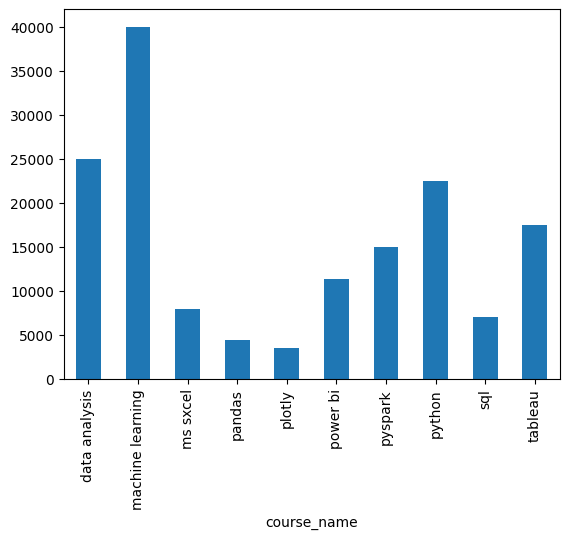

In [191]:
regs.merge(courses, on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

### Q-5: Students Who Enrolled in Both Months

In [192]:
# Find common student_ids in both months
common_student_id = np.intersect1d(nov['student_id'], dec['student_id'])
print('Students in both months:', common_student_id)

students[students['student_id'].isin(common_student_id)]

Students in both months: [ 1  3  7 11 16 17 18 22 23]


,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


### Q-6: Courses with No Enrollment

In [193]:
course_id_list = np.setdiff1d(courses['course_id'], regs['course_id'])
print('Unenrolled course IDs:', course_id_list)

courses[courses['course_id'].isin(course_id_list)]

Unenrolled course IDs: [11 12]


,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


### Q-7: Students Who Did Not Enroll in Any Course

In [194]:
student_id_list = np.setdiff1d(students['student_id'], regs['student_id'])
print('Students not enrolled:', students[students['student_id'].isin(student_id_list)].shape[0])
students[students['student_id'].isin(student_id_list)]

Students not enrolled: 13


,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11
25,26,Nitish,28
26,27,Ankit,26
27,28,Rahul,17


### Q-8: Student Name to Partner Name (Self Join)

In [195]:
# Self join: match student's partner_id to another student's student_id
students.merge(students, how='inner', left_on='partner', right_on='student_id')[['name_x', 'name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


**Key Concept:** A self join merges a table with itself. Here we match each student's `partner` to another student's `student_id`.

### Q-9: Top 3 Students by Number of Enrollments

In [196]:
regs.merge(students, on='student_id').groupby(['student_id', 'name'])['name'].count().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      6
7           Tarun Thaker        5
14          Pranab Natarajan    4
Name: name, dtype: int64

### Q-10: Top 3 Students by Money Spent

In [197]:
regs.merge(students, on='student_id').merge(courses, on='course_id').groupby(['student_id', 'name'])['price'].sum().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64


## Alternate Syntax: `pd.merge()`

You can also use `pd.merge()` as a function instead of the method.

In [198]:
pd.merge(students, regs, how='inner', on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7



## IPL Merge Exercises

Using merge to combine match and delivery data.

In [199]:
matches

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [200]:
delivery

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN


### Q-1: Top 3 Stadiums with Highest Sixes/Match Ratio

In [201]:
# Merge delivery with matches to get venue info
temp_df = delivery.merge(matches, left_on='match_id', right_on='id')

In [202]:
# Count sixes per stadium
six_df = temp_df[temp_df['batsman_runs'] == 6]
num_sixes = six_df.groupby('venue')['venue'].count()

In [203]:
# Count matches per stadium
num_matches = matches['venue'].value_counts()

In [204]:
# Calculate ratio
(num_sixes / num_matches).sort_values(ascending=False).head(10)

venue
Holkar Cricket Stadium                                 17.600000
M Chinnaswamy Stadium                                  13.227273
Sharjah Cricket Stadium                                12.666667
Himachal Pradesh Cricket Association Stadium           12.000000
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium    11.727273
Wankhede Stadium                                       11.526316
De Beers Diamond Oval                                  11.333333
Maharashtra Cricket Association Stadium                11.266667
JSCA International Stadium Complex                     10.857143
Sardar Patel Stadium, Motera                           10.833333
dtype: float64

**Key Concept:** When merging, you can use different column names with `left_on` and `right_on`.

### Q-2: Orange Cap Holder of All Seasons

The Orange Cap is awarded to the highest run-scorer of each IPL season.

In [205]:
matches

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [206]:
# Group by season and batsman, sum runs
temp_df.groupby(['season', 'batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs', ascending=False).drop_duplicates(subset=['season'], keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641


In [207]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False)

,season,batsman,batsman_runs
1383,2016,V Kohli,973
1278,2016,DA Warner,848
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
852,2013,CH Gayle,720
...,...,...,...
638,2011,VR Aaron,0
1467,2017,MM Patel,0
572,2011,ND Doshi,0
605,2011,S Nadeem,0


**Key Concept:** `drop_duplicates(subset=['season'], keep='first')` keeps only the top scorer from each season after sorting by runs (descending).


## Summary - Merge vs Concat

| Operation | Use Case | Method |
|-----------|----------|--------|
| **Concat** | Stack DataFrames with same columns | `pd.concat([df1, df2])` |
| **Concat** | Add rows from one DataFrame to another | `pd.concat([df1, df2])` |
| **Concat** | Side-by-side comparison | `pd.concat([df1, df2], axis=1)` |
| **Merge** | Combine based on common column | `df1.merge(df2, on='key')` |
| **Merge** | SQL-style joins | `df1.merge(df2, how='inner/left/right/outer')` |
| **Merge** | Different column names | `df1.merge(df2, left_on='a', right_on='b')` |


## Merge Types Summary

```
Inner Join:  Only matching rows from both
Left Join:   All from left + matching from right
Right Join:  All from right + matching from left
Outer Join:  All rows from both (NaN for missing)
```
```python
df1.merge(df2, how='inner', on='key')  # Inner
df1.merge(df2, how='left', on='key')   # Left
df1.merge(df2, how='right', on='key')  # Right
df1.merge(df2, how='outer', on='key')  # Outer
```


## Key Takeaways

1. **GroupBy = Split + Apply + Combine** - the core pattern for data aggregation
2. **`agg()`** lets you apply different functions to different columns
3. **`apply()`** is the most flexible - use any custom function on groups
4. **`pd.concat()`** stacks DataFrames vertically (default) or horizontally (axis=1)
5. **`merge()`** combines DataFrames based on common columns (like SQL JOIN)
6. **`ignore_index=True`** in concat resets the index
7. **`how` parameter** in merge controls the type: inner, left, right, outer
8. **Self join** merges a table with itself using different column references
9. **Multi-column groupby**: `df.groupby(['col1', 'col2'])` for granular groups
10. **IPL pattern**: Filter first, then groupby, then aggregate

# Practice Problems - GroupBy & Merging



Work through these problems to master GroupBy and Merge operations.

### Problem Sets Overview

| Set | Topic | Concepts |
|-----|-------|----------|
| 1 | Titanic Dataset | groupby, fillna with mode, nested groupby |
| 2 | FIFA World Cup 2022 | apply with Z-normalization |
| 3 | IPL Dataset | Chasing stats, batting pairs, purple cap |
| 4 | Chipotle Dataset | concat, merge, revenue analysis |
| 5 | Iris Dataset | merge multiple DataFrames, groupby |


#  Titanic Dataset

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Datasets : https://docs.google.com/spreadsheets/d/e/2PACX-1vQjh5HzZ1N0SU7ME9ZQRzeVTaXaGsV97rU8R7eAcg53k27GTstJp9cRUOfr55go1GRRvTz1NwvyOnuh/pub?gid=1562145139&single=true&output=csv
```


These problems practice GroupBy operations on the Titanic dataset.

In [1]:
import pandas as pd
import numpy as np

In [6]:
titanic_df = pd.read_csv('Datasets/Titanic.csv')
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Q-1: GroupBy Pclass - Average Age and Missing Values

Using `groupby`, make groups using the `Pclass` column and find:
1. Average age for each group
2. Total number of missing values in `Age` column for each group

In [7]:
# code here
pclass_groups = titanic_df.groupby("Pclass")
for group in list(pclass_groups.groups.keys()):
    print(f"Pclass {group} : Avg Age {pclass_groups.get_group(group)['Age'].mean()} and total missing value {pclass_groups.get_group(group)['Age'].isna().sum()}")

Pclass 1 : Avg Age 38.233440860215055 and total missing value 30
Pclass 2 : Avg Age 29.87763005780347 and total missing value 11
Pclass 3 : Avg Age 25.14061971830986 and total missing value 136


**Key Concept:** `groupby.get_group(name)` returns the DataFrame for a specific group. Use `isna().sum()` to count missing values.

### Q-2: Fill Missing Embarked Values with Group Mode

Using `groupby`, make groups using `Pclass` and fill every group's `Embarked` column missing values with the mode value of that group. Then print value counts.

In [8]:
# code here - Done in session
for group in list(pclass_groups.groups.keys()):
    mode = pclass_groups.get_group(group)["Embarked"].mode()
    pclass_groups.get_group(group)["Embarked"].fillna(mode)
    print(pclass_groups.get_group(group)["Embarked"].value_counts(ascending = True))

Embarked
Q      2
C     85
S    127
Name: count, dtype: int64
Embarked
Q      3
C     17
S    164
Name: count, dtype: int64
Embarked
C     66
Q     72
S    353
Name: count, dtype: int64


**Key Concept:** `transform()` applies a function to each group and broadcasts the result back to the original DataFrame shape. This is much cleaner than manual iteration.

**Why the first approach failed:** Direct `fillna()` on a group doesn't modify the original DataFrame because it returns a copy. Use `transform()` or `loc[]` for permanent changes.

### Q-3: Nested GroupBy - Average Fare by Embarked and Pclass

Make groups based on `Embarked`. For each embarked group, make another group based on `Pclass` and find the average fare (rounded to 2 decimal places).

**Expected Output:**
```python
{'C': {1: 105, 2: 25, 3: 11},
 'Q': {1: 90, 2: 12, 3: 11},
 'S': {1: 70, 2: 20, 3: 15}}
```

In [9]:
# Updated Code : Approach 1
titanic_df1 = titanic_df.copy(True)

# Step 1: Group by 'Pclass' and fill missing values in 'Embarked' with the mode value of that group
titanic_df1['Embarked'] = titanic_df1.groupby('Pclass')['Embarked'].transform(lambda x: x.fillna(x.mode()[0]))

# Step 2: Print the value counts of 'Embarked' for each group in ascending order
grouped = titanic_df1.groupby('Pclass')[['Embarked']]
grouped.value_counts().sort_index(ascending=True)

Pclass  Embarked
1       C            85
        Q             2
        S           129
2       C            17
        Q             3
        S           164
3       C            66
        Q            72
        S           353
Name: count, dtype: int64

In [11]:
# Alternative: Using pivot_table
titanic_df.pivot_table(values='Fare', index='Embarked', columns='Pclass', aggfunc='mean').round(2)

Embarked
S    129
C     85
Q      2
Name: count, dtype: int64
Embarked
S    164
C     17
Q      3
Name: count, dtype: int64
Embarked
S    353
Q     72
C     66
Name: count, dtype: int64


In [12]:
# Updated Code : Approach 2

titanic_df2 = titanic_df.copy(True)
pclass_groups=titanic_df2.groupby('Pclass')
for group in list(pclass_groups.groups.keys()):
    mode_val=pclass_groups.get_group(group)['Embarked'].mode()
    titanic_df2.loc[pclass_groups.get_group(group).index, 'Embarked'] = pclass_groups.get_group(group)['Embarked'].fillna(mode_val[0])
    print(pclass_groups.get_group(group)['Embarked'].value_counts())

Embarked
S    129
C     85
Q      2
Name: count, dtype: int64
Embarked
S    164
C     17
Q      3
Name: count, dtype: int64
Embarked
S    353
Q     72
C     66
Name: count, dtype: int64


**Key Concept:** Nested groupby means grouping by one column, then within each group, grouping by another column. The `pivot_table()` method achieves the same result more elegantly.


#  FIFA World Cup 2022

### **Questions Based on Fifa Worldcup - 2022 Dataset:**

You can read the dataset by using the below sample code

Dataset : https://docs.google.com/spreadsheets/d/e/2PACX-1vT3D_x_4DS6d51LKJ7ze1sxT5WpV5uiSVOFYHLwBiGru6vFyVv5h5-83AwFjxWYiWfCDjDAaarHAV-k/pub?gid=0&single=true&output=csv

In [14]:
fifa_df = pd.read_csv('Datasets/Fifa Worldcup 2022.csv')
fifa_df

,Sl. No,Match No.,Team,Against,Group,Goal,Possession (%),Inside Penalty Area,Outside Penalty Area,Assists,...,Fouls Against,Offsides,Passes,Passes Completed,Crosses,Crosses Completed,Corners,Free Kicks,Penalties Scored,Pts
0,1,1,Qatar,Ecuador,A,0,40,0,0,0,...,15,3,453,387,10,5,1,19,0,0
1,2,1,Ecuador,Qatar,A,2,46,2,0,1,...,15,4,484,419,26,10,3,17,1,3
2,3,2,England,Iran,B,6,69,6,0,6,...,9,2,810,733,29,9,8,16,0,3
3,4,2,Iran,England,B,2,20,2,0,1,...,14,2,232,156,11,3,0,10,1,0
4,5,3,Senegal,Netherlands,A,0,39,0,0,0,...,13,2,391,326,22,8,6,14,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,124,62,Morocco,Fram,F,0,55,0,0,0,...,11,3,583,518,22,1,3,15,0,0
124,125,63,Croatia,Morocco,F,2,45,2,0,2,...,13,2,491,430,21,3,6,13,0,3
125,126,63,Morocco,Croatia,F,1,45,1,0,0,...,11,2,494,428,20,5,3,15,0,0
126,127,64,Argentina,France,C,3,46,3,0,1,...,26,4,648,544,20,4,6,22,5,3


### Q-4: Z-Normalization on Team Stats

Perform `groupby` on `Team` column and apply Z-Normalization on:
1. Passes
2. Passes Completed
3. Attempted Line Breaks
4. Completed Line Breaks

**Formula:** Z = (Xi - mean) / std

Then find min/max of various columns per team.

In [15]:
def z_normalization(group, cols_to_perform):
    for col in cols_to_perform:
        std = group[col].std()
        mean = group[col].mean()
        group[f'{col}_z_norm'] = (group[col] - mean) / std
    return group

cols_to_perform = ['Passes', 'Passes Completed', 'Attempted Line Breaks', 'Completed Line Breaks']
groups = fifa_df.groupby('Team')
groups = groups.apply(z_normalization, cols_to_perform=cols_to_perform).groupby('Team')

groups.agg({
    'Passes': ['min', 'max'],
    'Yellow Cards': ['min', 'max', 'mean'],
    'Attempted Line Breaks': ['max', 'min', 'std'],
    'Possession (%)': 'mean'
})

Passes       Yellow Cards               Attempted Line Breaks  \
                  min   max          min max      mean                   max   
Team                                                                           
Argentina         408   862            0   8  2.285714                   249   
Australia         286   466            0   3  1.750000                   171   
Belgium           512   685            1   3  1.666667                   195   
Brazil            548   695            0   3  1.200000                   193   
Cameroon          295   500            1   5  2.666667                   182   
Canada            448   536            2   4  2.666667                   176   
Costa Rica        231   454            1   3  2.000000                   154   
Croatia           461   724            0   2  1.142857                   259   
Denmark           537   650            1   2  1.666667                   241   
Ecuador           429   484            0   2  1.000000                   177   
England           508   810            0   1  0.200000                   208   
France            358   734            0   3  1.142857                   179   
Germany           352   827            0   3  1.000000                   256   
Ghana             319   460            2   4  2.666667                   188   
Iran              232   463            2   3  2.333333                   195   
Japan             225   591            0   3  1.500000                   253   
Korea Republic    359   548            1   2  1.500000                   201   
Mexico            356   500            1   4  2.333333                   198   
Morocco           229   583            0   3  1.285714                   157   
Netherlands       403   786            0   4  1.800000                   198   
Poland            303   466            1   3  1.750000                   156   
Portugal          461   678            0   3  1.200000                   197   
Qatar             424   457            0   4  2.333333                   174   
Saudi Arabia      267   560            2   6  4.666667                   205   
Senegal           277   511            1   3  1.750000                   184   
Serbia            403   513            2   7  4.000000                   184   
Spain             647  1070            0   1  0.500000                   237   
Switzerland       403   512            1   4  2.250000                   178   
Tunisia           328   501            1   3  1.666667                   200   
United States     427   572            0   4  1.250000                   204   
Uruguay           390   528            1   3  2.000000                   186   
Wales             325   508            1   2  1.666667                   208   

                               Possession (%)  
                min        std           mean  
Team                                           
Argentina       141  38.774685      49.285714  
Australia       133  17.682383      31.250000  
Belgium         167  14.422205      49.000000  
Brazil          164  10.691118      50.400000  
Cameroon        144  19.857828      38.333333  
Canada          102  37.753587      44.333333  
Costa Rica       86  38.974351      27.333333  
Croatia          97  54.499891      47.428571  
Denmark         173  34.000000      51.333333  
Ecuador         143  17.009801      42.666667  
England         133  29.676590      57.200000  
France          126  21.407609      44.857143  
Germany         143  56.624494      53.000000  
Ghana           122  33.020196      37.000000  
Iran             56  77.526340      31.666667  
Japan           104  64.048810      30.250000  
Korea Republic  139  27.072434      42.250000  
Mexico          127  40.706265      46.666667  
Morocco         128  10.641339      34.285714  
Netherlands     168  12.759310      44.000000  
Poland           79  36.326070      32.000000  
Portugal        165  13.049904      53.800000  
Qatar         

**Key Concept:** `apply()` passes each group to the function. The function modifies the group (adds new columns) and returns it. Then we groupby again to aggregate.


#  IPL Dataset

Advanced GroupBy and Merge problems using ball-by-ball IPL data.

ball by ball dataset - https://drive.google.com/file/d/1-kvv_9KCSAFWcrhS9WgTxSrURkRh6GNt/view?usp=share_link



In [18]:
balls = pd.read_csv('Datasets/ipl_deliveries.csv')
balls.head()

,ID,Team,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,BowlingTeam
0,1312200,Rajasthan RoyalsGujarat Titans,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
1,1312200,Rajasthan RoyalsGujarat Titans,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
2,1312200,Rajasthan RoyalsGujarat Titans,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
3,1312200,Rajasthan RoyalsGujarat Titans,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
4,1312200,Rajasthan RoyalsGujarat Titans,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans


In [17]:
balls.shape

(225954, 19)

### Q-5: Batsman in Chasing - Highest Score & Best Strike Rate

Find batsman with:
1. Highest score while chasing (batting in 2nd innings)
2. Best strike rate while chasing (faced 100+ balls)

In [19]:
# code here
#1
df = balls[balls.innings == 2]
df.groupby(["ID", "batter"]).sum().sort_values(by = "batsman_run", ascending = False)["batsman_run"].head()

ID       batter       
501206   PC Valthaty      120
501243   V Sehwag         119
1254061  SV Samson        119
1136620  SR Watson        117
336018   ST Jayasuriya    114
Name: batsman_run, dtype: int64

In [20]:
#2
temp_df = df[~(df.extra_type == "wides")]
temp_df = temp_df.groupby("batter").agg(
{
    "batsman_run": "sum",
    "ballnumber": "count"
})
temp_df["strike_rate"] = temp_df["batsman_run"] / temp_df["ballnumber"] * 100
temp_df[temp_df["ballnumber"] >= 100].sort_values("strike_rate", ascending = False).reset_index().head()


,batter,batsman_run,ballnumber,strike_rate
0,PJ Cummins,222,114,194.736842
1,AD Russell,986,570,172.982456
2,LS Livingstone,182,107,170.093458
3,SP Narine,599,356,168.258427
4,SO Hetmyer,330,200,165.000000


**Key Concept:** Wides are not counted as balls faced by the batsman. Use `extra_type` to filter them out.

### Q-6: Most Successful Bowler-Batsman Pair

Find the bowler-batsman pair where the bowler has dismissed the batsman the most times. If tied, the bowler with fewer runs conceded is more successful.

In [21]:
# code here

balls["IsBatterOut"] = (balls.batter == balls.player_out)&(~balls.kind.isin(['run out', 'retired hurt', 'retired out']))
balls.groupby(["bowler", "batter"]).agg({
    "IsBatterOut": "sum",
    "batsman_run": "sum"
}).sort_values(by=["IsBatterOut", "batsman_run"], ascending = [False, True]).head(10)

,,IsBatterOut,batsman_run
bowler,batter,,
Z Khan,MS Dhoni,7,74
Sandeep Sharma,V Kohli,7,78
A Mishra,RG Sharma,7,87
R Ashwin,RV Uthappa,7,123
SP Narine,RG Sharma,7,137
R Vinay Kumar,RG Sharma,6,22
YS Chahal,Q de Kock,6,44
JJ Bumrah,RR Pant,6,48
RA Jadeja,GJ Maxwell,6,49


**Key Concept:** Create a boolean column `IsBatterOut` to track dismissals. Sort by dismissals (desc) then runs conceded (asc) to break ties.

### Q-7: Most Successful Batting Pair

Find the batting pair (batter + non-striker) who have scored the most runs playing together.

In [22]:
# code here
def func(x):
    return '-'.join(list(np.sort(x.values)))
    
balls["batter-pair"] = balls[["batter", "non-striker"]].apply(func, axis = 1)
balls.groupby("batter-pair")["total_run"].sum().sort_values(ascending = False).head()

batter-pair
AB de Villiers-V Kohli    3134
CH Gayle-V Kohli          2802
DA Warner-S Dhawan        2357
G Gambhir-RV Uthappa      1906
KL Rahul-MA Agarwal       1731
Name: total_run, dtype: int64

**Key Concept:** `np.sort()` ensures pairs like (Kohli, Dhoni) and (Dhoni, Kohli) are treated as the same pair.

### Q-8: Batting Pair Statistics DataFrame

Create a DataFrame with columns: `Batsman1`, `Batsman2`, `Runs`, `Avg`, `StrikeRate`

In [23]:
# code here
temp_df = balls.groupby("batter-pair").agg(
{
    "total_run": "sum",
    "ballnumber": "count",
    "isWicketDelivery": "sum"
}).reset_index()
temp_df["Batsman 1"] = temp_df["batter-pair"].apply(lambda x: x.split("-")[0])
temp_df["Batsman 2"] = temp_df["batter-pair"].apply(lambda x: x.split("-")[1])
temp_df.rename(columns = {"total_run": "Runs"}, inplace=True)
temp_df["StrikeRate"] = temp_df["Runs"] / temp_df["ballnumber"] * 100
temp_df["Avg"] = temp_df["Runs"] / temp_df["isWicketDelivery"]
temp_df.sort_values("Runs", ascending = False, inplace=  True)
temp_df[["Batsman 1", "Batsman 2", "Runs", "Avg", "StrikeRate"]]

,Batsman 1,Batsman 2,Runs,Avg,StrikeRate
302,AB de Villiers,V Kohli,3134,44.140845,152.209811
1251,CH Gayle,V Kohli,2802,52.867925,142.017233
1508,DA Warner,S Dhawan,2357,48.102041,136.637681
1954,G Gambhir,RV Uthappa,1906,39.708333,133.754386
2803,KL Rahul,MA Agarwal,1731,52.454545,142.939719
...,...,...,...,...,...
34,A Choudhary,S Badree,0,0.000000,0.000000
4215,T Stubbs,Tilak Varma,0,0.000000,0.000000
64,A Mishra,CL White,0,0.000000,0.000000
3114,M Muralitharan,MS Gony,0,0.000000,0.000000



# Chipotle Quarterly Data

Practice concat, merge, and groupby with quarterly sales data.

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load datasets
items = pd.read_csv("Datasets/items.csv")
q1 = pd.read_csv('Datasets/quarter-1.csv')
q2 = pd.read_csv('Datasets/quarter-2.csv')
q3 = pd.read_csv('Datasets/quarter-3.csv')
items.head()

,item_name,item_price
0,Chips and Fresh Tomato Salsa,$2.39
1,Izze,$3.39
2,Nantucket Nectar,$3.39
3,Chips and Tomatillo-Green Chili Salsa,$2.39
4,Chicken Bowl,$16.98


In [3]:
q1.head()

,order_id,quantity,item_id,choice_description_id,item_price
0,1,1,1,1,$3.39
1,1,1,2,2,$3.39
2,2,2,4,3,$16.98
3,4,1,7,6,$9.25
4,6,1,9,8,$8.75


In [4]:
q2.head()

,order_id,quantity,item_id,choice_description_id,item_price
0,1,1,0,0,$2.39
1,1,1,3,0,$2.39
2,3,1,4,4,$10.98
3,3,1,5,0,$1.69
4,4,1,6,5,$11.75


In [5]:
q3.head()

,order_id,quantity,item_id,choice_description_id,item_price


In [6]:
print(items.shape)
print(q1.shape)
print(q2.shape)
print(q3.shape)

(4622, 2)
(2275, 5)
(2347, 5)
(0, 5)


### Q-1 & Q-2: Concat Quarters with MultiIndex

Append three quarter files into a single DataFrame with index labels Q1, Q2, Q3.

In [7]:
# code here
#1+2
df1 = pd.concat([q1, q2, q3], keys=["Q1", "Q2", "Q3"]).reset_index()
df1

,level_0,level_1,order_id,quantity,item_id,choice_description_id,item_price
0,Q1,0,1,1,1,1,$3.39
1,Q1,1,1,1,2,2,$3.39
2,Q1,2,2,2,4,3,$16.98
3,Q1,3,4,1,7,6,$9.25
4,Q1,4,6,1,9,8,$8.75
...,...,...,...,...,...,...,...
4617,Q2,2342,1829,1,23,92,$11.25
4618,Q2,2343,1830,1,23,1043,$11.25
4619,Q2,2344,1832,1,10,116,$8.75
4620,Q2,2345,1832,1,8,0,$4.45


**Key Concept:** `keys` parameter creates a MultiIndex where the first level is the quarter label.

### Q-3: Most Sold Items in Each Quarter

Find the item with highest total quantity sold in each quarter.

In [8]:
df1.columns

Index(['level_0', 'level_1', 'order_id', 'quantity', 'item_id',
       'choice_description_id', 'item_price'],
      dtype='str')

In [9]:
items.columns

Index(['item_name', 'item_price'], dtype='str')

In [10]:
# 3
df1.rename(columns={"level_0": "quarter"}, inplace=True)
most_sold = (
    df1.groupby(["quarter", "item_id"], as_index=False)["quantity"]
       .sum()
       .sort_values(["quarter", "quantity"], ascending=[True, False])
       .drop_duplicates(subset="quarter", keep="first")
)
most_sold

,quarter,item_id,quantity
4,Q1,4,367
53,Q2,4,394


### Q-4: Most Revenue Items in Each Quarter

Note: `item_price` is a string with $ sign. Convert to float first.

In [13]:
# Convert item_price to float
df1["item_price"] = df1["item_price"].apply(lambda x: float(x[1:]))  # remove $
df1["total_item_price"] = df1["item_price"] * df1["quantity"]

most_revenue = (
    df1.groupby(["quarter", "item_id"], as_index=False)["total_item_price"]
       .sum()
       .sort_values(["quarter", "total_item_price"], ascending=[True, False])
       .drop_duplicates("quarter", keep="first")
)
most_revenue

,quarter,item_id,total_item_price
4,Q1,4,3852.38
53,Q2,4,4192.25


### Q-5: Average Order Price per Quarter

In [14]:
df1.groupby(['quarter', 'order_id'], as_index=False)['total_item_price'].sum() \
    .groupby('quarter', as_index=False)['total_item_price'].mean()

,quarter,total_item_price
0,Q1,13.809488
1,Q2,13.279828


**Key Concept:** Two-step groupby: first aggregate by order (sum), then aggregate by quarter (mean).

### Q-6: Purple Cap Holder Each Season

The Purple Cap is awarded to the bowler with the most wickets in a season. If tied, the bowler with the least economy wins.

**Economy** = runs conceded per 6 balls

In [16]:
balls = pd.read_csv("Datasets/IPL_Ball_by_Ball_2008_2022.csv")
matches = pd.read_csv("Datasets/IPL_Matches_2008_2022.csv")

In [17]:
matches.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [18]:
balls.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [19]:
# code here
seasondf = balls.merge(matches[["ID", "Season"]], on="ID")
seasondf["IsBowlerWicket"] = seasondf.kind.apply(lambda x: 1 if x in ["caught", 'caught and bowled', 'bowled', 'stumped','lbw', 'hit wicket'] else 0)
seasondf["BowlerRun"] = seasondf.extra_type.apply(lambda x: 0 if x in ["legbyes", "byes"] else 1) * seasondf["total_run"]
seasondf["IsLegalBall"] = seasondf.extra_type.apply(lambda x: 0 if x in ["wides", "noballs"] else 1)
pcapdf = seasondf.groupby(["Season", "bowler"], as_index = False)[["IsBowlerWicket", "BowlerRun", "IsLegalBall"]].sum()
pcapdf["Economy"] = pcapdf["BowlerRun"] / pcapdf["IsLegalBall"] * 6
pcapdf.sort_values(["IsBowlerWicket", "Economy"], ascending = [False, True]).drop_duplicates("Season", keep = "first").sort_values("Season")

,Season,bowler,IsBowlerWicket,BowlerRun,IsLegalBall,Economy
84,2007/08,Sohail Tanvir,22,266,247,6.461538
174,2009,RP Singh,23,417,358,6.988827
284,2009/10,PP Ojha,21,429,353,7.291785
447,2011,SL Malinga,28,375,378,5.952381
537,2012,M Morkel,25,453,378,7.190476
629,2013,DJ Bravo,32,497,375,7.952000
779,2014,MM Sharma,23,452,323,8.396285
847,2015,DJ Bravo,26,426,314,8.140127
938,2016,B Kumar,23,490,396,7.424242
1048,2017,B Kumar,26,369,314,7.050955


**Key Concept:**
- Legal deliveries exclude wides and noballs
- Bowler runs exclude legbyes and byes
- Dismissal types for bowler wickets: caught, bowled, lbw, stumped, caught and bowled, hit wicket

### Q-7: Best Bowler in Death Overs (Overs 16-20)

Most wickets in death overs, with least economy as tiebreaker.

In [20]:
# code here
death_overs = seasondf[seasondf.overs>=15]
pcapdf = death_overs.groupby("bowler", as_index = False)[["IsBowlerWicket", "BowlerRun", "IsLegalBall"]].sum()
pcapdf["Economy"] = pcapdf["BowlerRun"] / pcapdf["IsLegalBall"] * 6
pcapdf.sort_values(["IsBowlerWicket", "Economy"], ascending = [False, True]).head()

,bowler,IsBowlerWicket,BowlerRun,IsLegalBall,Economy
91,DJ Bravo,115,2161,1385,9.361733
331,SL Malinga,108,1464,1117,7.863921
53,B Kumar,90,1752,1173,8.961637
148,JJ Bumrah,80,1614,1146,8.450262
339,SP Narine,67,1164,949,7.359326


### Q-8: Batsman Record Season-wise

Create a function that takes a batsman name and returns a DataFrame with columns:
`Season`, `Innings`, `TotalRuns`, `Avg`, `HighestScore`, `StrikeRate`

**Rules:**
- Avg = total_runs / times got out
- StrikeRate = (total_runs / balls_faced) * 100
- Wides are not counted as balls faced
- Batsman can get out on No Ball or Wides

In [21]:
# code here
batterdf = seasondf.copy()
batterdf["IsBatsmanBall"] = batterdf["extra_type"].apply(lambda x: 1 if x != "wides" else 0)

def bat_record_season(batsman):
    bdf = batterdf[batterdf.batter == batsman].copy()
    bdf["IsBatsmanOut"] = bdf.batter == bdf.player_out
    df = bdf.groupby(["Season", "ID"], as_index = False)[["batsman_run", "IsBatsmanBall", "IsBatsmanOut"]].sum()
    innings = df.groupby("Season").ID.count()
    df = df.groupby("Season").agg(
    {
        "batsman_run":["sum", "max"],
        "IsBatsmanBall": "sum",
        "IsBatsmanOut": "sum"
    })
    df["Innings"]= innings
    df["TotalRuns"] = df[("batsman_run", "sum")]
    df["Avg"] = df["TotalRuns"] / df[("IsBatsmanOut", "sum")]
    df["HighestScore"] = df[("batsman_run", "max")]
    df["StrikeRate"] = df["TotalRuns"] / df[("IsBatsmanBall", "sum")] * 100
    return df.drop(columns = ["batsman_run", "IsBatsmanBall", "IsBatsmanOut"])
bat_record_season("MS Dhoni")

,Innings,TotalRuns,Avg,HighestScore,StrikeRate
,,,,,
Season,,,,,
2007/08,14,414,41.400000,65,133.548387
2009,13,332,41.500000,58,127.203065
2009/10,11,287,31.888889,66,136.666667
2011,13,392,43.555556,70,158.704453
2012,17,358,32.545455,51,128.776978
2013,16,461,46.100000,67,162.897527
2014,15,371,74.200000,57,148.400000
2015,17,372,31.000000,53,121.967213


### Q-9: Player of Match - Batting and Bowling Figures

For each match, create a record with:
- `PlayerOfThematch`
- `BattingFigure`: runs/balls (e.g., 112/76)
- `BowlingFigure`: wickets/runs-conceded (e.g., 2/35)

In [22]:
# code here
df = balls.merge(matches[["ID", "Player_of_Match"]], on="ID")
batterdf = df[df.batter == df.Player_of_Match].copy()
batterdf["IsBatsmanBall"] = batterdf["extra_type"].apply(lambda x: 1 if x != "wides" else 0)
batter = batterdf.groupby(["ID", "batter"], as_index=False)[["batsman_run", "IsBatsmanBall"]].sum()
batter["BattingFigure"] = batter[["batsman_run", "IsBatsmanBall"]].apply(lambda x: '/'.join(map(str, x.values)), axis = 1)
batter.rename(columns = {"batter": "PlayerOfMatch"}, inplace = True)
batter.head()

,ID,PlayerOfMatch,batsman_run,IsBatsmanBall,BattingFigure
0,335982,BB McCullum,158,73,158/73
1,335983,MEK Hussey,116,54,116/54
2,335985,MV Boucher,39,19,39/19
3,335986,DJ Hussey,38,43,38/43
4,335987,SR Watson,76,49,76/49


In [23]:
bowlerdf = df[df.bowler == df.Player_of_Match].copy()
bowlerdf["IsBowlerWicket"] = bowlerdf["kind"].apply(lambda x: 1 if x in ["caught", 'caught and bowled', 'bowled', 'stumped','lbw', 'hit wicket'] else 0)
bowlerdf["BowlerRun"] = bowlerdf.extra_type.apply(lambda x: 0 if x in ["legbyes", "byes"] else 1) * bowlerdf["total_run"]
bowler = bowlerdf.groupby(["ID", "bowler"], as_index=False)[["IsBowlerWicket", "BowlerRun"]].sum()
bowler["BowlingFigure"] = bowler[["IsBowlerWicket", "BowlerRun"]].apply(lambda x: '/'.join(map(str, x.values)), axis = 1)
bowler.rename(columns = {"bowler": "PlayerOfMatch"}, inplace = True)
bowler.head()

,ID,PlayerOfMatch,IsBowlerWicket,BowlerRun,BowlingFigure
0,335984,MF Maharoof,2,11,2/11
1,335986,DJ Hussey,1,35,1/35
2,335987,SR Watson,0,39,0/39
3,335990,YK Pathan,2,20,2/20
4,335992,SR Watson,2,20,2/20


In [24]:
batter.merge(bowler, on=["ID", "PlayerOfMatch"], how = "outer").drop(columns = ["batsman_run", "IsBatsmanBall", "IsBowlerWicket", "BowlerRun"]).head()

,ID,PlayerOfMatch,BattingFigure,BowlingFigure
0,335982,BB McCullum,158/73,NaN
1,335983,MEK Hussey,116/54,NaN
2,335984,MF Maharoof,NaN,2/11
3,335985,MV Boucher,39/19,NaN
4,335986,DJ Hussey,38/43,1/35



#  Iris Dataset

Practice merging multiple DataFrames and groupby operations.

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [25]:
import pandas as pd
import numpy as np

In [26]:
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")
virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")

In [27]:
sepal_all.shape

(150, 4)

In [28]:
petal_all.shape

(150, 4)

In [29]:
virginica.shape

(50, 3)

In [30]:
virginica.head()

,Unnamed: 0,Id,Species
0,100,101,Iris-virginica
1,101,102,Iris-virginica
2,102,103,Iris-virginica
3,103,104,Iris-virginica
4,104,105,Iris-virginica


### Q-9: Average Sepal Length of Virginica vs Average Petal Length of Setosa

Plot a bar chart comparing:
- Average Sepal Length of Virginica
- Average Petal Length of Setosa

<Axes: xlabel='kind'>

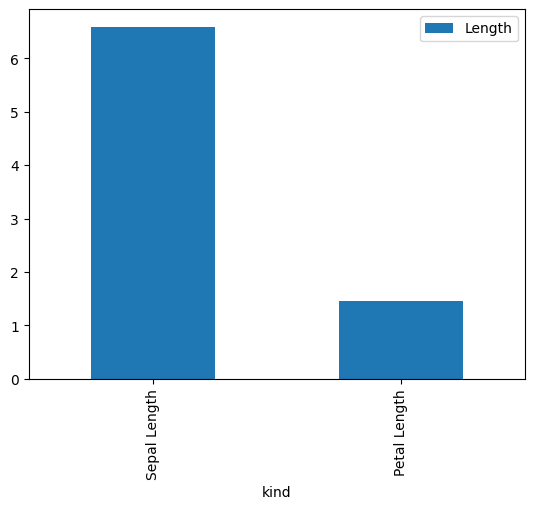

In [31]:
# code here
sepal = pd.merge(virginica, sepal_all, on="Id")["SepalLengthCm"].mean()
petal = pd.merge(setosa, petal_all, on="Id")["PetalLengthCm"].mean()
pd.DataFrame({"kind": ["Sepal Length", "Petal Length"], "Length": [sepal, petal]}).plot(x="kind", kind = "bar")

**Key Concept:** Merge species data with measurement data on `Id` column, then compute mean.

### Q-10: Create Complete Iris Dataset

Merge all datasets to create a complete dataset with columns:
`Id`, `Species`, `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`

Shuffle the rows so Id is not in order.

In [32]:
# code here
v_sepal = pd.merge(virginica, sepal_all, on="Id").drop(columns= ["Unnamed: 0_x", "Unnamed: 0_y"])
v = pd.merge(v_sepal, petal_all, on="Id").drop(columns= ["Unnamed: 0"])

s_sepal = pd.merge(setosa, sepal_all, on="Id").drop(columns= ["Unnamed: 0_x", "Unnamed: 0_y"])
s = pd.merge(s_sepal, petal_all, on="Id").drop(columns= ["Unnamed: 0"])

ver_sepal = pd.merge(versicolor, sepal_all, on="Id").drop(columns= ["Unnamed: 0_x", "Unnamed: 0_y"])
ver = pd.merge(ver_sepal, petal_all, on="Id").drop(columns= ["Unnamed: 0"])

pd.concat([v, s, ver]).sample(150)

,Id,Species,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
48,149,Iris-virginica,6.2,3.4,5.4,2.3
24,25,Iris-setosa,4.8,3.4,1.9,0.2
11,12,Iris-setosa,4.8,3.4,1.6,0.2
34,85,Iris-versicolor,5.4,3.0,4.5,1.5
26,77,Iris-versicolor,6.8,2.8,4.8,1.4
...,...,...,...,...,...,...
5,6,Iris-setosa,5.4,3.9,1.7,0.4
44,95,Iris-versicolor,5.6,2.7,4.2,1.3
32,133,Iris-virginica,6.4,2.8,5.6,2.2
49,100,Iris-versicolor,5.7,2.8,4.1,1.3


**Key Concept:** Each species file only has `Id` and `Species`. We need to merge with `sepal_all` and `petal_all` to get the measurements.

### Q-11: Min/Max Sepal and Petal Width for Setosa and Versicolor

Find the maximum and minimum sepal width and petal width of Setosa and Versicolor.

In [33]:
# code here
print(f"Minimum Sepal width of Setosa is {s.SepalWidthCm.min()}")
print(f"Maximum Sepal width of Setosa is {s.SepalWidthCm.max()}")
print(f"Minimum Petal width of Setosa is {s.PetalWidthCm.min()}")
print(f"Maximum Petal width of Setosa is {s.PetalWidthCm.max()}")
print(f"Minimum Sepal width of Versicolor is {ver.SepalWidthCm.min()}")
print(f"Maximum Sepal width of Versicolor is {ver.SepalWidthCm.max()}")
print(f"Minimum Petal width of Versicolor is {ver.PetalWidthCm.min()}")
print(f"Maximum Petal width of Versicolor is {ver.PetalWidthCm.max()}")

Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4
Minimum Petal width of Setosa is 0.1
Maximum Petal width of Setosa is 0.6
Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4
Minimum Petal width of Versicolor is 1.0
Maximum Petal width of Versicolor is 1.8


In [35]:
iris_complete = pd.concat([v, s, ver])[["Id", "Species", "SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
iris_complete

,Id,Species,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,101,Iris-virginica,6.3,3.3,6.0,2.5
1,102,Iris-virginica,5.8,2.7,5.1,1.9
2,103,Iris-virginica,7.1,3.0,5.9,2.1
3,104,Iris-virginica,6.3,2.9,5.6,1.8
4,105,Iris-virginica,6.5,3.0,5.8,2.2
...,...,...,...,...,...,...
45,96,Iris-versicolor,5.7,3.0,4.2,1.2
46,97,Iris-versicolor,5.7,2.9,4.2,1.3
47,98,Iris-versicolor,6.2,2.9,4.3,1.3
48,99,Iris-versicolor,5.1,2.5,3.0,1.1


In [36]:
iris_complete = iris_complete.sample(frac=1).reset_index(drop=True)

In [37]:
# Alternative: Using groupby on complete dataset
iris_complete[iris_complete.Species.isin(['Iris-setosa', 'Iris-versicolor'])] \
    .groupby('Species')[['SepalWidthCm', 'PetalWidthCm']].agg(['min', 'max'])

SepalWidthCm      PetalWidthCm     
                         min  max          min  max
Species                                            
Iris-setosa              2.3  4.4          0.1  0.6
Iris-versicolor          2.0  3.4          1.0  1.8

# Multi-Indexing in Pandas



## What is Multi-Indexing?

**Multi-Indexing** (also called **Hierarchical Indexing**) allows you to have multiple index levels within a single axis. This lets you represent higher-dimensional data in a lower-dimensional form.

### Why Multi-Index?

- Series is 1D, DataFrame is 2D - but why?
- The answer lies in the **index**
- A single index can only label one dimension
- Multi-index lets you label multiple dimensions

### Analogy

```
Single Index:    Book -> Page Number
Multi Index:     Book -> Chapter -> Page Number

This is like having a hierarchical file system:
C:\Users\Documents\file.txt
  level 0   level 1   level 2
```

- Dataset : https://drive.google.com/drive/folders/1AP_M96SnIe985aQQp9SmDkz69AXHrs5t?usp=share_link

In [38]:
import numpy as np
import pandas as pd


## The Problem with Single Index

When we try to use tuples as index, slicing doesn't work properly.

In [39]:
# Trying to use tuples as index (BAD approach)
index_val = [('cse', 2019), ('cse', 2020), ('cse', 2021), ('cse', 2022),
             ('ece', 2019), ('ece', 2020), ('ece', 2021), ('ece', 2022)]
a = pd.Series([1, 2, 3, 4, 5, 6, 7, 8], index=index_val)
a

(cse, 2019)    1
(cse, 2020)    2
(cse, 2021)    3
(cse, 2022)    4
(ece, 2019)    5
(ece, 2020)    6
(ece, 2021)    7
(ece, 2022)    8
dtype: int64

In [41]:
# Problem: Can't slice by first level
try:
    print(a['cse'])  # This doesn't work as expected
except Exception as e:
    print(f'Error: {e}')


Error: 'cse'


In [42]:
a['cse']  # Returns single value, not all cse entries

KeyError: 'cse'

**Problem:** With tuple index, `a['cse']` only returns one value, not all CSE entries. We need a proper multi-index.


## Creating MultiIndex Objects

There are two ways to create a MultiIndex:

### Method 1: `pd.MultiIndex.from_tuples()`

In [44]:
index_val = [('cse', 2019), ('cse', 2020), ('cse', 2021), ('cse', 2022),
             ('ece', 2019), ('ece', 2020), ('ece', 2021), ('ece', 2022)]

multiindex = pd.MultiIndex.from_tuples(index_val)
multiindex

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

### Method 2: `pd.MultiIndex.from_product()`

In [45]:
# Creates all combinations automatically
pd.MultiIndex.from_product([['cse', 'ece'], [2019, 2020, 2021, 2022]])

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

**Key Concept:** `from_product()` is like a Cartesian product - it creates all possible combinations.


## MultiIndex Series

In [46]:
# Create Series with MultiIndex
s = pd.Series([1, 2, 3, 4, 5, 6, 7, 8], index=multiindex)
s

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [47]:
# Now slicing works properly!
s['cse']  # Returns all CSE entries

2019    1
2020    2
2021    3
2022    4
dtype: int64

In [48]:
# Access specific entry
s[('cse', 2021)]

np.int64(3)


## Unstack and Stack

**`unstack()`** converts a MultiIndex Series to a DataFrame (pivots the inner index to columns)

**`stack()`** converts a DataFrame back to a MultiIndex Series

In [49]:
# Unstack: Series -> DataFrame
temp = s.unstack()
temp

,2019,2020,2021,2022
cse,1,2,3,4
ece,5,6,7,8


In [50]:
# Stack: DataFrame -> Series
temp.stack()

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

**Visual:**
```
Series (MultiIndex):       unstack():         DataFrame:
(cse, 2019) -> 1           2019  2020  2021  2022
(cse, 2020) -> 2      =>   cse    1     2     3     4
(cse, 2021) -> 3           ece    5     6     7     8
(cse, 2022) -> 4
(ece, 2019) -> 5
...
```


## MultiIndex DataFrame

### MultiIndex on Rows

In [51]:
branch_df1 = pd.DataFrame(
    [
        [1, 2], [3, 4], [5, 6], [7, 8],
        [9, 10], [11, 12], [13, 14], [15, 16]
    ],
    index=multiindex,
    columns=['avg_package', 'students']
)
branch_df1

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [52]:
# Access row by first level
branch_df1['students']

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    10
     2020    12
     2021    14
     2022    16
Name: students, dtype: int64

### MultiIndex on Columns

In [53]:
branch_df2 = pd.DataFrame(
    [
        [1, 2, 0, 0], [3, 4, 0, 0],
        [5, 6, 0, 0], [7, 8, 0, 0]
    ],
    index=[2019, 2020, 2021, 2022],
    columns=pd.MultiIndex.from_product([['delhi', 'mumbai'], ['avg_package', 'students']])
)
branch_df2

delhi               mumbai         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

In [54]:
# Access column by first level
branch_df2.loc[2019]

delhi   avg_package    1
        students       2
mumbai  avg_package    0
        students       0
Name: 2019, dtype: int64

### MultiIndex on Both Rows and Columns

In [55]:
branch_df3 = pd.DataFrame(
    [
        [1, 2, 0, 0], [3, 4, 0, 0], [5, 6, 0, 0], [7, 8, 0, 0],
        [9, 10, 0, 0], [11, 12, 0, 0], [13, 14, 0, 0], [15, 16, 0, 0]
    ],
    index=multiindex,
    columns=pd.MultiIndex.from_product([['delhi', 'mumbai'], ['avg_package', 'students']])
)
branch_df3

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0


## Stacking and Unstacking (DataFrame)

In [56]:
# Double stack moves inner column index to inner row index
branch_df3.stack().stack()

cse  2019  avg_package  delhi      1
                        mumbai     0
           students     delhi      2
                        mumbai     0
     2020  avg_package  delhi      3
                        mumbai     0
           students     delhi      4
                        mumbai     0
     2021  avg_package  delhi      5
                        mumbai     0
           students     delhi      6
                        mumbai     0
     2022  avg_package  delhi      7
                        mumbai     0
           students     delhi      8
                        mumbai     0
ece  2019  avg_package  delhi      9
                        mumbai     0
           students     delhi     10
                        mumbai     0
     2020  avg_package  delhi     11
                        mumbai     0
           students     delhi     12
                        mumbai     0
     2021  avg_package  delhi     13
                        mumbai     0
           students     delhi     14
 


## Working with MultiIndex DataFrames

In [57]:
# Basic operations
branch_df3.head()

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0

In [58]:
branch_df3.shape

(8, 4)

In [59]:
branch_df3.duplicated()

cse  2019    False
     2020    False
     2021    False
     2022    False
ece  2019    False
     2020    False
     2021    False
     2022    False
dtype: bool

In [61]:
branch_df3.isnull()

delhi               mumbai         
         avg_package students avg_package students
cse 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False
ece 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False

In [62]:
branch_df3.isnull().sum()

delhi   avg_package    0
        students       0
mumbai  avg_package    0
        students       0
dtype: int64

### Extracting Rows

In [63]:
# Single row by tuple
branch_df3.loc[('cse', 2022)]

delhi   avg_package    7
        students       8
mumbai  avg_package    0
        students       0
Name: (cse, 2022), dtype: int64

In [64]:
# Multiple rows with slice
branch_df3.loc[('cse', 2019):('ece', 2020):2]

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

In [65]:
# Using iloc
branch_df3.iloc[0:5:2]

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

### Extracting Columns

In [66]:
# Using bracket notation
branch_df3['delhi']['students']

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    10
     2020    12
     2021    14
     2022    16
Name: students, dtype: int64

In [67]:
# Using iloc for columns
branch_df3.iloc[:, 1:3]

delhi      mumbai
         students avg_package
cse 2019        2           0
    2020        4           0
    2021        6           0
    2022        8           0
ece 2019       10           0
    2020       12           0
    2021       14           0
    2022       16           0

### Extracting Both Rows and Columns

In [68]:
branch_df3.iloc[[0, 4], [1, 2]]

,,delhi,mumbai
,,students,avg_package
cse,2019,2,0
ece,2019,10,0



## Sorting MultiIndex

In [69]:
# Sort by both levels descending
branch_df3.sort_index(ascending=False)

delhi               mumbai         
         avg_package students avg_package students
ece 2022          15       16           0        0
    2021          13       14           0        0
    2020          11       12           0        0
    2019           9       10           0        0
cse 2022           7        8           0        0
    2021           5        6           0        0
    2020           3        4           0        0
    2019           1        2           0        0

In [70]:
# Sort with different order per level
branch_df3.sort_index(ascending=[False, True])

delhi               mumbai         
         avg_package students avg_package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0

In [71]:
# Sort by specific level
branch_df3.sort_index(level=0, ascending=[False])

delhi               mumbai         
         avg_package students avg_package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0


## Transpose and Swap Levels

In [72]:
# Transpose: rows <-> columns
branch_df3.transpose()

cse                 ece               
                   2019 2020 2021 2022 2019 2020 2021 2022
delhi  avg_package    1    3    5    7    9   11   13   15
       students       2    4    6    8   10   12   14   16
mumbai avg_package    0    0    0    0    0    0    0    0
       students       0    0    0    0    0    0    0    0

In [73]:
# Swap column levels
branch_df3.swaplevel(axis=1)

avg_package students avg_package students
               delhi    delhi      mumbai   mumbai
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0


## Multi-Indexing Practice Problems

### Problem 1
Swap the two levels of the multi-index and reset the index to get the inner level as columns.

In [74]:
# Create MultiIndex
arrays = [['CSE', 'CSE', 'IT', 'IT'],
          ['2022', '2023', '2022', '2023']]

mi = pd.MultiIndex.from_arrays(arrays, names=('branch', 'year'))

df = pd.DataFrame({
    'placement': [90, 95, 85, 92],
    'package': [12, 14, 10, 13]
}, index=mi)
print('Original:')
df

Original:


placement  package
branch year                    
CSE    2022         90       12
       2023         95       14
IT     2022         85       10
       2023         92       13

In [75]:
# Solution: Swap levels
df.swaplevel(0, 1, axis=0)

,,placement,package
year,branch,,
2022,CSE,90,12
2023,CSE,95,14
2022,IT,85,10
2023,IT,92,13


In [79]:
# Full solution with reset_index
df.reset_index(level=1).set_index('year', append=True)

placement  package
branch year                    
CSE    2022         90       12
       2023         95       14
IT     2022         85       10
       2023         92       13

### Problem 2
Given a COVID dataset with MultiIndex (Country, Date), find the total cases per country and the country with highest death rate.

In [80]:
# Sample COVID data
countries = ['India', 'India', 'India', 'USA', 'USA', 'USA']
dates = ['2020-06-01', '2020-06-02', '2020-06-03',
         '2020-06-01', '2020-06-02', '2020-06-03']
mi = pd.MultiIndex.from_arrays([countries, dates], names=['Country', 'Date'])

covid = pd.DataFrame({
    'Confirmed': [190000, 200000, 215000, 1800000, 1900000, 2000000],
    'Deaths': [5500, 5700, 6000, 105000, 110000, 115000],
    'Recovered': [90000, 100000, 110000, 500000, 530000, 560000]
}, index=mi)
covid

Confirmed  Deaths  Recovered
Country Date                                    
India   2020-06-01     190000    5500      90000
        2020-06-02     200000    5700     100000
        2020-06-03     215000    6000     110000
USA     2020-06-01    1800000  105000     500000
        2020-06-02    1900000  110000     530000
        2020-06-03    2000000  115000     560000

In [81]:
# Total confirmed per country (using .groupby(level=0))
total_by_country = covid.groupby(level=0)['Confirmed'].sum()
print('Total Confirmed per country:')
print(total_by_country)
print()

Total Confirmed per country:
Country
India     605000
USA      5700000
Name: Confirmed, dtype: int64



In [82]:
# Death rate per country
death_rate = (covid.groupby(level=0)['Deaths'].sum() / 
              covid.groupby(level=0)['Confirmed'].sum() * 100).round(2)
print('Death Rate by country:')
print(death_rate)
print()
print(f'Highest death rate: {death_rate.idxmax()} at {death_rate.max()}%')

Death Rate by country:
Country
India    2.84
USA      5.79
dtype: float64

Highest death rate: USA at 5.79%


### Problem 3
Calculate the death percentage for India from a COVID dataset.

In [83]:
# India data
india_df = covid.loc['India']
print('India Data:')
print(india_df)
print()

India Data:
            Confirmed  Deaths  Recovered
Date                                    
2020-06-01     190000    5500      90000
2020-06-02     200000    5700     100000
2020-06-03     215000    6000     110000



In [84]:
# Death percentage
death_pct = (india_df['Deaths'].sum() / india_df['Confirmed'].sum()) * 100
print(f'India Death Percentage: {death_pct:.2f}%')

India Death Percentage: 2.84%


### Problem 4
From a COVID dataset, find the days where new cases in India were greater than 10,000.

In [85]:
# Calculate new cases for India
india_df['new_cases'] = india_df['Confirmed'].diff().fillna(india_df['Confirmed'])
print('India with new_cases:')
print(india_df)
print()

India with new_cases:
            Confirmed  Deaths  Recovered  new_cases
Date                                               
2020-06-01     190000    5500      90000   190000.0
2020-06-02     200000    5700     100000    10000.0
2020-06-03     215000    6000     110000    15000.0



In [86]:
# Days with more than 10,000 new cases
result = india_df[india_df['new_cases'] > 10000]
print('Days with >10,000 new cases:')
print(result)

Days with >10,000 new cases:
            Confirmed  Deaths  Recovered  new_cases
Date                                               
2020-06-01     190000    5500      90000   190000.0
2020-06-03     215000    6000     110000    15000.0


### Problem 5
From a pollution dataset with city and pollutant levels, find:
1. Average pollutant levels per city
2. City with highest average PM2.5
3. Pollutant with highest overall average

In [87]:
# Sample pollution data with MultiIndex
cities = ['Delhi', 'Delhi', 'Delhi', 'Mumbai', 'Mumbai', 'Mumbai']
pollutants = ['PM2.5', 'PM10', 'NO2', 'PM2.5', 'PM10', 'NO2']
mi = pd.MultiIndex.from_arrays([cities, pollutants], names=['City', 'Pollutant'])

pollution = pd.DataFrame({
    'value': [150, 200, 40, 80, 120, 30]
}, index=mi)
pollution

value
City   Pollutant       
Delhi  PM2.5        150
       PM10         200
       NO2           40
Mumbai PM2.5         80
       PM10         120
       NO2           30

In [88]:
# 1. Average pollutant levels per city
avg_per_city = pollution.groupby(level=0).mean()
print('Average pollutant levels per city:')
print(avg_per_city)
print()

Average pollutant levels per city:
             value
City              
Delhi   130.000000
Mumbai   76.666667



In [89]:
# 2. City with highest average PM2.5
pm25_by_city = pollution.xs('PM2.5', level='Pollutant')
print(f'City with highest PM2.5: {pm25_by_city["value"].idxmax()} ({pm25_by_city["value"].max()})')
print()

City with highest PM2.5: Delhi (150)



In [90]:
# 3. Pollutant with highest overall average
avg_by_pollutant = pollution.groupby(level=1).mean()
print(f'Pollutant with highest avg: {avg_by_pollutant["value"].idxmax()} ({avg_by_pollutant["value"].max():.1f})')

Pollutant with highest avg: PM10 (160.0)



## Melt: Wide to Long Format

**`pd.melt()`** unpivots a DataFrame from wide format to long format.

- **Wide format:** Data spread across columns (easier for humans to read)
- **Long format:** Data stacked in rows (easier for analysis)

### Syntax
```python
pd.melt(df, id_vars=[], value_vars=[], var_name='', value_name='')
```

- `id_vars` - Columns to keep as identifiers
- `value_vars` - Columns to unpivot (melt)
- `var_name` - Name for the variable column
- `value_name` - Name for the value column

In [91]:
# COVID Data - Wide Format
covid_wide = pd.DataFrame({
    'Country': ['India', 'USA', 'Brazil'],
    '2020': [190000, 1800000, 500000],
    '2021': [2100000, 3500000, 1200000],
    '2022': [44000000, 80000000, 30000000]
})
covid_wide

,Country,2020,2021,2022
0,India,190000,2100000,44000000
1,USA,1800000,3500000,80000000
2,Brazil,500000,1200000,30000000


In [92]:
# Melt to long format
covid_long = pd.melt(
    covid_wide,
    id_vars=['Country'],
    value_vars=['2020', '2021', '2022'],
    var_name='Year',
    value_name='Confirmed Cases'
)
covid_long

,Country,Year,Confirmed Cases
0,India,2020,190000
1,USA,2020,1800000
2,Brazil,2020,500000
3,India,2021,2100000
4,USA,2021,3500000
5,Brazil,2021,1200000
6,India,2022,44000000
7,USA,2022,80000000
8,Brazil,2022,30000000


In [93]:
# Same thing with different syntax
pd.melt(covid_wide, id_vars=['Country'], var_name='Year', value_name='Confirmed Cases')

,Country,Year,Confirmed Cases
0,India,2020,190000
1,USA,2020,1800000
2,Brazil,2020,500000
3,India,2021,2100000
4,USA,2021,3500000
5,Brazil,2021,1200000
6,India,2022,44000000
7,USA,2022,80000000
8,Brazil,2022,30000000


**Key Point:** `melt()` is the reverse of `pivot()`.
```
Wide -> Long:  pd.melt()
Long -> Wide:  pivot() / pivot_table()
```

In [94]:
# melt-> real world example
death = pd.read_csv('Datasets/time_series_covid19_deaths_global.csv')
confirm = pd.read_csv('Datasets//time_series_covid19_confirmed_global.csv')

In [95]:
death

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,5708,5708,5708,5708,5708,5708,5708,5708,5708,5708
285,NaN,Winter Olympics 2022,39.904200,116.407400,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
286,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,2159,2159,2159,2159,2159,2159,2159,2159,2159,2159
287,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,4019,4019,4022,4022,4023,4023,4024,4024,4024,4024


In [96]:
confirm

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,703228,703228,703228,703228,703228,703228,703228,703228,703228,703228
285,NaN,Winter Olympics 2022,39.904200,116.407400,0,0,0,0,0,0,...,535,535,535,535,535,535,535,535,535,535
286,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,11945,11945,11945,11945,11945,11945,11945,11945,11945,11945
287,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,334021,334021,334066,334108,334196,334294,334425,334425,334629,334661


In [97]:
death = death.melt(id_vars=['Province/State','Country/Region','Lat','Long'],var_name='date',value_name='num_deaths')
confirm = confirm.melt(id_vars=['Province/State','Country/Region','Lat','Long'],var_name='date',value_name='num_cases')

In [98]:
death

,Province/State,Country/Region,Lat,Long,date,num_deaths
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
311248,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,5708
311249,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,0
311250,NaN,Yemen,15.552727,48.516388,1/2/23,2159
311251,NaN,Zambia,-13.133897,27.849332,1/2/23,4024


In [99]:
confirm.merge(death,on=['Province/State','Country/Region','Lat','Long','date'])[['Country/Region','date','num_cases','num_deaths']]

,Country/Region,date,num_cases,num_deaths
0,Afghanistan,1/22/20,0,0
1,Albania,1/22/20,0,0
2,Algeria,1/22/20,0,0
3,Andorra,1/22/20,0,0
4,Angola,1/22/20,0,0
...,...,...,...,...
311248,West Bank and Gaza,1/2/23,703228,5708
311249,Winter Olympics 2022,1/2/23,535,0
311250,Yemen,1/2/23,11945,2159
311251,Zambia,1/2/23,334661,4024


In [100]:
confirm

,Province/State,Country/Region,Lat,Long,date,num_cases
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
311248,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,703228
311249,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,535
311250,NaN,Yemen,15.552727,48.516388,1/2/23,11945
311251,NaN,Zambia,-13.133897,27.849332,1/2/23,334661



## Pivot Table

A **Pivot Table** aggregates data before pivoting, unlike `pivot()` which just reorganizes.

### Syntax
```python
pd.pivot_table(data, index=[], columns=[], values=[], aggfunc='mean')
```

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.groupby('sex')[['total_bill']].mean()

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\2388094044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [4]:
df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\884363850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [5]:
df.pivot_table(index='sex',columns='smoker',values='total_bill')

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\1243499625.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [9]:
# aggfunc
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='std')

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\1799809698.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='std')


smoker,Yes,No
sex,,
Male,9.911845,8.726566
Female,9.189751,7.286455


In [11]:
# all cols together
df.pivot_table(
    index='sex',
    columns='smoker',
    values='size',        
    aggfunc='mean',       
    observed=False        
)


smoker,Yes,No
sex,,
Male,2.500000,2.711340
Female,2.242424,2.592593


In [14]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [15]:
# multidimensional
df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'size':'mean','tip':'max','total_bill':'sum'},margins=True)

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\3049374134.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'size':'mean','tip':'max','total_bill':'sum'},margins=True)


size                                                 \
day                Thur              Fri                 Sat       Sun   
time              Lunch Dinner     Lunch    Dinner    Dinner    Dinner   
sex    smoker                                                            
Male   Yes     2.300000    NaN  1.666667  2.400000  2.629630  2.600000   
       No      2.500000    NaN       NaN  2.000000  2.656250  2.883721   
Female Yes     2.428571    NaN  2.000000  2.000000  2.200000  2.500000   
       No      2.500000    2.0  3.000000  2.000000  2.307692  3.071429   
All            2.459016    2.0  2.000000  2.166667  2.517241  2.842105   

                          tip               ...       total_bill         \
day                 All  Thur          Fri  ...   All       Thur          
time                    Lunch Dinner Lunch  ...            Lunch Dinner   
sex    smoker                               ...                           
Male   Yes     2.500000  5.00    NaN  2.20  ...  10.0     191.71   0.00   
       No      2.711340  6.70    NaN   NaN  ...   9.0     369.73   0.00   
Female Yes     2.242424  5.00    NaN  3.48  ...   6.5     134.53   0.00   
       No      2.592593  5.17    3.0  3.00  ...   5.2     381.58  18.78   
All            2.569672  6.70    3.0  3.48  ...  10.0    1077.55  18.78   

                                                                     
day              Fri           Sat            Sun               All  
time           Lunch  Dinner Lunch   Dinner Lunch   Dinner           
sex    smoker                                                        
Male   Yes     34.16  129.46   0.0   589.62   0.0   392.12  1337.07  
       No       0.00   34.95   0.0   637.73   0.0   877.34  1919.75  
Female Yes     39.78   48.80   0.0   304.00   0.0    66.16   593.27  
       No      15.98   22.75   0.0   247.05   0.0   291.54   977.68  
All            89.92  235.96   NaN  1778.40   NaN  1627.16  4827.77  

[5 rows x 23 columns]

In [16]:
# margins
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True)

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\1561592577.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True)


smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


### Real Example: Expense Tracker

In [18]:
# plotting graphs
df = pd.read_csv('Datasets/expense_data.csv')
df

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB- online payment,Food,Brownie,NaN,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB- online payment,Other,To lended people,NaN,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB- online payment,Transportation,Dinner,NaN,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB- online payment,Food,Metro,NaN,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB- online payment,Food,Snacks,NaN,67.0,Expense,NaN,67.0,INR,67.0
...,...,...,...,...,...,...,...,...,...,...,...
124,1/3/2022 12:00,CUB- online payment,Gift,New Year Gift,NaN,1000.0,Expense,NaN,1000.0,INR,1000.0
125,1/2/2022 19:30,CUB- online payment,Food,Biryani,NaN,180.0,Expense,NaN,180.0,INR,180.0
126,1/2/2022 15:00,CUB- online payment,Beauty,Face Wash,NaN,180.0,Expense,NaN,180.0,INR,180.0
127,1/1/2022 17:00,CUB- online payment,Social Life,Party,NaN,2000.0,Expense,NaN,2000.0,INR,2000.0


In [21]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB- online payment,Food,Brownie,NaN,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB- online payment,Other,To lended people,NaN,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB- online payment,Transportation,Dinner,NaN,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB- online payment,Food,Metro,NaN,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB- online payment,Food,Snacks,NaN,67.0,Expense,NaN,67.0,INR,67.0


In [22]:
df['Category'].value_counts()

Category
Food                71
Transportation      14
Household           10
Social Life          8
Petty cash           6
Apparel              5
Beauty               5
Education            3
Allowance            3
Gift                 2
Other                1
Self-development     1
Name: count, dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            129 non-null    object 
 1   Account         129 non-null    object 
 2   Category        129 non-null    object 
 3   Subcategory     129 non-null    object 
 4   Note            0 non-null      float64
 5   INR             129 non-null    float64
 6   Income/Expense  129 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          129 non-null    float64
 9   Currency        129 non-null    object 
 10  Account.1       129 non-null    float64
dtypes: float64(5), object(6)
memory usage: 11.2+ KB


In [24]:
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            129 non-null    datetime64[ns]
 1   Account         129 non-null    object        
 2   Category        129 non-null    object        
 3   Subcategory     129 non-null    object        
 4   Note            0 non-null      float64       
 5   INR             129 non-null    float64       
 6   Income/Expense  129 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          129 non-null    float64       
 9   Currency        129 non-null    object        
 10  Account.1       129 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 11.2+ KB


In [26]:
df['month'] = df['Date'].dt.month_name()

In [27]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB- online payment,Food,Brownie,NaN,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB- online payment,Other,To lended people,NaN,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB- online payment,Transportation,Dinner,NaN,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB- online payment,Food,Metro,NaN,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB- online payment,Food,Snacks,NaN,67.0,Expense,NaN,67.0,INR,67.0,March


<Axes: xlabel='month'>

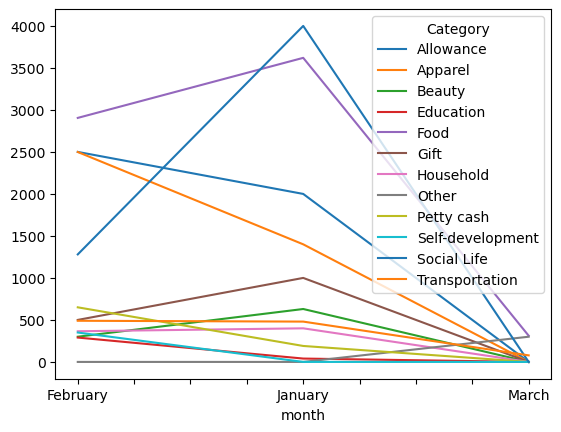

In [28]:
df.pivot_table(index='month',columns='Category',values='INR',aggfunc='sum',fill_value=0).plot()

<Axes: xlabel='month'>

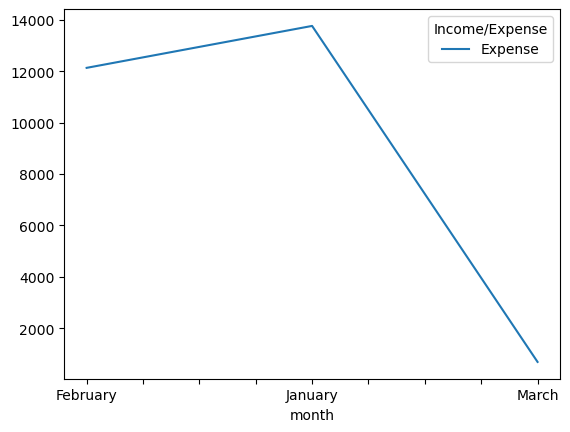

In [29]:
df.pivot_table(index='month',columns='Income/Expense',values='INR',aggfunc='sum',fill_value=0).plot()

<Axes: xlabel='month'>

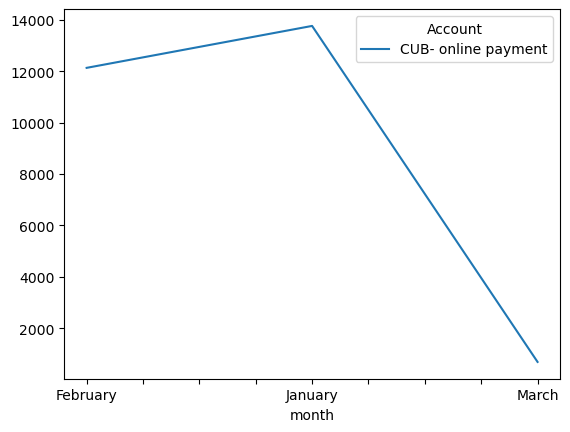

In [30]:
df.pivot_table(index='month',columns='Account',values='INR',aggfunc='sum',fill_value=0).plot()

# Vectorized String Operations in Pandas


## What are Vectorized String Operations?

Vectorized string operations allow you to apply string functions to entire Series at once without writing explicit loops. Pandas provides a `.str` accessor for this.

In [31]:
import numpy as np
import pandas as pd

### The Problem with Vanilla Python

In [32]:
# Vectorized operations work great for numbers
a = np.array([1, 2, 3, 4])
a * 4

array([ 4,  8, 12, 16])

In [33]:
# But with strings and None values, list comprehension fails
s = ['cat', 'mat', None, 'rat']

try:
    [i.startswith('c') for i in s]  # Error: None has no startswith
except AttributeError as e:
    print(f'Error: {e}')

Error: 'NoneType' object has no attribute 'startswith'


### How Pandas Solves This

Pandas uses the **`.str` accessor** which handles `None`/`NaN` values automatically.

In [34]:
s = pd.Series(['cat', 'mat', None, 'rat'])
s.str.startswith('c')  # NaN handled automatically

0     True
1    False
2     None
3    False
dtype: object

In [35]:
# Fast and optimized - vectorized under the hood
s.str.upper()

0     CAT
1     MAT
2    None
3     RAT
dtype: object


## Loading Titanic Dataset


In [37]:
# import titanic
df = pd.read_csv('Datasets/titanic.csv')
df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object


## Common String Functions

### lower / upper / capitalize / title

In [38]:
df['Name'].str.upper().head()

0                              BRAUND, MR. OWEN HARRIS
1    CUMINGS, MRS. JOHN BRADLEY (FLORENCE BRIGGS TH...
2                               HEIKKINEN, MISS. LAINA
3         FUTRELLE, MRS. JACQUES HEATH (LILY MAY PEEL)
4                             ALLEN, MR. WILLIAM HENRY
Name: Name, dtype: object

In [39]:
df['Name'].str.lower().head()

0                              braund, mr. owen harris
1    cumings, mrs. john bradley (florence briggs th...
2                               heikkinen, miss. laina
3         futrelle, mrs. jacques heath (lily may peel)
4                             allen, mr. william henry
Name: Name, dtype: object

In [40]:
df['Name'].str.capitalize().head()

0                              Braund, mr. owen harris
1    Cumings, mrs. john bradley (florence briggs th...
2                               Heikkinen, miss. laina
3         Futrelle, mrs. jacques heath (lily may peel)
4                             Allen, mr. william henry
Name: Name, dtype: object

In [41]:
df['Name'].str.title().head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

### len

In [42]:
# Find the name with maximum length
df['Name'].str.len().max()

82

In [43]:
# Get that name
df['Name'][df['Name'].str.len() == 82].values[0]

'Penasco y Castellana, Mrs. Victor de Satode (Maria Josefa Perez de Soto y Vallejo)'

### strip

Removes leading/trailing whitespace.

In [44]:
# Manual strip example
"                   nitish                              ".strip()

'nitish'

In [45]:
# Strip all names
df['Name'].str.strip().head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object


## split -> get

In [47]:
# Split by comma and get last name
df['lastname'] = df['Name'].str.split(',').str.get(0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen


In [49]:
# Split first name and title
df[['title', 'firstname']] = df['Name'].str.split(',').str.get(1).str.strip().str.split(' ', n=1, expand=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr.,Owen Harris
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs.,John Bradley (Florence Briggs Thayer)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss.,Laina
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs.,Jacques Heath (Lily May Peel)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr.,William Henry


In [50]:
# Value counts for titles
df['title'].value_counts()

title
Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Mlle.          2
Major.         2
Col.           2
the            1
Capt.          1
Ms.            1
Sir.           1
Lady.          1
Mme.           1
Don.           1
Jonkheer.      1
Name: count, dtype: int64


## replace

In [51]:
# Replace inconsistent title values
df['title'] = df['title'].str.replace('Ms.', 'Miss.', regex=False)
df['title'] = df['title'].str.replace('Mlle.', 'Miss.', regex=False)
df['title'].value_counts()

title
Mr.          517
Miss.        185
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Major.         2
Col.           2
Don.           1
Mme.           1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Name: count, dtype: int64


## Filtering with String Methods

### startswith / endswith

In [52]:
# Names that start with 'B'
df[df['Name'].str.startswith('B')][['Name']].head()

,Name
0,"Braund, Mr. Owen Harris"
11,"Bonnell, Miss. Elizabeth"
21,"Beesley, Mr. Lawrence"
74,"Bing, Mr. Lee"
85,"Backstrom, Mrs. Karl Alfred (Maria Mathilda Gu..."


In [53]:
# First names that end with 'a'
df[df['firstname'].str.endswith('a')][['firstname']].head()

,firstname
2,Laina
14,Hulda Amanda Adolfina
19,Fatima
24,Torborg Danira
32,Mary Agatha


### isdigit / isalpha

In [54]:
# Check for numeric first names (edge cases)
df[df['firstname'].str.isdigit()][['firstname']]

,firstname



## Regex with String Methods

### contains

In [55]:
# Find names containing 'john' (case-insensitive)
df[df['firstname'].str.contains('john', case=False)][['firstname']]

,firstname
1,John Bradley (Florence Briggs Thayer)
41,William John Robert (Dorothy Ann Wonnacott)
45,William John
98,John T (Ada Julia Bone)
112,David John
117,William John Robert
160,John Hatfield
162,John Viktor
165,"Frank John William ""Frankie"""
168,John D


In [56]:
# Find lastnames where start and end chars are not vowels
df[df['lastname'].str.contains('^[^aeiouAEIOU].+[^aeiouAEIOU]$')][['lastname']].head(10)

,lastname
0,Braund
1,Cumings
2,Heikkinen
5,Moran
6,McCarthy
7,Palsson
8,Johnson
9,Nasser
10,Sandstrom
11,Bonnell



## Slicing

In [57]:
# Reverse all names using string slicing
df['Name'].str[::-1].head()

0                              sirraH newO .rM ,dnuarB
1    )reyahT sggirB ecnerolF( yeldarB nhoJ .srM ,sg...
2                               aniaL .ssiM ,nenikkieH
3         )leeP yaM yliL( htaeH seuqcaJ .srM ,ellertuF
4                             yrneH mailliW .rM ,nellA
Name: Name, dtype: object


## Datetime in Pandas

Pandas provides excellent datetime handling capabilities. It combines:
- **Ease of use** of Python's `datetime`
- **Efficient storage** and vectorized interface of NumPy's `datetime64`

In [58]:
import numpy as np
import pandas as pd
import datetime as dt


## Timestamp Object

A **Timestamp** references a particular moment in time.

### Creating Timestamp Objects

In [59]:
# Creating a timestamp
print(type(pd.Timestamp('2023/1/5')))
pd.Timestamp('2023/1/5')

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


Timestamp('2023-01-05 00:00:00')

In [60]:
# Variations
print(pd.Timestamp('2023-1-5'))
print(pd.Timestamp('2023, 1, 5'))
print(pd.Timestamp('2023'))

2023-01-05 00:00:00
2023-01-05 00:00:00
2023-01-01 00:00:00


In [61]:
# Using text
pd.Timestamp('5th January 2023')

Timestamp('2023-01-05 00:00:00')

In [62]:
# Providing time also
pd.Timestamp('5th January 2023 9:21AM')

Timestamp('2023-01-05 09:21:00')

In [63]:
# Using datetime.datetime object
x = pd.Timestamp(dt.datetime(2023, 1, 5, 9, 21, 56))
x

Timestamp('2023-01-05 09:21:56')

### Fetching Attributes

In [64]:
print(f'Year:   {x.year}')
print(f'Month:  {x.month}')
print(f'Day:    {x.day}')
print(f'Hour:   {x.hour}')
print(f'Minute: {x.minute}')
print(f'Second: {x.second}')

Year:   2023
Month:  1
Day:    5
Hour:   9
Minute: 21
Second: 56



## Why Separate Datetime Objects?

Python already has `datetime` - why does Pandas need its own?

- **Syntax wise:** `datetime` is very convenient
- **Performance:** Python's `datetime` is slow with large data
- **NumPy's solution:** `datetime64` dtype encodes dates as 64-bit integers
  - Allows arrays of dates to be represented very compactly
  - Much faster than Python's `datetime` for large arrays

In [65]:
import numpy as np

In [66]:
# NumPy datetime64 example
date = np.array('2015-07-04', dtype=np.datetime64)
print(type(date))
print(date)

<class 'numpy.ndarray'>
2015-07-04


In [67]:
# Vectorized operations on datetime
date + np.arange(12)  # Add 12 months

array(['2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07',
       '2015-07-08', '2015-07-09', '2015-07-10', '2015-07-11',
       '2015-07-12', '2015-07-13', '2015-07-14', '2015-07-15'],
      dtype='datetime64[D]')

**Key Insight:**
- NumPy `datetime64` = uniform type = fast vectorized operations
- Python `datetime` = flexible but slow
- Pandas `Timestamp` = combines both advantages


## DatetimeIndex Object

A **DatetimeIndex** is a collection of Timestamps, used to index data in Series/DataFrame.

### Creating DatetimeIndex

In [68]:
# From strings
dt_index = pd.DatetimeIndex(['2023/1/1', '2022/1/1', '2021/1/1'])
print(type(dt_index))
dt_index

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [69]:
# Using python datetime objects
pd.DatetimeIndex([dt.datetime(2023, 1, 1), dt.datetime(2022, 1, 1), dt.datetime(2021, 1, 1)])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [70]:
# Using pd.Timestamp objects
pd.DatetimeIndex([pd.Timestamp(2023, 1, 1), pd.Timestamp(2022, 1, 1), pd.Timestamp(2021, 1, 1)])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

### Using DatetimeIndex as Series Index

In [71]:
pd.Series([1, 2, 3], index=dt_index)

2023-01-01    1
2022-01-01    2
2021-01-01    3
dtype: int64


## date_range Function

Generate a range of dates with a specified frequency.

### Basic Daily Range

In [72]:
pd.date_range(start='2023/1/5', end='2023/2/28', freq='D')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
               '2023-01-25', '2023-01-26', '2023-01-27', '2023-01-28',
               '2023-01-29', '2023-01-30', '2023-01-31', '2023-02-01',
               '2023-02-02', '2023-02-03', '2023-02-04', '2023-02-05',
               '2023-02-06', '2023-02-07', '2023-02-08', '2023-02-09',
               '2023-02-10', '2023-02-11', '2023-02-12', '2023-02-13',
               '2023-02-14', '2023-02-15', '2023-02-16', '2023-02-17',
               '2023-02-18', '2023-02-19', '2023-02-20', '2023-02-21',
               '2023-02-22', '2023-02-23', '2023-02-24', '2023-02-25',
               '2023-02-26', '2023-02-27', '2023-02-28'],
              dtype

### Alternate Days (3D)

In [73]:
pd.date_range(start='2023/1/5', end='2023/2/28', freq='3D')

DatetimeIndex(['2023-01-05', '2023-01-08', '2023-01-11', '2023-01-14',
               '2023-01-17', '2023-01-20', '2023-01-23', '2023-01-26',
               '2023-01-29', '2023-02-01', '2023-02-04', '2023-02-07',
               '2023-02-10', '2023-02-13', '2023-02-16', '2023-02-19',
               '2023-02-22', '2023-02-25', '2023-02-28'],
              dtype='datetime64[ns]', freq='3D')

### Business Days (B)

In [74]:
pd.date_range(start='2023/1/5', end='2023/2/28', freq='B')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-09', '2023-01-10',
               '2023-01-11', '2023-01-12', '2023-01-13', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-23', '2023-01-24', '2023-01-25', '2023-01-26',
               '2023-01-27', '2023-01-30', '2023-01-31', '2023-02-01',
               '2023-02-02', '2023-02-03', '2023-02-06', '2023-02-07',
               '2023-02-08', '2023-02-09', '2023-02-10', '2023-02-13',
               '2023-02-14', '2023-02-15', '2023-02-16', '2023-02-17',
               '2023-02-20', '2023-02-21', '2023-02-22', '2023-02-23',
               '2023-02-24', '2023-02-27', '2023-02-28'],
              dtype='datetime64[ns]', freq='B')

### Weekly - Specific Day

In [75]:
# Every Thursday
pd.date_range(start='2023/1/5', end='2023/2/28', freq='W-THU')

DatetimeIndex(['2023-01-05', '2023-01-12', '2023-01-19', '2023-01-26',
               '2023-02-02', '2023-02-09', '2023-02-16', '2023-02-23'],
              dtype='datetime64[ns]', freq='W-THU')

### Hourly Data

In [76]:
pd.date_range(start='2023/1/5', end='2023/1/6', freq='6H')

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\3423136638.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start='2023/1/5', end='2023/1/6', freq='6H')


DatetimeIndex(['2023-01-05 00:00:00', '2023-01-05 06:00:00',
               '2023-01-05 12:00:00', '2023-01-05 18:00:00',
               '2023-01-06 00:00:00'],
              dtype='datetime64[ns]', freq='6h')

### Month End (M) / Month Start (MS)

In [77]:
# Month end
print('Month End:')
print(pd.date_range(start='2023/1/5', end='2023/6/28', freq='M'))
print()
# Month start
print('Month Start:')
print(pd.date_range(start='2023/1/5', end='2023/6/28', freq='MS'))

Month End:
DatetimeIndex(['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30',
               '2023-05-31'],
              dtype='datetime64[ns]', freq='ME')

Month Start:
DatetimeIndex(['2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01',
               '2023-06-01'],
              dtype='datetime64[ns]', freq='MS')


C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\62372629.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  print(pd.date_range(start='2023/1/5', end='2023/6/28', freq='M'))


### Year End (A)

In [78]:
pd.date_range(start='2023/1/5', end='2030/2/28', freq='A')

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\3677121903.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  pd.date_range(start='2023/1/5', end='2030/2/28', freq='A')


DatetimeIndex(['2023-12-31', '2024-12-31', '2025-12-31', '2026-12-31',
               '2027-12-31', '2028-12-31', '2029-12-31'],
              dtype='datetime64[ns]', freq='YE-DEC')

### Using Periods (number of results)

In [79]:
pd.date_range(start='2023/1/5', periods=12, freq='M')

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\25685905.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(start='2023/1/5', periods=12, freq='M')


DatetimeIndex(['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30',
               '2023-05-31', '2023-06-30', '2023-07-31', '2023-08-31',
               '2023-09-30', '2023-10-31', '2023-11-30', '2023-12-31'],
              dtype='datetime64[ns]', freq='ME')

### Frequency Reference

| Code | Description |
|------|-------------|
| `D` | Calendar day |
| `B` | Business day |
| `W` | Weekly |
| `M` | Month end |
| `MS` | Month start |
| `Q` | Quarter end |
| `QS` | Quarter start |
| `A` | Year end |
| `AS` | Year start |
| `H` | Hourly |
| `T` or `min` | Minute |
| `S` | Second |


## to_datetime Function

Converts existing objects to Pandas Timestamp/DatetimeIndex.

### Simple Series Example

In [83]:
# simple series example
s = pd.Series(['2023/1/1','2022/1/1','2021/1/1'])
pd.to_datetime(s).dt.day_name()

0      Sunday
1    Saturday
2      Friday
dtype: object

### Handling Errors

In [84]:
# with errors
s = pd.Series(['2023/1/1','2022/1/1','2021/130/1'])
pd.to_datetime(s,errors='coerce').dt.month_name()

0    January
1    January
2        NaN
dtype: object

In [85]:
df = pd.read_csv('Datasets/expense_data.csv')
df.shape

(129, 11)

In [86]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB- online payment,Food,Brownie,NaN,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB- online payment,Other,To lended people,NaN,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB- online payment,Transportation,Dinner,NaN,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB- online payment,Food,Metro,NaN,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB- online payment,Food,Snacks,NaN,67.0,Expense,NaN,67.0,INR,67.0


In [87]:
df['Date'] = pd.to_datetime(df['Date'])

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            129 non-null    datetime64[ns]
 1   Account         129 non-null    object        
 2   Category        129 non-null    object        
 3   Subcategory     129 non-null    object        
 4   Note            0 non-null      float64       
 5   INR             129 non-null    float64       
 6   Income/Expense  129 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          129 non-null    float64       
 9   Currency        129 non-null    object        
 10  Account.1       129 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 11.2+ KB



## dt Accessor

The **`.dt` accessor** provides access to datetime-like properties of Series values.

### Common Properties
| Property | Description |
|----------|-------------|
| `.dt.year` | Year |
| `.dt.month` | Month (1-12) |
| `.dt.day` | Day (1-31) |
| `.dt.hour` | Hour (0-23) |
| `.dt.minute` | Minute (0-59) |
| `.dt.day_name()` | Day name (Monday, etc.) |
| `.dt.month_name()` | Month name (January, etc.) |
| `.dt.is_month_start` | True if first day of month |
| `.dt.is_month_end` | True if last day of month |
| `.dt.is_quarter_start` | True if first day of quarter |
| `.dt.day_of_week` | Day of week (0=Monday) |

### Expense Data Example

In [90]:
df = pd.read_csv('Datasets/expense_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (129, 11)


,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB- online payment,Food,Brownie,NaN,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB- online payment,Other,To lended people,NaN,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB- online payment,Transportation,Dinner,NaN,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB- online payment,Food,Metro,NaN,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB- online payment,Food,Snacks,NaN,67.0,Expense,NaN,67.0,INR,67.0


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            129 non-null    object 
 1   Account         129 non-null    object 
 2   Category        129 non-null    object 
 3   Subcategory     129 non-null    object 
 4   Note            0 non-null      float64
 5   INR             129 non-null    float64
 6   Income/Expense  129 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          129 non-null    float64
 9   Currency        129 non-null    object 
 10  Account.1       129 non-null    float64
dtypes: float64(5), object(6)
memory usage: 11.2+ KB


In [92]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            129 non-null    datetime64[ns]
 1   Account         129 non-null    object        
 2   Category        129 non-null    object        
 3   Subcategory     129 non-null    object        
 4   Note            0 non-null      float64       
 5   INR             129 non-null    float64       
 6   Income/Expense  129 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          129 non-null    float64       
 9   Currency        129 non-null    object        
 10  Account.1       129 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 11.2+ KB


In [93]:
# Check quarter start
df['Date'].dt.is_quarter_start.head(10)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: Date, dtype: bool

### Plotting Expenses

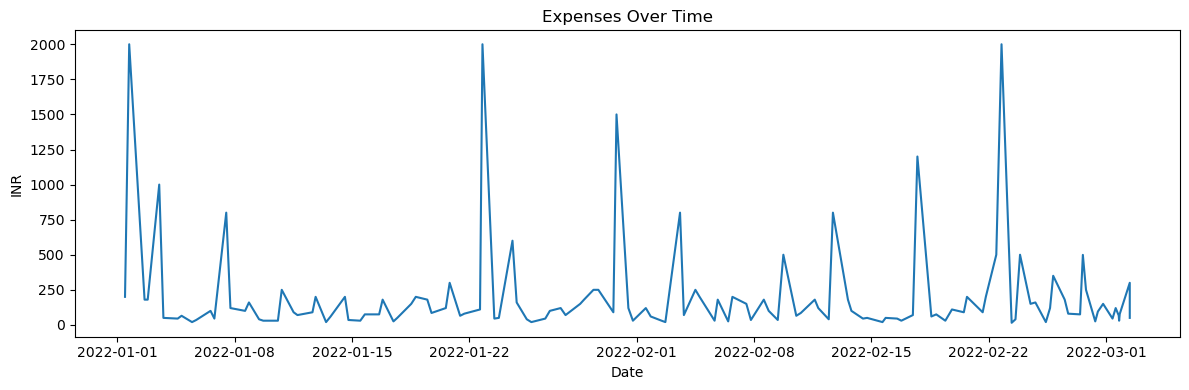

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['INR'])
plt.title('Expenses Over Time')
plt.xlabel('Date')
plt.ylabel('INR')
plt.tight_layout()
plt.show()

### Grouping by Day Name

In [95]:
df['day_name'] = df['Date'].dt.day_name()
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name
0,2022-03-02 10:11:00,CUB- online payment,Food,Brownie,NaN,50.0,Expense,NaN,50.0,INR,50.0,Wednesday
1,2022-03-02 10:11:00,CUB- online payment,Other,To lended people,NaN,300.0,Expense,NaN,300.0,INR,300.0,Wednesday
2,2022-03-01 19:50:00,CUB- online payment,Transportation,Dinner,NaN,78.0,Expense,NaN,78.0,INR,78.0,Tuesday
3,2022-03-01 18:56:00,CUB- online payment,Food,Metro,NaN,30.0,Expense,NaN,30.0,INR,30.0,Tuesday
4,2022-03-01 18:22:00,CUB- online payment,Food,Snacks,NaN,67.0,Expense,NaN,67.0,INR,67.0,Tuesday


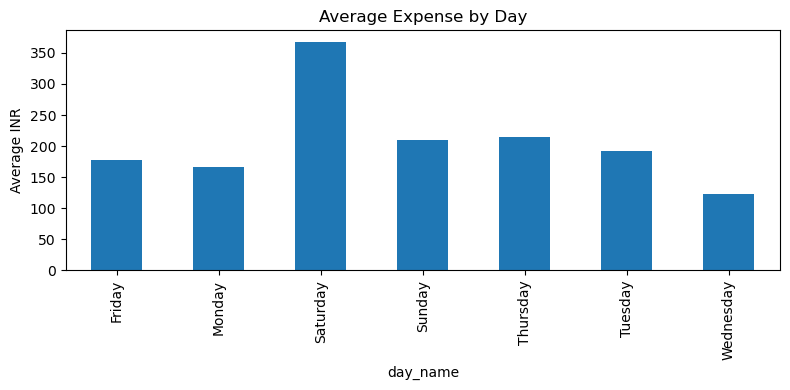

In [96]:
plt.figure(figsize=(8, 4))
df.groupby('day_name')['INR'].mean().plot(kind='bar')
plt.title('Average Expense by Day')
plt.ylabel('Average INR')
plt.tight_layout()
plt.show()

### Grouping by Month Name

In [97]:
df['month_name'] = df['Date'].dt.month_name()
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name,month_name
0,2022-03-02 10:11:00,CUB- online payment,Food,Brownie,NaN,50.0,Expense,NaN,50.0,INR,50.0,Wednesday,March
1,2022-03-02 10:11:00,CUB- online payment,Other,To lended people,NaN,300.0,Expense,NaN,300.0,INR,300.0,Wednesday,March
2,2022-03-01 19:50:00,CUB- online payment,Transportation,Dinner,NaN,78.0,Expense,NaN,78.0,INR,78.0,Tuesday,March
3,2022-03-01 18:56:00,CUB- online payment,Food,Metro,NaN,30.0,Expense,NaN,30.0,INR,30.0,Tuesday,March
4,2022-03-01 18:22:00,CUB- online payment,Food,Snacks,NaN,67.0,Expense,NaN,67.0,INR,67.0,Tuesday,March


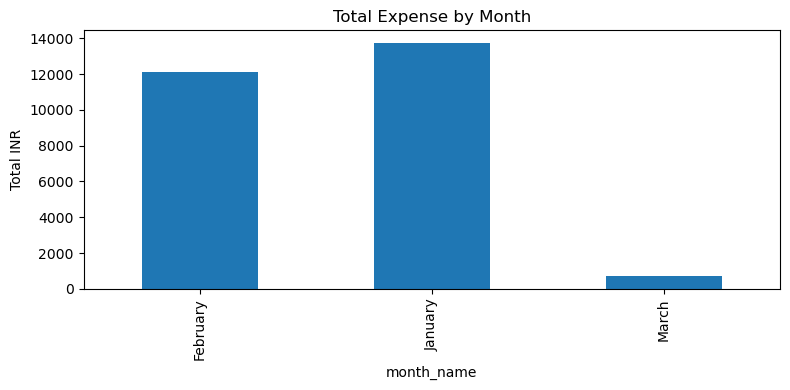

In [98]:
plt.figure(figsize=(8, 4))
df.groupby('month_name')['INR'].sum().plot(kind='bar')
plt.title('Total Expense by Month')
plt.ylabel('Total INR')
plt.tight_layout()
plt.show()

### Filtering with datetime properties

In [99]:
# Days that are month end
df[df['Date'].dt.is_month_end][['Date', 'INR']].head()

,Date,INR
7,2022-02-28 20:00:00,150.0
8,2022-02-28 12:30:00,95.0
9,2022-02-28 08:45:00,25.0
67,2022-01-31 18:30:00,30.0
68,2022-01-31 12:00:00,120.0



## String & Datetime Practice Problems

In [100]:
import pandas as pd
import numpy as np
import re

pd.options.display.max_columns = None

### Q1: Cars Price & Miles Pivot Table

Dataset: https://tinyurl.com/2r24n45l

Tasks:
- Make a pivot table of brands from 2018-2022
- Price shown as average values, Miles as median
- Plot KDE charts for Price and Miles

Challenges:
- No brand column - extract from Name
- Year column has misleading values - clean them

In [102]:
df = pd.read_csv('https://tinyurl.com/2r24n45l')
print(f'Shape: {df.shape}')
df.head()

Shape: (22000, 4)


,Name,Year,Miles,Price
0,Chevrolet Trax,2018,41946,16990
1,GMC Terrain,2020,45328,23990
2,Jeep Wrangler,2012,81068,21590
3,Jeep Renegade,2019,35372,21590
4,BMW X,20173,68992,22990


In [103]:
# Extract brand from Name
df['Brand'] = df['Name'].str.split(' ').str.get(0)
df.head()

,Name,Year,Miles,Price,Brand
0,Chevrolet Trax,2018,41946,16990,Chevrolet
1,GMC Terrain,2020,45328,23990,GMC
2,Jeep Wrangler,2012,81068,21590,Jeep
3,Jeep Renegade,2019,35372,21590,Jeep
4,BMW X,20173,68992,22990,BMW


In [104]:
# Clean Year column - extract 4-digit year
df['Year'] = df['Year'].apply(lambda x: int(re.findall(r'\d{4}', str(x))[0]))
df.head()

,Name,Year,Miles,Price,Brand
0,Chevrolet Trax,2018,41946,16990,Chevrolet
1,GMC Terrain,2020,45328,23990,GMC
2,Jeep Wrangler,2012,81068,21590,Jeep
3,Jeep Renegade,2019,35372,21590,Jeep
4,BMW X,2017,68992,22990,BMW


In [105]:
# Create pivot table
pt = df.query('Year >= 2018 and Year <= 2022').pivot_table(
    index='Brand',
    columns='Year',
    values=['Price', 'Miles'],
    aggfunc={'Price': 'mean', 'Miles': 'median'}
)
pt

Miles                                             Price  \
Year              2018     2019     2020     2021     2022          2018   
Brand                                                                      
Acura          32516.0  50959.0  30894.0  10922.0      NaN  25323.333333   
Alfa           38908.0  20928.0      NaN      NaN      NaN  28490.000000   
Audi           49762.0  50169.5  30423.5  11205.0  20917.0  30345.555556   
BMW            39269.0  36306.0  23171.0  19978.0   3780.0  31762.093023   
Buick          50702.0  41152.0  36626.0  39884.0    372.0  21516.254545   
Cadillac       57116.0  29609.0  41046.0      NaN      NaN  28390.000000   
Chevrolet      53355.0  46375.0  50743.0  37527.0  13022.0  21262.413043   
Chrysler       64685.5  65963.0  48960.0  44225.0  24427.0  24125.062500   
Dodge          78986.0  65497.0  30995.5  32159.5   9089.0  20807.283951   
FIAT           24731.0  14573.0      NaN      NaN      NaN  22602.500000   
Ford           50572.0  47657.5  49136.0  22391.0   5298.5  20214.190283   
GMC            54181.0  54017.0  54055.0  41904.5   9854.0  26052.206897   
Genesis        42192.0  16855.0      NaN  16937.0  13938.5  28839.000000   
Honda          46242.0  39322.0  35812.0   9286.0  18500.0  24265.054054   
Hyundai        56075.0  44910.0  35882.5  31592.0   8160.0  19335.487603   
INFINITI       49555.5  61327.0  47858.0  35966.0      NaN  26140.000000   
Jaguar         35119.0  30563.0  17456.0   6943.0      NaN  33323.333333   
Jeep           53690.5  21836.5  41416.0  44188.5   8662.5  21362.570175   
Kia            37993.0  27189.0  37605.0  32006.0  14114.0  21565.608108   
Land           58929.0  41484.0  36232.0      NaN      NaN  39990.000000   
Lexus          53174.0  25356.5  21377.5  18073.0  20985.0  36056.666667   
Lincoln        43874.0  23501.5  50080.0      NaN   9494.0  26462.785714   
MAZDA          44267.0  37844.0  31832.0  41606.0   2338.0  22720.603448   
MINI           36562.0  35508.0  13268.0      NaN   5758.5  25065.000000   
Maserati           NaN  28766.0      NaN      NaN   5339.0           NaN   
Mercedes-Benz  31408.5  28937.0  22008.0  12435.0  10880.0  34910.000000   
Mitsubishi     48827.0  45100.0  39941.0  31809.0   6774.0  17137.058824   
Nissan         39266.0  37208.0  49741.0  41186.0   9975.0  20050.358209   
Polestar           NaN      NaN      NaN      NaN   6188.0           NaN   
Porsche        47451.0      NaN      NaN      NaN      NaN  45156.666667   
Ram            43299.0  41717.5  27715.5  30617.0   3664.5  34990.000000   
Subaru         51900.0  40909.0  19885.0  44615.0   9899.0  23732.857143   
Tesla          32481.0  26977.5  24383.0  15517.0   6454.0  42923.333333   
Toyota         45770.0  19796.0  37726.0  20862.0   6769.0  22926.622449   
Volkswagen     50991.0  46335.0  30069.0  23098.0  14056.5  21447.142857   
Volvo          79121.0  23902.0  41457.5  36590.0   1758.0  27306.666667   
smart          14825.0      NaN      NaN      NaN      NaN  17765.000000   

                                                                        
Year                   2019          2020          2021           2022  
Brand                                                                   
Acura          34496.777778  37590.000000  43856.666667            NaN  
Alfa           30475.714286           NaN           NaN            NaN  
Audi           28590.000000  32490.000000  71990.000000   39590.000000  
BMW            33280.909091  39811.083333  37062.727273   57030.000000  
Buick          21033.632653  24141.947368  25796.842105   26940.000000  
Cadillac       32290.000000  38777.266667           NaN            NaN  
Chevrolet      21119.717647  24684.226950  25234.727273   42358.421053  
Chrysler       26628.142857  28668.142857  26471.978723   35190.000000  
Dodge          23036.666667  26782.535714  32565.357143   36256.666667  
FIAT           23904.285714           NaN           NaN            NaN  
Ford           21698.428571

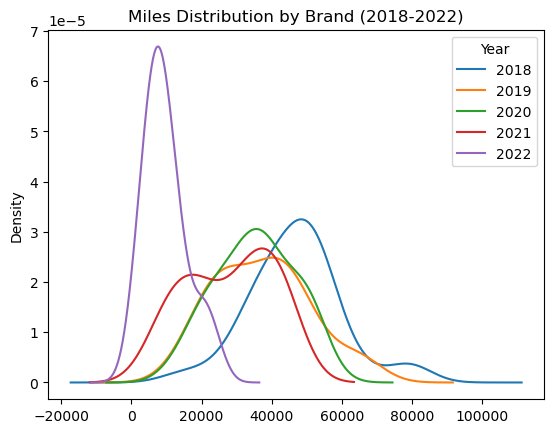

In [106]:
pt['Miles'].plot(kind='kde')
plt.title('Miles Distribution by Brand (2018-2022)')
plt.show()

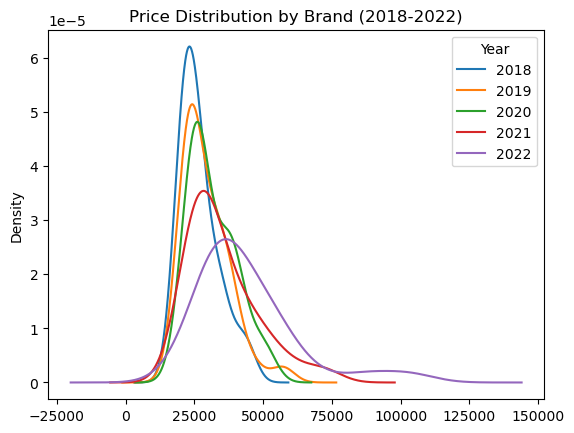

In [107]:
pt['Price'].plot(kind='kde')
plt.title('Price Distribution by Brand (2018-2022)')
plt.show()

### Q2: Daily Power Generation in India

Dataset: https://tinyurl.com/2nq6kugt

Tasks:
- Find required power generation (no excess/shortfall)
- Find month of each day
- Top 10 frequent power stations
- Pivot table: power stations by month
- Plot the pivot table

In [109]:
df = pd.read_csv('https://tinyurl.com/2nq6kugt')
print(f'Shape: {df.shape}')
df.head()

Shape: (345273, 11)


,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0


In [110]:
# Required power = Actual - Excess/Shortfall
df['required'] = df['Actual(MU)'] - df['Excess(+) / Shortfall (-)']
df.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation,required
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0,13.00
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0,28.80
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0,40.37
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0,13.57
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0,38.69


In [111]:
# Extract month
df['month'] = pd.to_datetime(df['Dates']).dt.month_name()
df.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation,required,month
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0,13.00,September
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0,28.80,September
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0,40.37,September
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0,13.57,September
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0,38.69,September


In [112]:
# Top 10 power stations
top_10 = df['Power Station'].value_counts().head(10).index.to_list()
print('Top 10 Power Stations:')
print(top_10)

Top 10 Power Stations:
['NTPC Ltd.', 'NHPC', 'NPCIL', 'GMR ENERG', 'JSWEL', 'TATA PCL', 'IBPIL', 'APL', 'JPPVL', 'NLC']


In [113]:
# Pivot table
pt = df[df['Power Station'].isin(top_10)].pivot_table(
    index='month',
    columns='Power Station',
    values='required',
    aggfunc='sum'
)
pt

Power Station,APL,GMR ENERG,IBPIL,JPPVL,JSWEL,NHPC,NLC,NPCIL,NTPC Ltd.,TATA PCL
month,,,,,,,,,,
April,19533.71,3717.59,0.0,3980.52,2944.53,8383.42,6793.71,12896.85,88307.99,2396.70
August,22577.58,4608.33,0.0,4914.53,3938.23,16586.55,8366.19,17945.07,111603.60,2814.73
December,27019.82,5111.68,0.0,5028.26,4741.91,4601.54,9348.39,20564.05,123936.52,2937.99
February,23695.95,4024.02,0.0,3972.52,4365.17,4465.50,8593.60,15943.00,103746.01,2590.94
January,25105.57,4424.09,0.0,4266.63,4704.94,3678.36,9195.73,17711.41,111747.49,2596.91
July,23540.14,4134.48,0.0,3687.77,3666.14,16843.71,8092.45,17288.12,110625.67,2983.62
June,23657.85,4236.74,0.0,5598.50,3769.82,15368.68,7434.07,17410.60,111109.54,3037.92
March,35757.22,5926.42,0.0,5791.59,6069.21,10352.03,12625.23,26475.12,158101.77,4334.42
May,20492.34,3739.89,0.0,4340.72,3129.34,11092.55,6735.69,13446.66,93214.38,2442.60


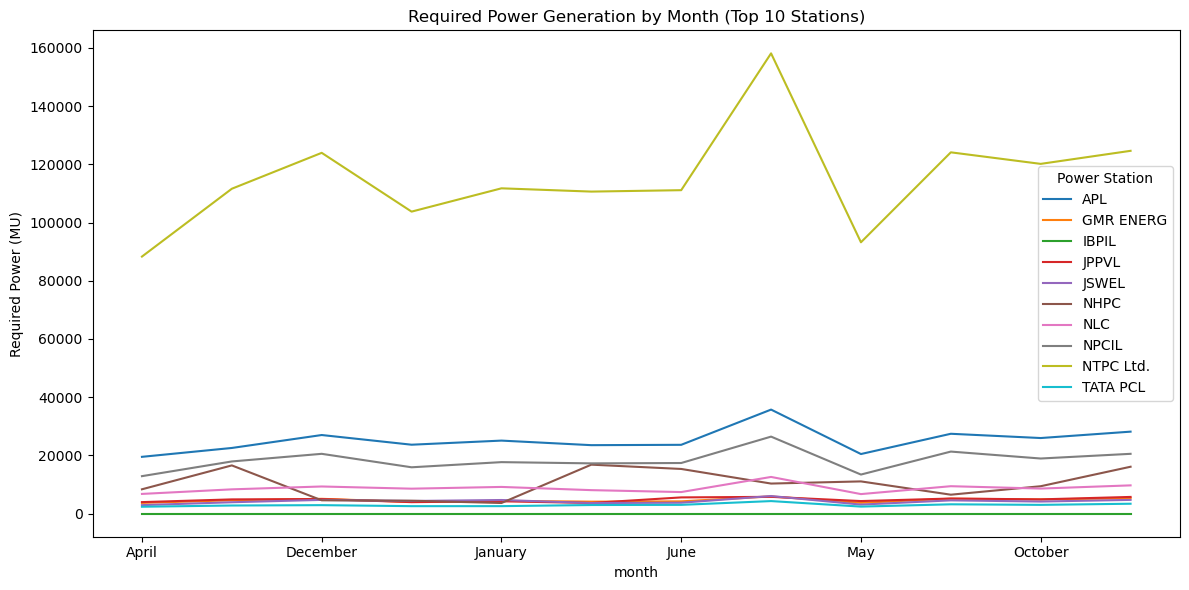

In [114]:
pt.plot(kind='line', figsize=(12, 6))
plt.title('Required Power Generation by Month (Top 10 Stations)')
plt.ylabel('Required Power (MU)')
plt.tight_layout()
plt.show()

### Q3: Question-Answer CSV Parsing

Dataset: https://drive.google.com/file/d/10rmV3XrVtzpDTtYZF3UtCdcU0ajBJjGY/view

Make a dataframe with two columns: `question` and `answers`
- Questions start from `Q<number>` (e.g., `Q1`)
- Answers start from `Ans<number>` (e.g., `Ans1`)

In [115]:
# code here
df = pd.read_csv("Datasets/question-answer.csv")
df

,Unnamed: 0,2
0,0,Q1-What is Data Science?
1,1,"Ans1-Data Science combines statistics, maths, ..."
2,2,Q2-2. How is logistic regression done?
3,3,Ans2-Logistic regression measures the relation...
4,4,Q3-How do you build a random forest model?
5,5,Ans3-A random forest is built up of a number o...
6,6,Q4-How can you avoid overfitting your model?
7,7,Ans4-Overfitting refers to a model that is onl...
8,8,Q5-You are given a data set consisting of vari...
9,9,Ans5-The following are ways to handle missing ...


In [116]:
# Extract questions
ques = df['2'][df['2'].str.startswith('Q')].str.split('-').str.get(1).reset_index()
ques.head()

,index,2
0,0,What is Data Science?
1,2,2. How is logistic regression done?
2,4,How do you build a random forest model?
3,6,How can you avoid overfitting your model?
4,8,You are given a data set consisting of variabl...


In [117]:
# Extract answers
ans = df['2'][df['2'].str.startswith('A')].str.split('-').str.get(1).reset_index()
ans.head()

,index,2
0,1,"Data Science combines statistics, maths, speci..."
1,3,Logistic regression measures the relationship ...
2,5,A random forest is built up of a number of dec...
3,7,Overfitting refers to a model that is only set...
4,9,The following are ways to handle missing data ...


In [118]:
# Merge into result
result = ques.merge(ans, left_index=True, right_index=True)
result = result.drop(columns=['index_x', 'index_y'])
result = result.rename(columns={'2_x': 'Question', '2_y': 'Answer'})
result.head(10)

,Question,Answer
0,What is Data Science?,"Data Science combines statistics, maths, speci..."
1,2. How is logistic regression done?,Logistic regression measures the relationship ...
2,How do you build a random forest model?,A random forest is built up of a number of dec...
3,How can you avoid overfitting your model?,Overfitting refers to a model that is only set...
4,You are given a data set consisting of variabl...,The following are ways to handle missing data ...
5,What is bag of words? How we can use it for te...,Bag of Words is a representation of text that ...
6,How can we use machine learning for text class...,Machine learning classification algorithms pre...
7,What is a time series?,A time series is a set of observations ordered...
8,How is time series different from the usual re...,The principle behind causal forecasting is tha...
9,What are the different types of joins? What ar...,(INNER) JOIN: Returns records that have matchi...


### Q4: Questions Without Question Mark

Print Q&A for questions that do not contain `?`

In [119]:
result[~result['Question'].str.contains('\?')]

,Question,Answer


### Q6-10: Log and Employee Analysis

- Q6: Show activity details month-wise (count for each activity)
- Q7: Employee with most activity in January
- Q8: Employee who worked most on weekends
- Q9: Activity logged most on business days
- Q10: Week day wise activity table

In [120]:
log_file = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv')
employee = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv')
print('Log shape:', log_file.shape)
print('Employee shape:', employee.shape)
log_file.head()

Log shape: (365, 6)
Employee shape: (41, 4)


,Log_ID,dt,dept,emp_id,activity,eqpt
0,1000,2022-01-07,Dept6,115,Cleaning,UPS
1,1001,2022-01-08,Dept4,105,Cleaning,Generator
2,1002,2022-01-09,Dept3,112,Inspection,CPU
3,1003,2022-01-10,Dept4,120,Inspection,UPS
4,1004,2022-01-11,Dept3,138,Checking,Battery


In [121]:
log_file['dt'] = pd.to_datetime(log_file['dt'])
log_file['month'] = log_file['dt'].dt.month_name()
log_file.head()

,Log_ID,dt,dept,emp_id,activity,eqpt,month
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January
1,1001,2022-01-08,Dept4,105,Cleaning,Generator,January
2,1002,2022-01-09,Dept3,112,Inspection,CPU,January
3,1003,2022-01-10,Dept4,120,Inspection,UPS,January
4,1004,2022-01-11,Dept3,138,Checking,Battery,January


**Q6: Activity count month-wise**

In [122]:
log_file.pivot_table(index='month', columns='activity', aggfunc='count')['Log_ID']

activity,Checking,Cleaning,Inspection,Repair
month,,,,
April,5,11,9,5
August,8,10,9,4
December,6,7,12,6
February,7,7,4,10
January,7,10,9,5
July,6,6,14,5
June,5,7,8,10
March,8,6,5,12
May,5,8,7,11


**Q7: Employee with most activity in January**

In [123]:
log_file.query('month == "January"')['emp_id'].value_counts().head(1)

emp_id
122    3
Name: count, dtype: int64

**Q8: Employee who worked most on weekends**

In [124]:
log_file[log_file['dt'].dt.day_of_week > 4]['emp_id'].value_counts().head(1)

emp_id
144    6
Name: count, dtype: int64

**Q9: Activity most logged on business days**

In [125]:
log_file[log_file['dt'].dt.day_of_week <= 4]['activity'].value_counts().head(1)

activity
Inspection    77
Name: count, dtype: int64

**Q10: Week day wise activity table**

In [126]:
log_file['day'] = log_file['dt'].dt.day_name()
log_file.pivot_table(index='day', columns='activity', aggfunc='count')['Log_ID']

activity,Checking,Cleaning,Inspection,Repair
day,,,,
Friday,8,16,20,9
Monday,10,14,13,15
Saturday,18,11,8,15
Sunday,13,13,15,11
Thursday,8,16,16,12
Tuesday,15,9,15,13
Wednesday,14,9,13,16


### Q11: Employee Data Cleaning

1. Fill missing FIRST_NAME using EMAIL and LAST_NAME
   - Email = first letter of first name + last name (e.g., `JMURMAN` → `J` + `Urman`)
2. Add domain to email: `@campusx.com`
3. Show full names of employees starting with 'A' who did ['Incpection', 'Cleaning', 'Checking']

In [127]:
employee = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv')
employee.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,100,Steven,King,SKING
1,101,Neena,Kochhar,NKOCHHAR
2,102,Lex,De Haan,LDEHAAN
3,103,Alexander,Hunold,AHUNOLD
4,104,Bruce,Ernst,BERNST


**Task 1: Fill missing first names**

In [128]:
fill_values = employee[employee['FIRST_NAME'].isnull()].apply(
    lambda x: x['EMAIL'][0] + x['LAST_NAME'][0], axis=1
)
print('Values to fill:')
print(fill_values)

Values to fill:
12    JU
21    AF
32    TO
dtype: object


In [129]:
employee['FIRST_NAME'].fillna(fill_values, inplace=True)
employee.head()

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_3992\2866786855.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  employee['FIRST_NAME'].fillna(fill_values, inplace=True)


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,100,Steven,King,SKING
1,101,Neena,Kochhar,NKOCHHAR
2,102,Lex,De Haan,LDEHAAN
3,103,Alexander,Hunold,AHUNOLD
4,104,Bruce,Ernst,BERNST


**Task 2: Add domain to email**

In [130]:
employee['EMAIL'] = employee['EMAIL'] + '@campusx.com'
employee.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,100,Steven,King,SKING@campusx.com
1,101,Neena,Kochhar,NKOCHHAR@campusx.com
2,102,Lex,De Haan,LDEHAAN@campusx.com
3,103,Alexander,Hunold,AHUNOLD@campusx.com
4,104,Bruce,Ernst,BERNST@campusx.com


**Task 3: Filter employees starting with 'A' who did specific activities**

In [131]:
temp_df = log_file[log_file['activity'].isin(['Incpection', 'Cleaning', 'Checking'])]
x_df = temp_df.merge(employee, right_on='EMPLOYEE_ID', left_on='emp_id')
x_df = x_df[x_df['FIRST_NAME'].str.startswith('A')]
(x_df['FIRST_NAME'] + ' ' + x_df['LAST_NAME']).unique()

array(['Alexander Khoo', 'Alexander Hunold'], dtype=object)

---

# Time Series Analysis in Pandas

A **time series** is a dataset that tracks a sample over time. It allows you to see what factors influence certain variables from period to period.

### Examples of Time Series Data
- **Financial Data:** Company stocks, exchange rates
- **Natural Data:** Rainfall, temperature
- **Event Data:** COVID cases, election results
- **Medical Data:** Heart rate monitoring

### Types of Operations
- **Time Series Analysis:** Understanding patterns and relationships
- **Time Series Forecasting:** Predicting future values

---

## Recap: What We Know

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Timestamp
pd.Timestamp('6th Jan 2023 8:10')

Timestamp('2023-01-06 08:10:00')

In [3]:
# DatetimeIndex
pd.DatetimeIndex([
    pd.Timestamp('6th Jan 2023 8:10'),
    pd.Timestamp('7th Jan 2023 8:10'),
    pd.Timestamp('8th Jan 2023 8:10')
])

DatetimeIndex(['2023-01-06 08:10:00', '2023-01-07 08:10:00',
               '2023-01-08 08:10:00'],
              dtype='datetime64[ns]', freq=None)

In [4]:
# date_range
pd.date_range(start='2023-1-6', end='2023-1-31', freq='D')

DatetimeIndex(['2023-01-06', '2023-01-07', '2023-01-08', '2023-01-09',
               '2023-01-10', '2023-01-11', '2023-01-12', '2023-01-13',
               '2023-01-14', '2023-01-15', '2023-01-16', '2023-01-17',
               '2023-01-18', '2023-01-19', '2023-01-20', '2023-01-21',
               '2023-01-22', '2023-01-23', '2023-01-24', '2023-01-25',
               '2023-01-26', '2023-01-27', '2023-01-28', '2023-01-29',
               '2023-01-30', '2023-01-31'],
              dtype='datetime64[ns]', freq='D')

In [5]:
# to_datetime
s = pd.Series(['2023/1/6', '2023/1/7', '2023/1/7'])
pd.to_datetime(s).dt.day_name()

0      Friday
1    Saturday
2    Saturday
dtype: object


## Timedelta Object

A **Timedelta** represents a **duration** — the difference between two dates or times.

### Creating Timedelta

In [6]:
# From difference of Timestamps
t1 = pd.Timestamp('6th Jan 2023 8:20:14')
t2 = pd.Timestamp('26th Jan 2023 10:00:00')

diff = t2 - t1
print(f'Difference: {diff}')
print(f'Type: {type(diff)}')

Difference: 20 days 01:39:46
Type: <class 'pandas._libs.tslibs.timedeltas.Timedelta'>


In [7]:
# Standalone creation
pd.Timedelta(days=2, hours=10, minutes=35)

Timedelta('2 days 10:35:00')

### Arithmetic with Timedelta

In [8]:
# Add to timestamp
pd.Timestamp('6th Jan 2023') + pd.Timedelta(days=2, hours=10, minutes=35)

Timestamp('2023-01-08 10:35:00')

In [9]:
# Subtract from date_range
pd.date_range(start='2023-1-6', end='2023-1-10', freq='D') - pd.Timedelta(days=2, hours=10, minutes=35)

DatetimeIndex(['2023-01-03 13:25:00', '2023-01-04 13:25:00',
               '2023-01-05 13:25:00', '2023-01-06 13:25:00',
               '2023-01-07 13:25:00'],
              dtype='datetime64[ns]', freq='D')

### Real Life Example: Delivery Time Analysis

In [10]:
# real life example
df = pd.read_csv('Datasets/order.csv')
df.head()

,order_date,delivery_date
0,5/24/98,2/5/99
1,4/22/92,3/6/98
2,2/10/91,8/26/92
3,7/21/92,11/20/97
4,9/2/93,6/10/98


In [11]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_25204\3472121163.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date'] = pd.to_datetime(df['order_date'])
C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_25204\3472121163.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivery_date'] = pd.to_datetime(df['delivery_date'])


In [12]:
# Calculate delivery time period
df['delivery_time_period'] = df['delivery_date'] - df['order_date']
df[['order_date', 'delivery_date', 'delivery_time_period']].head()

,order_date,delivery_date,delivery_time_period
0,1998-05-24,1999-02-05,257 days
1,1992-04-22,1998-03-06,2144 days
2,1991-02-10,1992-08-26,563 days
3,1992-07-21,1997-11-20,1948 days
4,1993-09-02,1998-06-10,1742 days


In [13]:
# Average delivery time
print(f'Average delivery time: {df["delivery_time_period"].mean()}')

Average delivery time: 1217 days 22:53:53.532934128



## Time Series Indexing

Once you set a datetime column as index, you get powerful indexing capabilities.



In [14]:
# Load and prepare data
google = pd.read_csv('Datasets/google.csv')
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19 09:30:00,16.647109,16.652925,16.604722,16.604722,16.604722,145090
1,2004-08-19 09:33:00,16.604722,16.607089,16.604555,16.607089,16.607089,159989
2,2004-08-19 09:36:00,16.607089,16.612081,16.545146,16.545146,16.545146,288786
3,2004-08-19 09:39:00,16.545146,16.546884,16.471603,16.471603,16.471603,211820
4,2004-08-19 09:42:00,16.471603,16.501056,16.461062,16.491428,16.491428,304728


In [15]:
subs = pd.read_csv('Datasets/subscribers.csv')
views = pd.read_csv('Datasets/views.csv')
wt = pd.read_csv('Datasets/watch-time.csv')
comments = pd.read_csv('Datasets/comments.csv')

In [16]:
print(subs.columns)
print(views.columns)
print(wt.columns)
print(comments.columns)

Index(['Date', 'Subscribers'], dtype='object')
Index(['Date', 'Views'], dtype='object')
Index(['Date', 'Watch time (hours)'], dtype='object')
Index(['Date', 'Comments added'], dtype='object')


In [17]:
comments.tail()

,Date,Comments added
399995,2023-10-20 20:55:00,19443
399996,2023-10-20 21:00:00,7459
399997,2023-10-20 21:05:00,20191
399998,2023-10-20 21:10:00,25682
399999,2023-10-20 21:15:00,33719


In [18]:
# Merge all YouTube data
yt = subs.merge(views, on='Date').merge(wt, on='Date').merge(comments, on='Date')
print(f'Shape: {yt.shape}')
yt.head()

Shape: (400000, 5)


,Date,Subscribers,Views,Watch time (hours),Comments added
0,2020-01-01 00:00:00,259766,129742,6297.40,449
1,2020-01-01 00:05:00,259451,146839,6922.53,1180
2,2020-01-01 00:10:00,259847,139920,12076.37,787
3,2020-01-01 00:15:00,260287,101176,7852.43,812
4,2020-01-01 00:20:00,259411,195805,13756.12,1304


In [19]:
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746330 entries, 0 to 746329
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date       746330 non-null  object 
 1   Open       746330 non-null  float64
 2   High       746330 non-null  float64
 3   Low        746330 non-null  float64
 4   Close      746330 non-null  float64
 5   Adj Close  746330 non-null  float64
 6   Volume     746330 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 39.9+ MB


In [20]:
yt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                400000 non-null  object 
 1   Subscribers         400000 non-null  int64  
 2   Views               400000 non-null  int64  
 3   Watch time (hours)  400000 non-null  float64
 4   Comments added      400000 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 15.3+ MB


In [21]:
# Convert to datetime
google['Date'] = pd.to_datetime(google['Date'])
yt['Date'] = pd.to_datetime(yt['Date'])

In [22]:
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746330 entries, 0 to 746329
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       746330 non-null  datetime64[ns]
 1   Open       746330 non-null  float64       
 2   High       746330 non-null  float64       
 3   Low        746330 non-null  float64       
 4   Close      746330 non-null  float64       
 5   Adj Close  746330 non-null  float64       
 6   Volume     746330 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 39.9 MB


In [23]:
yt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                400000 non-null  datetime64[ns]
 1   Subscribers         400000 non-null  int64         
 2   Views               400000 non-null  int64         
 3   Watch time (hours)  400000 non-null  float64       
 4   Comments added      400000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 15.3 MB


In [24]:
# Set Date as index
google.set_index('Date', inplace=True)
yt.set_index('Date', inplace=True)

In [25]:
yt.head()

,Subscribers,Views,Watch time (hours),Comments added
Date,,,,
2020-01-01 00:00:00,259766,129742,6297.40,449
2020-01-01 00:05:00,259451,146839,6922.53,1180
2020-01-01 00:10:00,259847,139920,12076.37,787
2020-01-01 00:15:00,260287,101176,7852.43,812
2020-01-01 00:20:00,259411,195805,13756.12,1304


### Fetch a Specific Date

In [26]:
google.loc['2021-12-30']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-12-30 09:30:00,165.455179,165.499814,165.129371,165.129371,165.129371,6342
2021-12-30 09:33:00,165.129371,165.296030,164.846023,165.039030,165.039030,6227
2021-12-30 09:36:00,165.039030,165.042722,164.880940,164.880940,164.880940,6234
2021-12-30 09:39:00,164.880940,165.084458,164.764960,164.764960,164.764960,5196
2021-12-30 09:42:00,164.764960,165.189489,164.739987,164.796870,164.796870,5402
...,...,...,...,...,...,...
2021-12-30 15:45:00,166.177986,166.180031,165.542294,165.542294,165.542294,3115
2021-12-30 15:48:00,165.542294,166.310282,165.510198,166.310282,166.310282,5970
2021-12-30 15:51:00,166.310282,166.513995,165.607074,165.607074,165.607074,7991


### Partial Indexing (Year/Month)

In [27]:
# Select by year
yt.loc['2022'].head()

,Subscribers,Views,Watch time (hours),Comments added
Date,,,,
2022-01-01 00:00:00,1519018,660062,63477.84,3759
2022-01-01 00:05:00,1520286,867742,45429.36,6745
2022-01-01 00:10:00,1519616,434678,15623.48,1271
2022-01-01 00:15:00,1519518,481529,22497.96,3291
2022-01-01 00:20:00,1518971,716202,61957.25,2674


In [28]:
# Select by year-month
yt.loc['2022-12'].head()

,Subscribers,Views,Watch time (hours),Comments added
Date,,,,
2022-12-01 00:00:00,2268627,738412,23615.06,3590
2022-12-01 00:05:00,2268846,582829,44352.64,3147
2022-12-01 00:10:00,2269275,1291162,76519.35,10046
2022-12-01 00:15:00,2269792,1352240,134476.39,5051
2022-12-01 00:20:00,2269461,1350573,42682.43,6921


### Create Date Attributes

In [29]:
# YouTube data attributes
yt['month_name'] = yt.index.month_name()
yt['weekday_name'] = yt.index.day_name()
yt['quarter'] = yt.index.quarter
yt.head()

,Subscribers,Views,Watch time (hours),Comments added,month_name,weekday_name,quarter
Date,,,,,,,
2020-01-01 00:00:00,259766,129742,6297.40,449,January,Wednesday,1
2020-01-01 00:05:00,259451,146839,6922.53,1180,January,Wednesday,1
2020-01-01 00:10:00,259847,139920,12076.37,787,January,Wednesday,1
2020-01-01 00:15:00,260287,101176,7852.43,812,January,Wednesday,1
2020-01-01 00:20:00,259411,195805,13756.12,1304,January,Wednesday,1


In [30]:
# Google data attributes
google['month_name'] = google.index.month_name()
google['weekday_name'] = google.index.day_name()
google['quarter'] = google.index.quarter
google.head()

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19 09:30:00,16.647109,16.652925,16.604722,16.604722,16.604722,145090,August,Thursday,3
2004-08-19 09:33:00,16.604722,16.607089,16.604555,16.607089,16.607089,159989,August,Thursday,3
2004-08-19 09:36:00,16.607089,16.612081,16.545146,16.545146,16.545146,288786,August,Thursday,3
2004-08-19 09:39:00,16.545146,16.546884,16.471603,16.471603,16.471603,211820,August,Thursday,3
2004-08-19 09:42:00,16.471603,16.501056,16.461062,16.491428,16.491428,304728,August,Thursday,3


### Slicing

In [31]:
# Slice by date range
yt.loc['2022-12-15':'2023-01-01']

,Subscribers,Views,Watch time (hours),Comments added,month_name,weekday_name,quarter
Date,,,,,,,
2022-12-15 00:00:00,2293341,1254303,108387.66,2818,December,Thursday,4
2022-12-15 00:05:00,2294684,1718397,136420.44,11862,December,Thursday,4
2022-12-15 00:10:00,2294429,1636313,158861.71,8450,December,Thursday,4
2022-12-15 00:15:00,2294503,794043,50254.53,2369,December,Thursday,4
2022-12-15 00:20:00,2294681,877489,82486.00,6514,December,Thursday,4
...,...,...,...,...,...,...,...
2023-01-01 23:35:00,2326336,1791886,81076.39,10244,January,Sunday,1
2023-01-01 23:40:00,2326651,3614869,340234.35,11253,January,Sunday,1
2023-01-01 23:45:00,2325666,2761632,198992.30,4831,January,Sunday,1


In [32]:
# Every other day
yt.loc['2022-12-15':'2023-01-01':2]

,Subscribers,Views,Watch time (hours),Comments added,month_name,weekday_name,quarter
Date,,,,,,,
2022-12-15 00:00:00,2293341,1254303,108387.66,2818,December,Thursday,4
2022-12-15 00:10:00,2294429,1636313,158861.71,8450,December,Thursday,4
2022-12-15 00:20:00,2294681,877489,82486.00,6514,December,Thursday,4
2022-12-15 00:30:00,2295045,574415,25587.96,745,December,Thursday,4
2022-12-15 00:40:00,2294151,1276725,54466.30,4125,December,Thursday,4
...,...,...,...,...,...,...,...
2023-01-01 23:10:00,2325542,4220857,214052.06,17895,January,Sunday,1
2023-01-01 23:20:00,2326957,3618090,293562.28,12877,January,Sunday,1
2023-01-01 23:30:00,2326681,4374112,302885.78,29651,January,Sunday,1


### Challenge: Fetch Same Date Every Year

In [33]:
google.tail()

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2026-08-20 15:45:00,186.390367,186.402202,185.810685,185.810685,185.810685,214683,August,Thursday,3
2026-08-20 15:48:00,185.810685,185.812232,185.591225,185.591225,185.591225,399978,August,Thursday,3
2026-08-20 15:51:00,185.591225,185.617112,185.129352,185.129352,185.129352,258673,August,Thursday,3
2026-08-20 15:54:00,185.129352,185.132369,185.000000,185.000000,185.000000,249603,August,Thursday,3
2026-08-20 15:57:00,185.000000,185.365765,184.980049,185.000000,185.000000,337346,August,Thursday,3


In [34]:
google = pd.read_csv('Datasets/google.csv')
google['Date'] = pd.to_datetime(google['Date'])
google = google.set_index('Date')
jan6 = google[(google.index.month == 1) & (google.index.day == 6)]
jan6_per_year = jan6.groupby(jan6.index.year).first()
jan6_per_year

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2005,14.013101,14.016318,13.980445,13.980445,13.980445,204984
2006,18.987603,19.102643,18.986728,19.102643,19.102643,362165
2009,61.622227,61.832088,61.530480,61.832088,61.832088,157457
2010,67.467931,67.478246,67.360450,67.460927,67.460927,1849373
2011,125.450032,126.136103,125.079383,125.203677,125.203677,150744
2012,144.389262,144.514448,143.927651,143.927651,143.927651,57079
2014,181.220889,181.225199,180.347749,180.347749,180.347749,87373
2015,272.359633,273.744982,272.225807,273.744982,273.744982,464528
2016,284.385772,284.502767,283.988377,283.988377,283.988377,151254



## Visualization of Time Series

### Single Column Plot

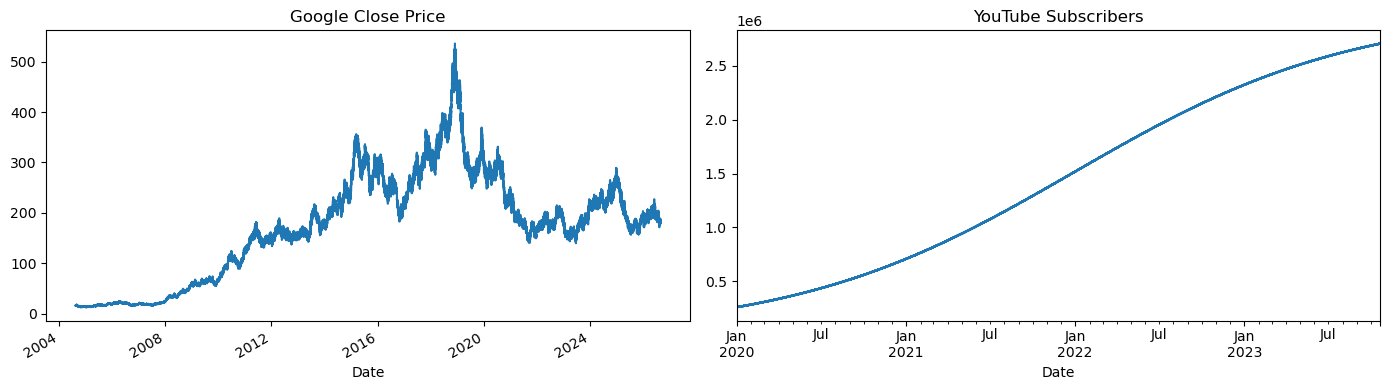

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
google['Close'].plot(ax=axes[0], title='Google Close Price')
yt['Subscribers'].plot(ax=axes[1], title='YouTube Subscribers')
plt.tight_layout()
plt.show()

### All Columns Together (Subplots)

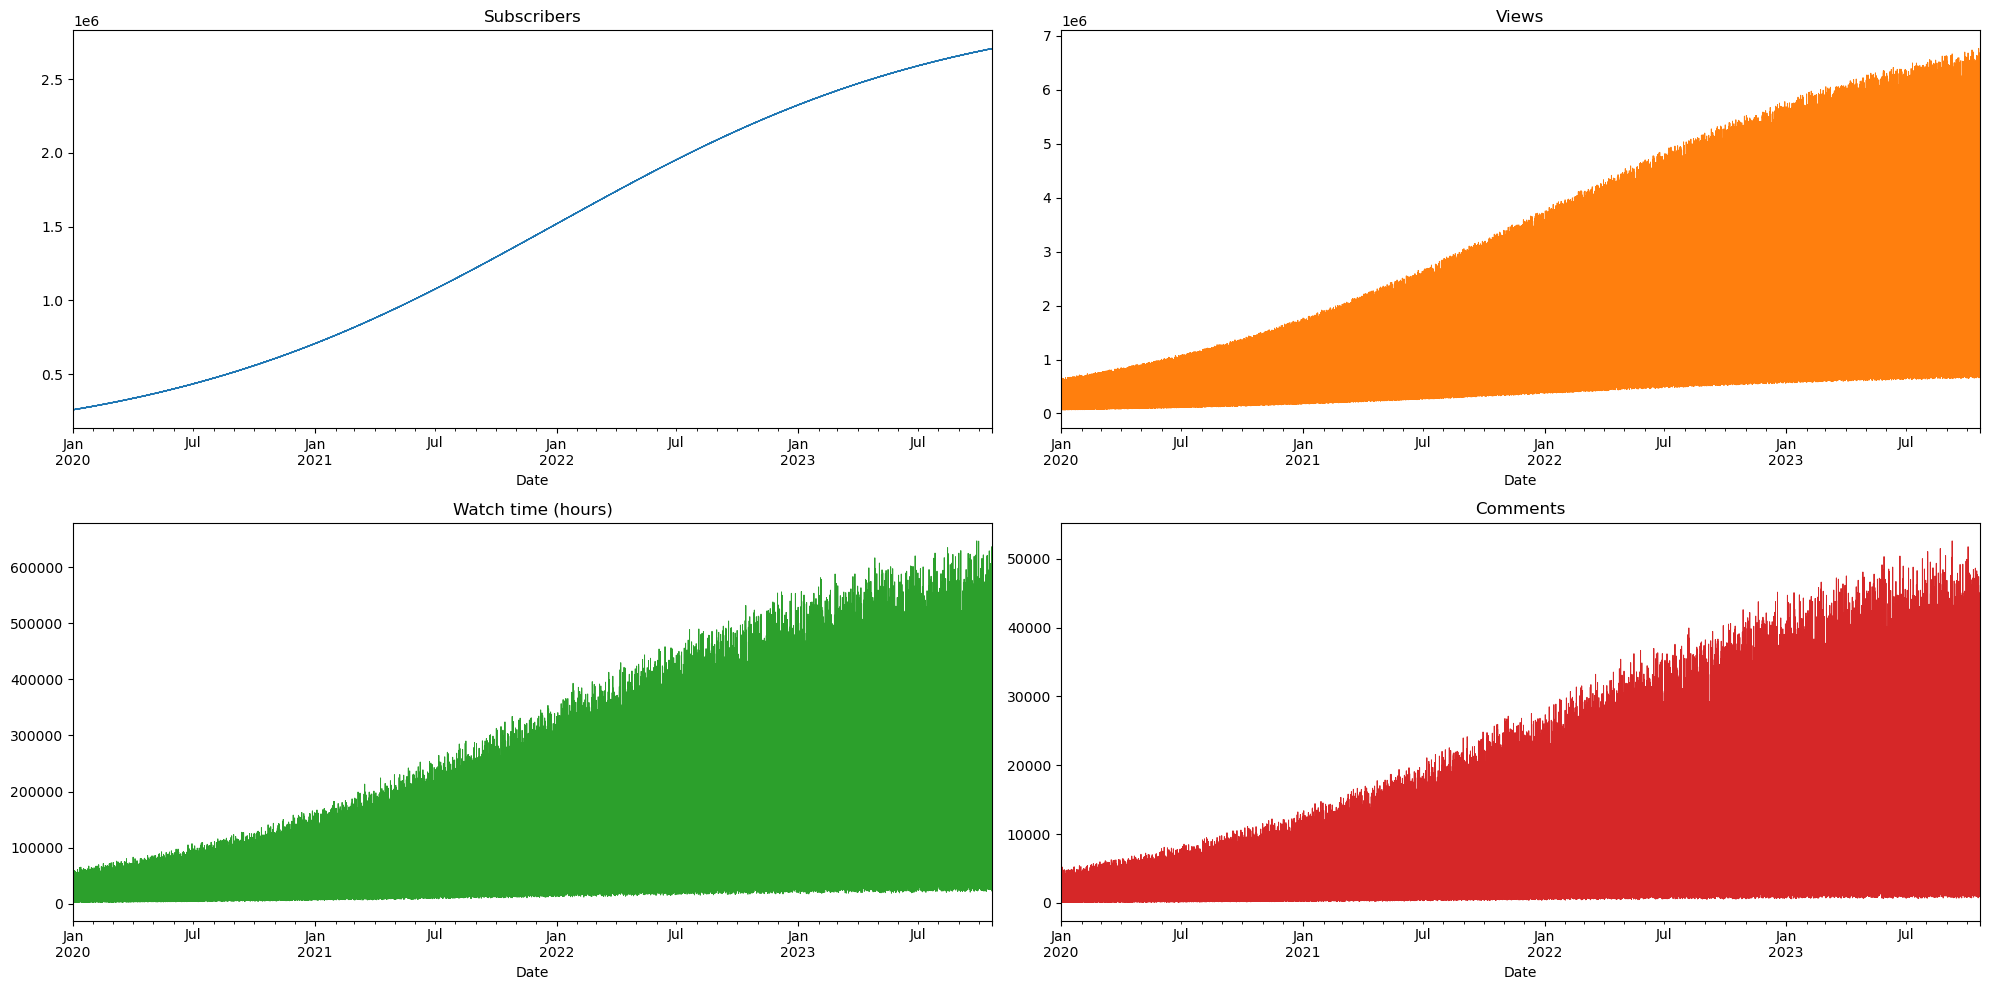

In [36]:
subset_yt = yt[['Subscribers', 'Views', 'Watch time (hours)', 'Comments added']]

ax = subset_yt.plot(
    subplots=True,
    layout=(2, 2),
    sharex=False,
    sharey=False,
    linewidth=0.7,
    fontsize=10,
    legend=False,
    figsize=(20, 10),
    title=['Subscribers', 'Views', 'Watch time (hours)', 'Comments']
)
plt.tight_layout()
plt.show()

### Plot for Particular Year/Month

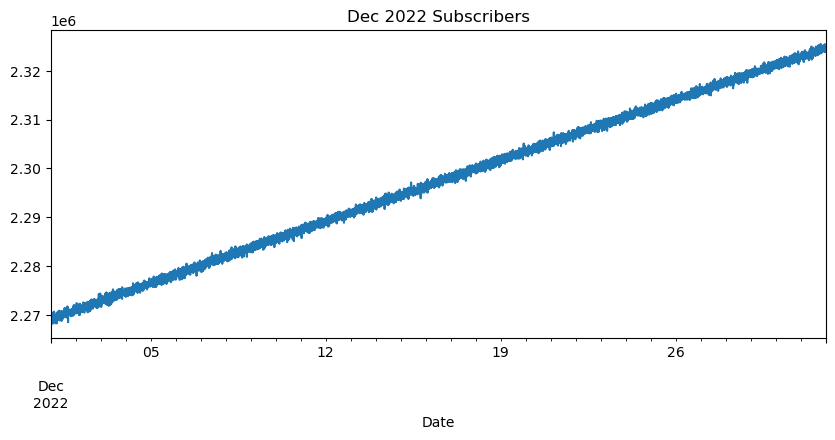

In [37]:
# December 2022 subscribers
yt.loc['2022-12']['Subscribers'].plot(figsize=(10, 4), title='Dec 2022 Subscribers')
plt.show()

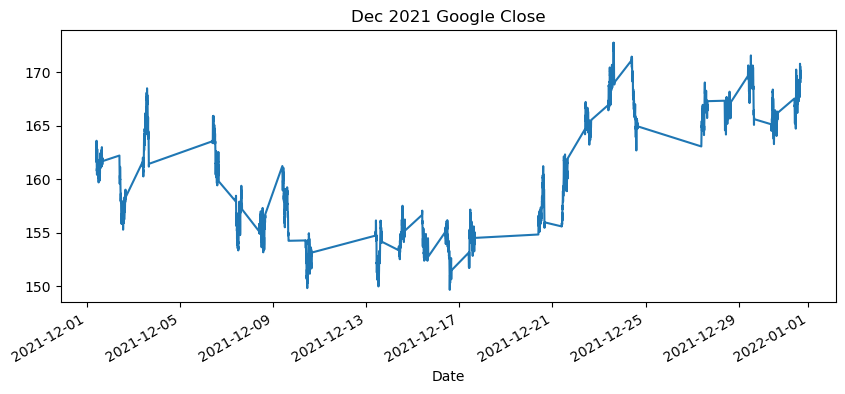

In [38]:
# December 2021 Google close
google.loc['2021-12']['Close'].plot(figsize=(10, 4), title='Dec 2021 Google Close')
plt.show()

### Monthly Trend

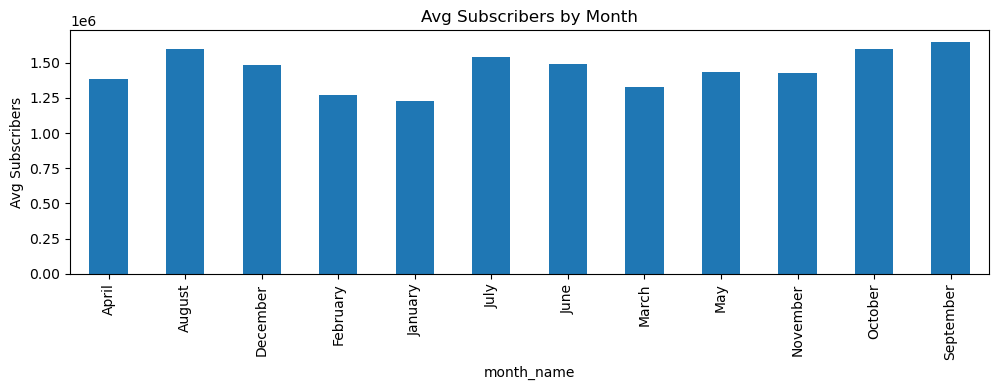

In [39]:
yt.groupby('month_name')['Subscribers'].mean().plot(kind='bar', figsize=(10, 4), title='Avg Subscribers by Month')
plt.ylabel('Avg Subscribers')
plt.tight_layout()
plt.show()

### Weekday Trend

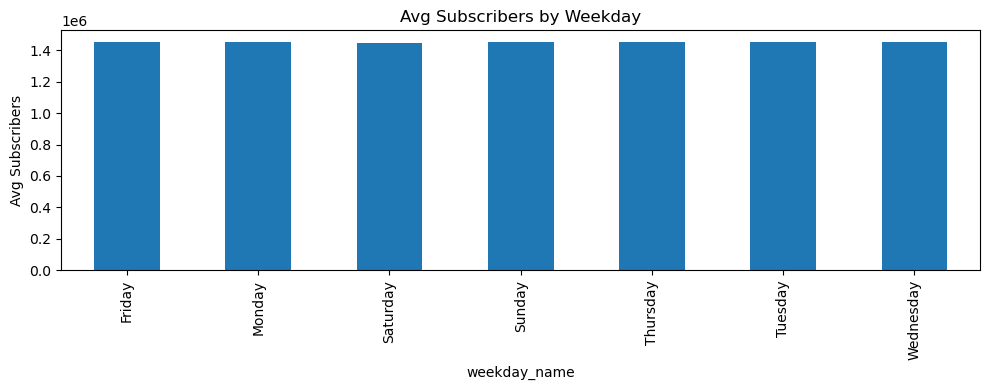

In [40]:
yt.groupby('weekday_name')['Subscribers'].mean().plot(kind='bar', figsize=(10, 4), title='Avg Subscribers by Weekday')
plt.ylabel('Avg Subscribers')
plt.tight_layout()
plt.show()


## Frequency

In [41]:
# Check current frequency
print('Google index frequency:', google.index)

Google index frequency: DatetimeIndex(['2004-08-19 09:30:00', '2004-08-19 09:33:00',
               '2004-08-19 09:36:00', '2004-08-19 09:39:00',
               '2004-08-19 09:42:00', '2004-08-19 09:45:00',
               '2004-08-19 09:48:00', '2004-08-19 09:51:00',
               '2004-08-19 09:54:00', '2004-08-19 09:57:00',
               ...
               '2026-08-20 15:30:00', '2026-08-20 15:33:00',
               '2026-08-20 15:36:00', '2026-08-20 15:39:00',
               '2026-08-20 15:42:00', '2026-08-20 15:45:00',
               '2026-08-20 15:48:00', '2026-08-20 15:51:00',
               '2026-08-20 15:54:00', '2026-08-20 15:57:00'],
              dtype='datetime64[ns]', name='Date', length=746330, freq=None)


In [42]:
# Change frequency using asfreq
google.asfreq('6H', method='bfill').head(20)

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_25204\3312768573.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  google.asfreq('6H', method='bfill').head(20)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-08-19 09:30:00,16.647109,16.652925,16.604722,16.604722,16.604722,145090
2004-08-19 15:30:00,16.186462,16.247726,16.180190,16.247726,16.247726,316172
2004-08-19 21:30:00,16.337710,16.377651,16.332936,16.377651,16.377651,73985
2004-08-20 03:30:00,16.337710,16.377651,16.332936,16.377651,16.377651,73985
2004-08-20 09:30:00,16.337710,16.377651,16.332936,16.377651,16.377651,73985
2004-08-20 15:30:00,15.966988,15.974675,15.958130,15.958130,15.958130,96462
2004-08-20 21:30:00,16.000781,16.009137,15.983729,15.983729,15.983729,46147
2004-08-21 03:30:00,16.000781,16.009137,15.983729,15.983729,15.983729,46147
2004-08-21 09:30:00,16.000781,16.009137,15.983729,15.983729,15.983729,46147



## Resampling

Resampling involves changing the frequency of your time series observations.

| Type | Description | Example |
|------|-------------|---------|
| **Downsampling** | Decrease frequency | Days → Months |
| **Upsampling** | Increase frequency | Minutes → Seconds |

### Downsampling: Daily → Yearly

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_25204\2371397882.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yt['Subscribers'].resample('Y').mean().plot(ax=axes[1], title='Resampled Yearly (Mean)')


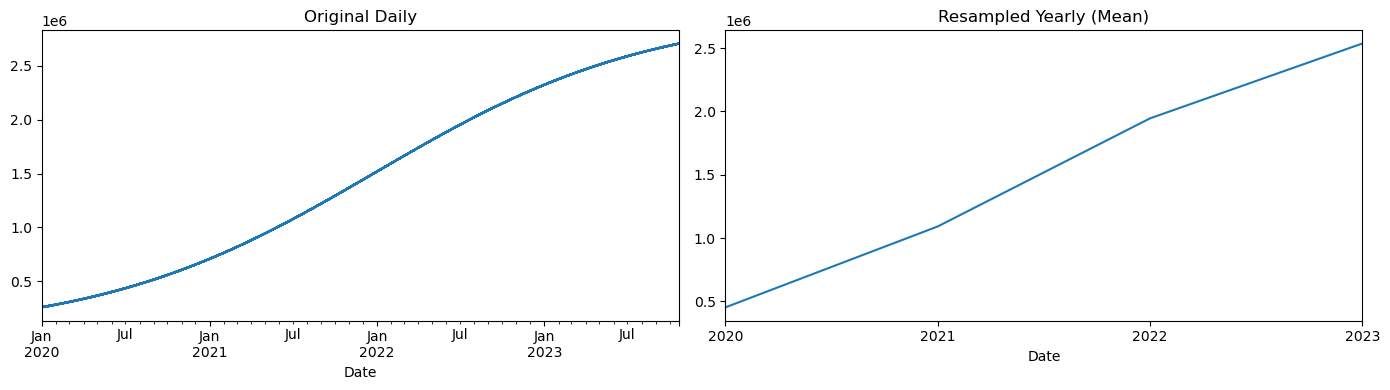

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

yt['Subscribers'].plot(ax=axes[0], title='Original Daily')
yt['Subscribers'].resample('Y').mean().plot(ax=axes[1], title='Resampled Yearly (Mean)')
plt.tight_layout()
plt.show()

### Upsampling: Interpolation

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_25204\3803544336.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  google['Close'].resample('12H').interpolate(method='spline', order=2).plot(


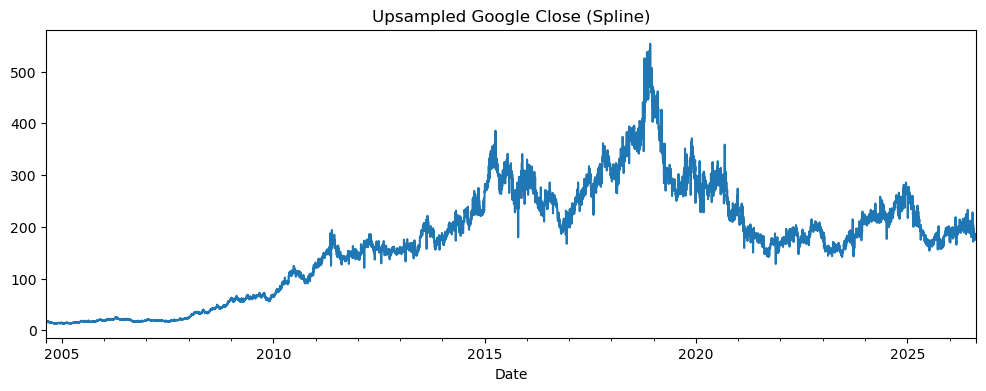

In [44]:
google['Close'].resample('12H').interpolate(method='spline', order=2).plot(
    figsize=(12, 4), title='Upsampled Google Close (Spline)'
)
plt.show()


## Rolling Window (Smoothing)

Time series data can be volatile. **Rolling (moving) averages** help smooth the data.

- **Rolling:** Simple moving average
- **EWM:** Exponentially Weighted Moving (gives more weight to recent data)

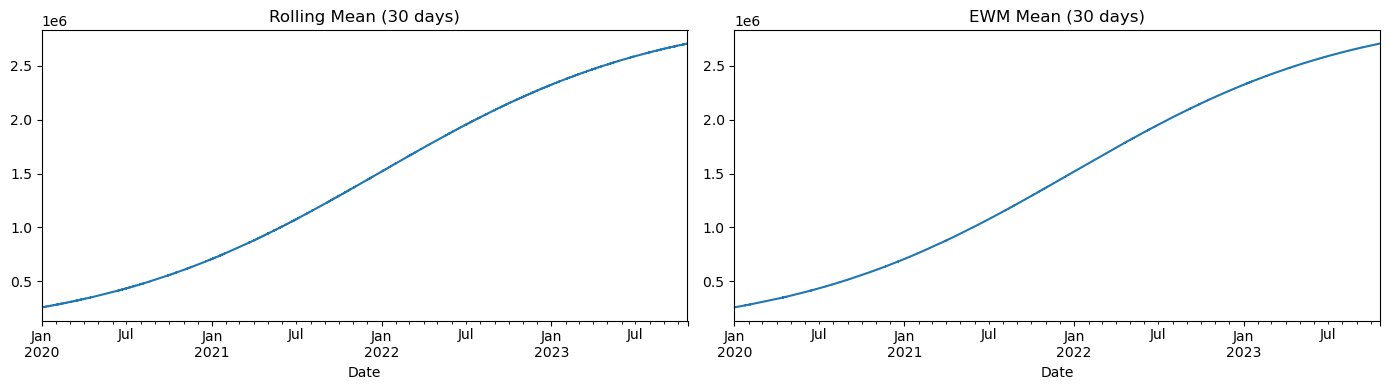

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

yt['Subscribers'].rolling(30).mean().plot(ax=axes[0], title='Rolling Mean (30 days)')
yt['Subscribers'].ewm(30).mean().plot(ax=axes[1], title='EWM Mean (30 days)')
plt.tight_layout()
plt.show()


## Shifting

The **`shift()`** function shifts the entire series up or down by a specified number of periods.

Use cases:
- Comparing current vs previous period
- Calculating time differences
- Lag features for forecasting

In [46]:
# Original vs Shifted
yt['Subscribers'].head(10)

Date
2020-01-01 00:00:00    259766
2020-01-01 00:05:00    259451
2020-01-01 00:10:00    259847
2020-01-01 00:15:00    260287
2020-01-01 00:20:00    259411
2020-01-01 00:25:00    259414
2020-01-01 00:30:00    260323
2020-01-01 00:35:00    259920
2020-01-01 00:40:00    259304
2020-01-01 00:45:00    259812
Name: Subscribers, dtype: int64

In [47]:
# Shifted by 1 period
yt['Subscribers'].shift(1).head(10)

Date
2020-01-01 00:00:00         NaN
2020-01-01 00:05:00    259766.0
2020-01-01 00:10:00    259451.0
2020-01-01 00:15:00    259847.0
2020-01-01 00:20:00    260287.0
2020-01-01 00:25:00    259411.0
2020-01-01 00:30:00    259414.0
2020-01-01 00:35:00    260323.0
2020-01-01 00:40:00    259920.0
2020-01-01 00:45:00    259304.0
Name: Subscribers, dtype: float64

In [48]:
# Shifted by -1 (forward shift)
yt['Subscribers'].shift(-1).head(10)

Date
2020-01-01 00:00:00    259451.0
2020-01-01 00:05:00    259847.0
2020-01-01 00:10:00    260287.0
2020-01-01 00:15:00    259411.0
2020-01-01 00:20:00    259414.0
2020-01-01 00:25:00    260323.0
2020-01-01 00:30:00    259920.0
2020-01-01 00:35:00    259304.0
2020-01-01 00:40:00    259812.0
2020-01-01 00:45:00    259312.0
Name: Subscribers, dtype: float64

### Real Example: Login Time Analysis

In [49]:
# shift example
df = pd.read_csv('Datasets/login.csv',header=None)
df = df[[1,2]]

In [50]:
df.head()

,1,2
0,1,2
1,860,2026-05-13 01:11:38
2,978,2022-06-23 20:36:06
3,371,2025-07-25 04:21:47
4,618,2022-09-01 11:20:10


In [51]:
df.rename(columns={1:'user_id',2:'login_time'},inplace=True)
df.head()

,user_id,login_time
0,1,2
1,860,2026-05-13 01:11:38
2,978,2022-06-23 20:36:06
3,371,2025-07-25 04:21:47
4,618,2022-09-01 11:20:10


In [52]:
# Filter for user 458
user_df = df[df['user_id'] == 458]
user_df.head()

,user_id,login_time
668,458,2021-04-29 00:29:40
3271,458,2023-05-27 14:24:46
3475,458,2023-03-22 14:33:51
3548,458,2022-02-26 05:57:25
3704,458,2025-05-24 06:11:06


In [55]:
# Calculate time between logins
user_df['login_time'] = pd.to_datetime(user_df['login_time'])
user_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 668 to 9471
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     25 non-null     int64         
 1   login_time  25 non-null     datetime64[ns]
 2   shifted     24 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 800.0+ bytes


C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_25204\2307922849.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['login_time'] = pd.to_datetime(user_df['login_time'])


In [56]:
user_df['shifted'] = user_df['login_time'].shift(1)
(user_df['login_time'] - user_df['shifted']).mean()

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_25204\4028882259.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['shifted'] = user_df['login_time'].shift(1)


Timedelta('-9 days +00:00:26.583333334')

ValueError: The length of `title` must equal the number of columns if using `title` of type `list` and `subplots=True`.
length of title = 6
number of columns = 1

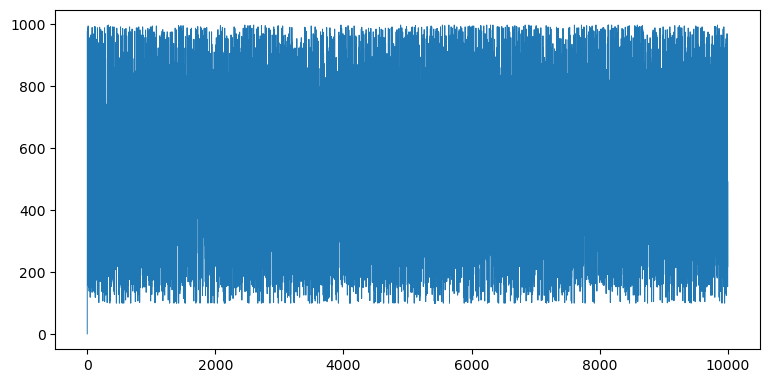

In [57]:
ax = df.plot(subplots=True,
                    layout=(3, 2),
                     sharex=False,
                     sharey=False,
                     linewidth=0.7,
                     fontsize=10,
                     legend=False,
                      figsize=(20,15),
                      title=['Open', 'High', 'Low', 'Close','Adjusted Close', 'Volume'])